In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator, interp1d
import pickle
import corner

In [2]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/'

In [3]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [4]:
t_Myr_sec = 3.1689E-14 # Conversion from seconds to Myr

# Functions for PIE temperature, cooling/recombination time

Load cooling times and temperatures saved for PIE (main grid run)

In [5]:
# Unique grids in density/metallicity
log_hdens_arr = np.arange(-5, 1.25, 0.25)
log_metals_arr = np.arange(-3, 1.25, 0.25)
N_pts = len(log_hdens_arr)*len(log_metals_arr)

log_hdens_sub_arr = np.arange(-4.25, 1.25, 0.25)
log_metals_sub_arr = np.arange(-0.25, 1.25, 0.25)

In [6]:
# Grid of cooling times, in seconds, need to convert to Myr
# Index only accesses for unique density/metallicities
t_cool_grid = np.loadtxt(rootdir+'cloudy_grids/t_cool.txt', delimiter=',')[2::3]*t_Myr_sec
t_cool_grid = t_cool_grid.reshape(len(log_hdens_arr),len(log_metals_arr))

# Store these into a dictionary
logt_cool_dict = {}

# Measurements after adding blackbody heating

for i in range(len(log_hdens_arr)):
    for j in range(len(log_metals_arr)):
        log_hdens = log_hdens_arr[i]
        log_metals = log_metals_arr[j]
        logt_cool_dict[(log_hdens,log_metals)] = np.log10(t_cool_grid[i,j])

t_cool_sub_grid = np.loadtxt(rootdir+'cloudy_grids/t_cool_sub.txt', delimiter=',')[2::3]*t_Myr_sec
t_cool_sub_grid = t_cool_sub_grid.reshape(len(log_hdens_sub_arr),len(log_metals_sub_arr))

logt_cool_sub_dict = {}

for i in range(len(log_hdens_sub_arr)):
    for j in range(len(log_metals_sub_arr)):
        log_hdens = log_hdens_sub_arr[i]
        log_metals = log_metals_sub_arr[j]
        logt_cool_sub_dict[(log_hdens,log_metals)] = np.log10(t_cool_sub_grid[i,j])

In [7]:
# Load in final temperatures and reshape
logT_grid = np.loadtxt(rootdir+'cloudy_grids/final_flat_logT.dat')[:N_pts]
logT_grid = logT_grid.reshape(len(log_hdens_arr),len(log_metals_arr))

In [8]:
logt_cool_grid = np.zeros(t_cool_grid.shape)

for i in range(len(log_hdens_arr)):
    for j in range(len(log_metals_arr)):
        log_hdens = log_hdens_arr[i]
        log_metals = log_metals_arr[j]
        if logT_grid[i,j] == 4.: # Needed to add blackbody heating
            logt_cool_grid[i,j] = logt_cool_sub_dict[(log_hdens,log_metals)]
        else:
            logt_cool_grid[i,j] = logt_cool_dict[(log_hdens,log_metals)]

Interpolate temperatures and cooling times

In [9]:
logT_interp = RegularGridInterpolator((log_hdens_arr, log_metals_arr), logT_grid)
logt_cool_interp = RegularGridInterpolator((log_hdens_arr, log_metals_arr), logt_cool_grid)

Interpolate recombination times

In [10]:
# From CLOUDY calculations
logT_rec_grid = np.array([4. , 4.2, 4.4, 4.6, 4.8, 5. , 5.2, 5.4, 5.6, 5.8, 6. , 6.2, 6.4,
        6.6, 6.8, 7. , 7.2, 7.4, 7.6, 7.8, 8. ])

logq_rec_CV_grid = np.log10(np.array([8.67e-12, 6.24e-12, 4.46e-12, 3.17e-12, 2.23e-12, 1.56e-12,
                                    1.09e-12, 7.49e-13, 5.12e-13, 3.46e-13, 2.31e-13, 1.53e-13,
                                    9.92e-14, 6.35e-14, 3.99e-14, 2.47e-14, 1.49e-14, 8.86e-15,
                                    5.15e-15, 2.94e-15, 2.94e-15]))


logq_rec_OVI_grid = np.log10(np.array([1.58e-11, 1.16e-11, 8.45e-12, 6.13e-12, 4.41e-12, 3.15e-12,
        2.24e-12, 1.57e-12, 1.09e-12, 7.49e-13, 5.07e-13, 3.37e-13,
        2.20e-13, 1.41e-13, 8.87e-14, 5.45e-14, 3.28e-14, 1.93e-14,
        1.11e-14, 6.26e-15, 6.26e-15]))

logq_rec_OVII_grid = np.log10(np.array([2.27e-11, 1.66e-11, 1.20e-11, 8.62e-12, 6.16e-12, 4.37e-12,
        3.07e-12, 2.15e-12, 1.48e-12, 1.02e-12, 6.90e-13, 4.62e-13,
        3.05e-13, 1.98e-13, 1.27e-13, 7.96e-14, 4.90e-14, 2.95e-14,
        1.75e-14, 1.01e-14, 1.01e-14]))

In [11]:
logq_rec_interp = interp1d(logT_rec_grid, logq_rec_CV_grid, fill_value='extrapolate')

In [12]:
# OVI
logq_OVI_rec_interp = interp1d(logT_rec_grid, logq_rec_OVI_grid, fill_value='extrapolate')
# OVII
logq_OVII_rec_interp = interp1d(logT_rec_grid, logq_rec_OVII_grid, fill_value='extrapolate')

In [15]:
def logt_rec(log_hdens, logT, logq_rec_interp):
    
    logq = logq_rec_interp(logT)
    logt_rec = np.log10(((7/6)*10**log_hdens*10**logq)**-1*t_Myr_sec)
    
    return logt_rec

In [16]:
def logt_OVI_rec(log_hdens, logT, logq_OVI_rec_interp):
    
    logq = logq_OVI_rec_interp(logT)
    logt_rec = np.log10(((7/6)*10**log_hdens*10**logq)**-1*t_Myr_sec)
    
    return logt_rec

In [17]:
def logt_OVI_rec(log_hdens, logT, logq_OVII_rec_interp):
    
    logq = logq_OVII_rec_interp(logT)
    logt_rec = np.log10(((7/6)*10**log_hdens*10**logq)**-1*t_Myr_sec)
    
    return logt_rec

Functions to get distributions of $T$, $t_\mathrm{rec}$ and $t_\mathrm{cool}/t_\mathrm{rec}$

In [18]:
def get_cooling_dist(log_hdens_samples, log_metals_samples, logq_rec_interp, logt_cool_interp):
    
    # Distribution of PIE temperatures
    logT_samples = logT_interp((log_hdens_samples, log_metals_samples))
    
    # Distribution of recombination times
    logt_rec_samples = logt_rec(log_hdens_samples, logT_samples, logq_rec_interp)
    
    # Distribution of cooling times
    logt_cool_samples = logt_cool_interp((log_hdens_samples, log_metals_samples))
    
    return np.array(logT_samples), np.array(logt_rec_samples), np.array(logt_cool_samples)

In [19]:
def get_cooling_dist_hi(log_hdens_samples, log_metals_samples, logq_OVI_rec_interp, logq_OVII_rec_interp, logt_cool_interp):
    
    # Distribution of PIE temperatures
    logT_samples = logT_interp((log_hdens_samples, log_metals_samples))
    
    # Distribution of recombination times
    logt_rec_OVI_samples = logt_rec(log_hdens_samples, logT_samples, logq_OVI_rec_interp)
    logt_rec_OVII_samples = logt_rec(log_hdens_samples, logT_samples, logq_OVII_rec_interp)
    
    # Distribution of cooling times
    logt_cool_samples = logt_cool_interp((log_hdens_samples, log_metals_samples))
    
    return np.array(logT_samples), np.array(logt_rec_OVI_samples), np.array(logt_rec_OVII_samples), np.array(logt_cool_samples)

In [20]:
loaddir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/'

Diagnostic plots

In [21]:
log_hdens_test_arr = np.arange(-4.6, -2.3, 0.05)

Text(0, 0.5, '$\\log(T_\\mathrm{PIE}/\\mathrm{K})$')

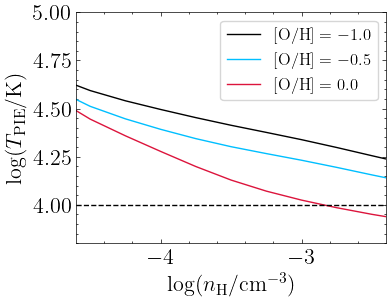

In [22]:
fig, ax = plt.subplots(1,figsize=(4,3))
ax.plot(log_hdens_test_arr, logT_interp((log_hdens_test_arr,-1.0)), label=r'$[\mathrm{O/H}]=-1.0$')
ax.plot(log_hdens_test_arr, logT_interp((log_hdens_test_arr,-0.5)), label=r'$[\mathrm{O/H}]=-0.5$')
ax.plot(log_hdens_test_arr, logT_interp((log_hdens_test_arr,0.0)), label=r'$[\mathrm{O/H}]=0.0$')

ax.axhline(4.0,linestyle='--')
ax.set_xlim(-4.6,-2.4)
ax.set_ylim(3.8,5.0)

ax.legend()

ax.set_xlabel(r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})$')
ax.set_ylabel(r'$\log(T_\mathrm{PIE}/\mathrm{K})$')

Text(0, 0.5, '$\\log(t_\\mathrm{cool}/t_\\mathrm{rec})$')

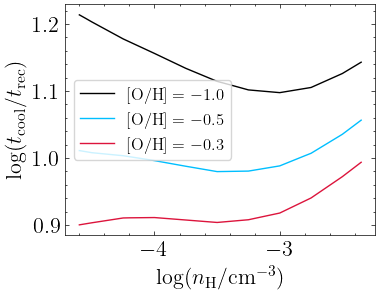

In [23]:
fig, ax = plt.subplots(1,figsize=(4,3))

ax.plot(log_hdens_test_arr,
        logt_cool_interp((log_hdens_test_arr,-1.0))-logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,-1.0)),logq_rec_interp), 
        label=r'$[\mathrm{O/H}]=-1.0$')

ax.plot(log_hdens_test_arr,
        logt_cool_interp((log_hdens_test_arr,-0.5))-logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,-0.5)),logq_rec_interp), 
        label=r'$[\mathrm{O/H}]=-0.5$')

ax.plot(log_hdens_test_arr,
        logt_cool_interp((log_hdens_test_arr,-0.3))-logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,-0.3)),logq_rec_interp), 
        label=r'$[\mathrm{O/H}]=-0.3$')

ax.legend()
ax.set_xlabel(r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})$')
ax.set_ylabel(r'$\log(t_\mathrm{cool}/t_\mathrm{rec})$')

In [24]:
log_metals_test_arr = np.arange(-3.0, 1., 0.25)

Text(0, 0.5, '$\\log(T/\\mathrm{K})$')

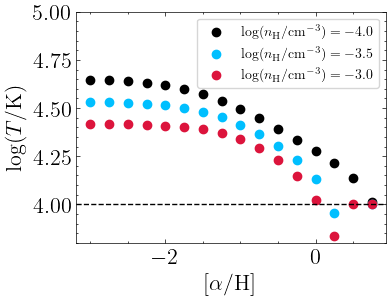

In [25]:
fig, ax = plt.subplots(1,figsize=(4,3))
ax.scatter(log_metals_test_arr, logT_interp((-4.,log_metals_test_arr)), label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-4.0$')
ax.scatter(log_metals_test_arr, logT_interp((-3.5,log_metals_test_arr)), label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.5$')
ax.scatter(log_metals_test_arr, logT_interp((-3.,log_metals_test_arr)), label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.0$')

ax.axhline(4.0,linestyle='--')
#ax.set_xlim(-4.6,-2.4)
ax.set_ylim(3.8,5.0)

ax.legend(fontsize=10)

ax.set_xlabel(r'$\mathrm{[\alpha/H]}$')
ax.set_ylabel(r'$\log(T/\mathrm{K})$')

Text(0, 0.5, '$\\log(t_\\mathrm{cool}/\\mathrm{Myr})$')

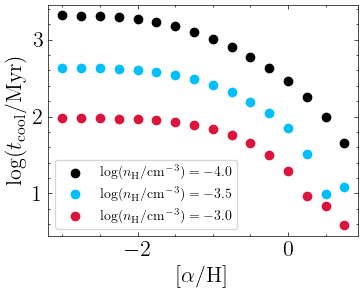

In [26]:
fig, ax = plt.subplots(1,figsize=(4,3))
ax.scatter(log_metals_test_arr, logt_cool_interp((-4.,log_metals_test_arr)), label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-4.0$')
ax.scatter(log_metals_test_arr, logt_cool_interp((-3.5,log_metals_test_arr)), label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.5$')
ax.scatter(log_metals_test_arr, logt_cool_interp((-3.,log_metals_test_arr)), label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.0$')

#ax.set_xlim(-4.6,-2.4)
#ax.set_ylim(3.8,5.0)

ax.legend(fontsize=10)

ax.set_xlabel(r'$\mathrm{[\alpha/H]}$')
ax.set_ylabel(r'$\log(t_\mathrm{cool}/\mathrm{Myr})$')

Text(0, 0.5, '$\\log (n_\\mathrm{H} \\Lambda / k_B)$')

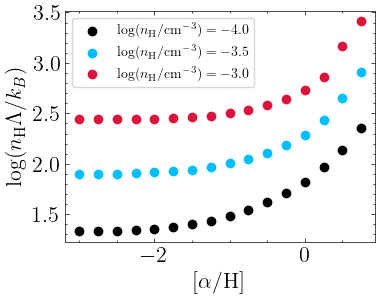

In [27]:
fig, ax = plt.subplots(1,figsize=(4,3))
ax.scatter(log_metals_test_arr, logT_interp((-4.,log_metals_test_arr))-logt_cool_interp((-4.,log_metals_test_arr)), 
           label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-4.0$')
ax.scatter(log_metals_test_arr, logT_interp((-3.5,log_metals_test_arr))-logt_cool_interp((-3.5,log_metals_test_arr)), 
           label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.5$')
ax.scatter(log_metals_test_arr, logT_interp((-3.,log_metals_test_arr))-logt_cool_interp((-3.,log_metals_test_arr)), 
           label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.0$')

#ax.set_xlim(-4.6,-2.4)
#ax.set_ylim(3.8,5.0)

ax.legend(fontsize=10)

ax.set_xlabel(r'$\mathrm{[\alpha/H]}$')
ax.set_ylabel(r'$\log (n_\mathrm{H} \Lambda / k_B)$')

Text(0, 0.5, '$\\log(t_\\mathrm{rec}/\\mathrm{Myr})$')

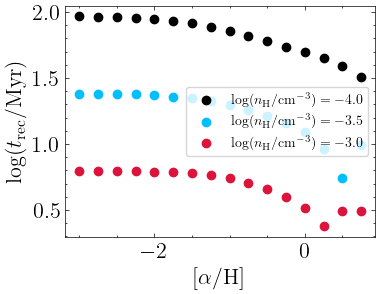

In [28]:
fig, ax = plt.subplots(1,figsize=(4,3))
ax.scatter(log_metals_test_arr, logt_rec(-4.,logT_interp((-4.,log_metals_test_arr)),logq_rec_interp), 
           label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-4.0$')
ax.scatter(log_metals_test_arr, logt_rec(-3.5,logT_interp((-3.5,log_metals_test_arr)),logq_rec_interp), 
           label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.5$')
ax.scatter(log_metals_test_arr, logt_rec(-3.,logT_interp((-3.,log_metals_test_arr)),logq_rec_interp), 
           label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.0$')

#ax.set_xlim(-4.6,-2.4)
#ax.set_ylim(3.8,5.0)

ax.legend(fontsize=10)

ax.set_xlabel(r'$\mathrm{[\alpha/H]}$')
ax.set_ylabel(r'$\log(t_\mathrm{rec}/\mathrm{Myr})$')

Text(0, 0.5, '$\\log(t_\\mathrm{cool}/\\mathrm{Myr})$')

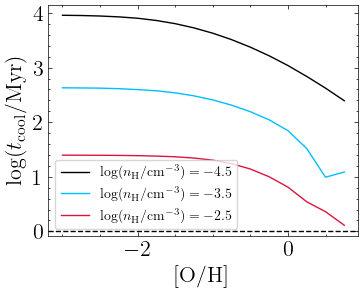

In [29]:
fig, ax = plt.subplots(1,figsize=(4,3))

ax.plot(log_metals_test_arr,
        logt_cool_interp((-4.5,log_metals_test_arr)), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-4.5$')

ax.plot(log_metals_test_arr,
        logt_cool_interp((-3.5,log_metals_test_arr)), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.5$')

ax.plot(log_metals_test_arr,
        logt_cool_interp((-2.5,log_metals_test_arr)), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-2.5$')

ax.axhline(0, linestyle='--')

ax.legend(fontsize=10)
ax.set_xlabel(r'$\mathrm{[O/H]}$')
ax.set_ylabel(r'$\log(t_\mathrm{cool}/\mathrm{Myr})$')

Text(0, 0.5, '$\\log(t_\\mathrm{cool}/t_\\mathrm{rec})$')

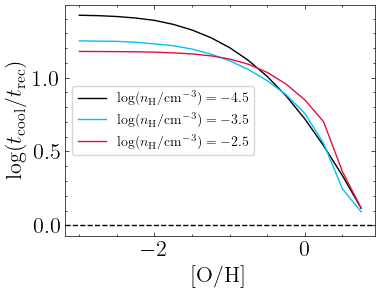

In [30]:
fig, ax = plt.subplots(1,figsize=(4,3))

ax.plot(log_metals_test_arr,
        logt_cool_interp((-4.5,log_metals_test_arr))-logt_rec(-4.5,logT_interp((-4.5,log_metals_test_arr)),logq_rec_interp), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-4.5$')

ax.plot(log_metals_test_arr,
        logt_cool_interp((-3.5,log_metals_test_arr))-logt_rec(-3.5,logT_interp((-3.5,log_metals_test_arr)),logq_rec_interp), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.5$')

ax.plot(log_metals_test_arr,
        logt_cool_interp((-2.5,log_metals_test_arr))-logt_rec(-2.5,logT_interp((-2.5,log_metals_test_arr)),logq_rec_interp), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-2.5$')

ax.axhline(0, linestyle='--')

ax.legend(fontsize=10)
ax.set_xlabel(r'$\mathrm{[O/H]}$')
ax.set_ylabel(r'$\log(t_\mathrm{cool}/t_\mathrm{rec})$')

Text(0, 0.5, '$\\log(t_\\mathrm{cool}/t_\\mathrm{rec})$')

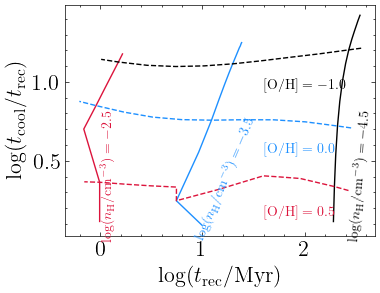

In [31]:
fig, ax = plt.subplots(1,figsize=(4,3))

ax.plot(logt_rec(-4.5,logT_interp((-4.5,log_metals_test_arr)),logq_rec_interp),
        logt_cool_interp((-4.5,log_metals_test_arr))-logt_rec(-4.5,logT_interp((-4.5,log_metals_test_arr)),logq_rec_interp), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-4.5$',color='black')

ax.text(2.4,0.0,r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-4.5$',fontsize=10, rotation=85, color='black')

ax.plot(logt_rec(-3.5,logT_interp((-3.5,log_metals_test_arr)),logq_rec_interp),
        logt_cool_interp((-3.5,log_metals_test_arr))-logt_rec(-3.5,logT_interp((-3.5,log_metals_test_arr)),logq_rec_interp), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.5$',color='dodgerblue')

ax.text(0.9,0.0,r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.5$',fontsize=10, rotation=67, color='dodgerblue')

ax.plot(logt_rec(-2.5,logT_interp((-2.5,log_metals_test_arr)),logq_rec_interp),
        logt_cool_interp((-2.5,log_metals_test_arr))-logt_rec(-2.5,logT_interp((-2.5,log_metals_test_arr)),logq_rec_interp), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-2.5$',color='crimson')

ax.text(0.0,0.0,r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-2.5$',fontsize=10, rotation=90, color='crimson')

ax.plot(logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,-1.0)),logq_rec_interp),
        logt_cool_interp((log_hdens_test_arr,-1.0))-logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,-1.0)),logq_rec_interp), 
        label=r'$[\mathrm{O/H}]=-1.0$',color='black', linestyle='--')

ax.text(1.6,0.95,r'$\mathrm{[O/H]}=-1.0$',fontsize=10)

ax.plot(logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,0.0)),logq_rec_interp),
        logt_cool_interp((log_hdens_test_arr,0.0))-logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,0.0)),logq_rec_interp), 
        label=r'$[\mathrm{O/H}]=0.0$',color='dodgerblue', linestyle='--')

ax.text(1.6,0.55,r'$\mathrm{[O/H]}=0.0$',fontsize=10,color='dodgerblue')

ax.plot(logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,0.5)),logq_rec_interp),
        logt_cool_interp((log_hdens_test_arr,0.5))-logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,0.5)),logq_rec_interp), 
        label=r'$[\mathrm{O/H}]=0.5$',color='crimson', linestyle='--')

ax.text(1.6,0.15,r'$\mathrm{[O/H]}=0.5$',fontsize=10,color='crimson')

ax.set_xlabel(r'$\log(t_\mathrm{rec}/\mathrm{Myr})$')
ax.set_ylabel(r'$\log(t_\mathrm{cool}/t_\mathrm{rec})$')

# z=0.67, PIE

## c1

In [30]:
z_067_c1_PIE_samples = pd.read_csv(loaddir+'z=0.67545705/cloudy_fits/two_phase.csv')

### c1H

In [31]:
z_067_c1H_PIE_logT, z_067_c1H_PIE_logt_rec, z_067_c1H_PIE_logt_cool = get_cooling_dist(z_067_c1_PIE_samples['log_hdens_p1'],
                                                                                             z_067_c1_PIE_samples['log_metals_p1'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([2.2000e+01, 2.7300e+02, 8.7500e+02, 2.4920e+03, 3.9230e+03,
        1.1178e+04, 7.4967e+04, 7.8607e+04, 7.5360e+03, 1.2700e+02]),
 array([4.11274497, 4.14311056, 4.17347615, 4.20384175, 4.23420734,
        4.26457293, 4.29493852, 4.32530412, 4.35566971, 4.3860353 ,
        4.41640089]),
 <BarContainer object of 10 artists>)

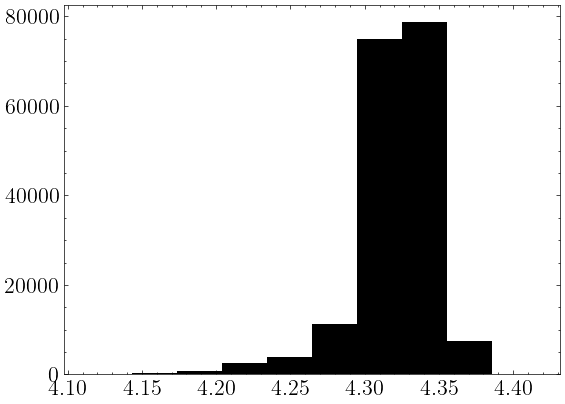

In [32]:
plt.hist(z_067_c1H_PIE_logT)

In [33]:
get_quantiles(z_067_c1H_PIE_logT)

4.32 -0.02 0.02


(array([2.0000e+00, 4.3000e+01, 6.2100e+02, 1.6050e+03, 3.4930e+03,
        5.6910e+03, 1.6369e+04, 7.7739e+04, 7.1282e+04, 3.1550e+03]),
 array([-0.28560096, -0.13696802,  0.01166492,  0.16029785,  0.30893079,
         0.45756373,  0.60619666,  0.7548296 ,  0.90346254,  1.05209547,
         1.20072841]),
 <BarContainer object of 10 artists>)

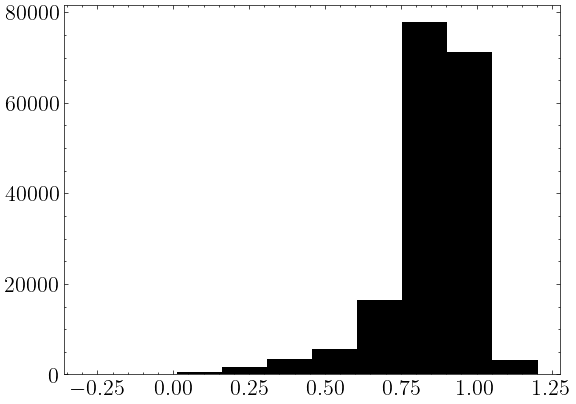

In [34]:
plt.hist(z_067_c1H_PIE_logt_rec)

In [35]:
get_quantiles(z_067_c1H_PIE_logt_rec)

0.88 -0.13 0.08


(array([2.6400e+02, 6.4420e+03, 6.7584e+04, 7.3194e+04, 2.4055e+04,
        6.8780e+03, 1.1680e+03, 1.9500e+02, 1.5800e+02, 6.2000e+01]),
 array([0.96563671, 0.97772815, 0.98981959, 1.00191103, 1.01400247,
        1.02609391, 1.03818535, 1.05027679, 1.06236823, 1.07445967,
        1.08655111]),
 <BarContainer object of 10 artists>)

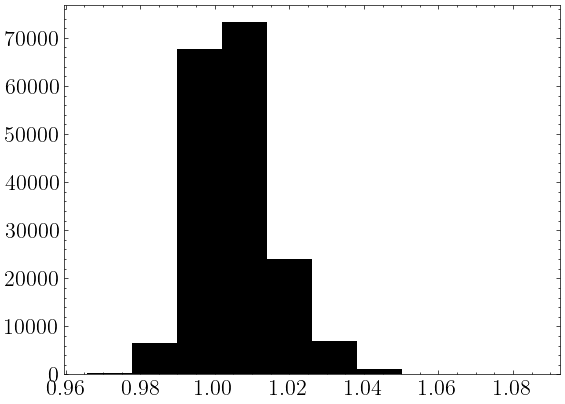

In [36]:
plt.hist(z_067_c1H_PIE_logt_cool-z_067_c1H_PIE_logt_rec)

In [37]:
get_quantiles(z_067_c1H_PIE_logt_cool-z_067_c1H_PIE_logt_rec)

1.0 -0.01 0.01


### c1L

In [38]:
z_067_c1L_PIE_logT, z_067_c1L_PIE_logt_OVI_rec, z_067_c1L_PIE_logt_OVII_rec, z_067_c1L_PIE_logt_cool = get_cooling_dist_hi(z_067_c1_PIE_samples['log_hdens_p2'],
                                                                                             z_067_c1_PIE_samples['log_metals_p2'],
                                                                                             logq_OVI_rec_interp, logq_OVII_rec_interp, logt_cool_interp)

(array([   95.,   239.,   978.,  2064.,  8038., 27195., 46903., 55895.,
        33100.,  5493.]),
 array([3.84797858, 3.91576198, 3.98354538, 4.05132879, 4.11911219,
        4.18689559, 4.254679  , 4.3224624 , 4.3902458 , 4.4580292 ,
        4.52581261]),
 <BarContainer object of 10 artists>)

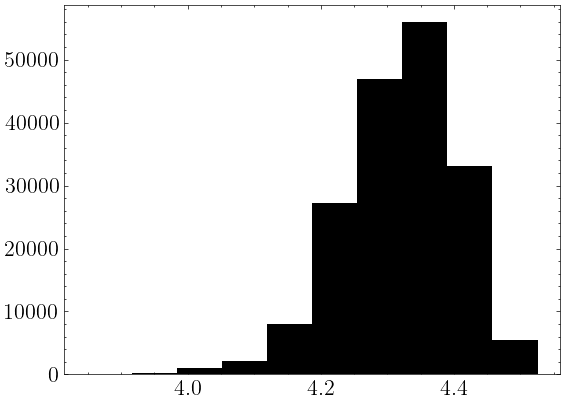

In [39]:
plt.hist(z_067_c1L_PIE_logT)

In [40]:
get_quantiles(z_067_c1L_PIE_logT)

4.33 -0.09 0.08


(array([2.4000e+01, 5.9900e+02, 4.0470e+03, 1.7383e+04, 4.1710e+04,
        5.7582e+04, 4.0733e+04, 1.5425e+04, 2.2650e+03, 2.3200e+02]),
 array([0.99718122, 1.07169818, 1.14621514, 1.2207321 , 1.29524906,
        1.36976602, 1.44428298, 1.51879995, 1.59331691, 1.66783387,
        1.74235083]),
 <BarContainer object of 10 artists>)

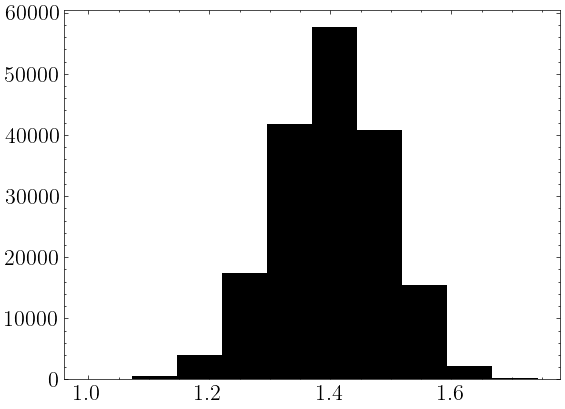

In [41]:
plt.hist(z_067_c1L_PIE_logt_OVI_rec)

In [42]:
get_quantiles(z_067_c1L_PIE_logt_OVI_rec)

1.4 -0.09 0.09


(array([2.4000e+01, 6.1200e+02, 4.0760e+03, 1.7401e+04, 4.1840e+04,
        5.7432e+04, 4.0601e+04, 1.5490e+04, 2.2870e+03, 2.3700e+02]),
 array([0.83933672, 0.91464838, 0.98996004, 1.0652717 , 1.14058336,
        1.21589502, 1.29120668, 1.36651834, 1.44183   , 1.51714166,
        1.59245332]),
 <BarContainer object of 10 artists>)

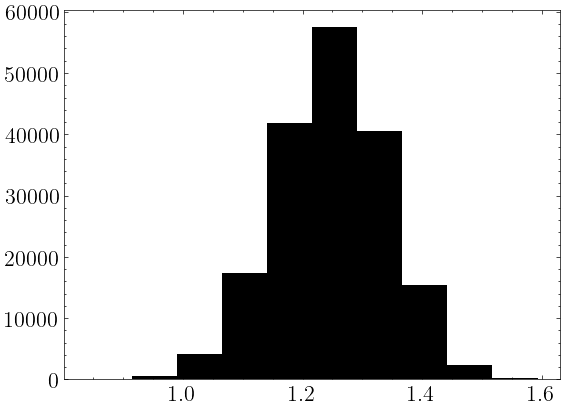

In [43]:
plt.hist(z_067_c1L_PIE_logt_OVII_rec)

In [44]:
get_quantiles(z_067_c1L_PIE_logt_OVII_rec)

1.25 -0.09 0.09


(array([  115.,   160.,   348.,   628.,  2130.,  9063., 26613., 53770.,
        66583., 20590.]),
 array([0.04214901, 0.17902584, 0.31590266, 0.45277948, 0.5896563 ,
        0.72653313, 0.86340995, 1.00028677, 1.13716359, 1.27404042,
        1.41091724]),
 <BarContainer object of 10 artists>)

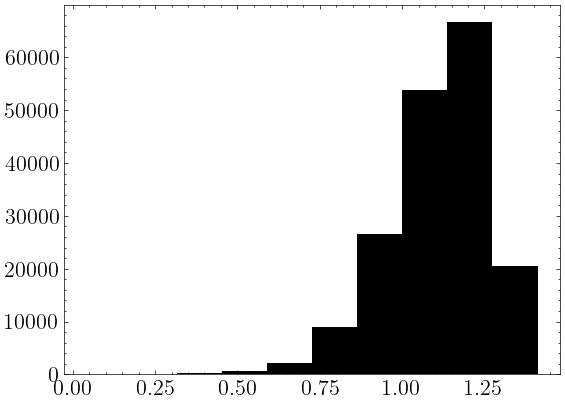

In [45]:
plt.hist(z_067_c1L_PIE_logt_cool-z_067_c1L_PIE_logt_OVI_rec)

In [46]:
get_quantiles(z_067_c1L_PIE_logt_cool-z_067_c1L_PIE_logt_OVI_rec)

1.13 -0.17 0.12


(array([  115.,   160.,   332.,   640.,  2022.,  8915., 26244., 53407.,
        67101., 21064.]),
 array([0.20082416, 0.3368001 , 0.47277604, 0.60875199, 0.74472793,
        0.88070387, 1.01667982, 1.15265576, 1.2886317 , 1.42460765,
        1.56058359]),
 <BarContainer object of 10 artists>)

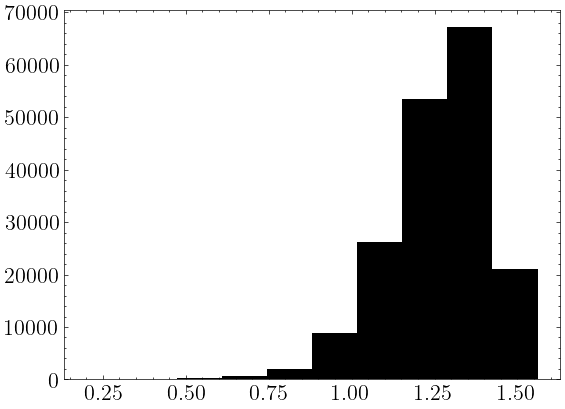

In [47]:
plt.hist(z_067_c1L_PIE_logt_cool-z_067_c1L_PIE_logt_OVII_rec)

In [48]:
get_quantiles(z_067_c1L_PIE_logt_cool-z_067_c1L_PIE_logt_OVII_rec)

1.28 -0.17 0.12


In [49]:
z_067_c1L_metals = z_067_c1_PIE_samples['log_metals_p2']
z_067_c1L_cool_OVI = z_067_c1L_PIE_logt_cool-z_067_c1L_PIE_logt_OVI_rec
z_067_c1L_cool_OVII = z_067_c1L_PIE_logt_cool-z_067_c1L_PIE_logt_OVII_rec

(array([ 1895., 13449., 32968., 45279., 41998., 29191., 12033.,  2279.,
          633.,   275.]),
 array([-1.18256143, -0.96620657, -0.74985171, -0.53349685, -0.31714199,
        -0.10078714,  0.11556772,  0.33192258,  0.54827744,  0.76463229,
         0.98098715]),
 <BarContainer object of 10 artists>)

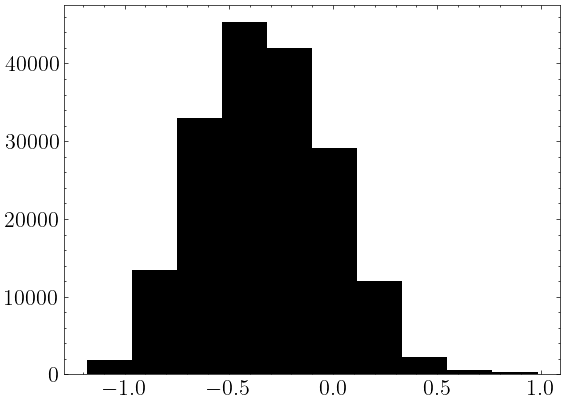

In [50]:
plt.hist(z_067_c1L_metals)

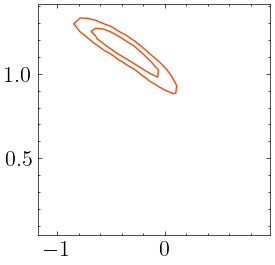

In [51]:
fig, ax = plt.subplots(1,figsize=(3,3))

corner.hist2d(np.array(z_067_c1_PIE_samples['log_metals_p2']), 
              np.array(z_067_c1L_cool_OVI), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[1-np.exp(-0.5),2*cdf_1sig-1], color='orangered')

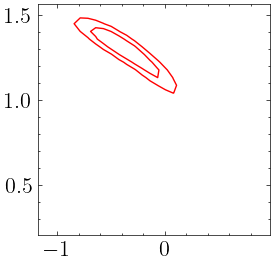

In [52]:
fig, ax = plt.subplots(1,figsize=(3,3))

corner.hist2d(np.array(z_067_c1_PIE_samples['log_metals_p2']), 
              np.array(z_067_c1L_cool_OVII), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[1-np.exp(-0.5),2*cdf_1sig-1], color='red')

# z=1.04, PIE

## c1

In [239]:
z_104_c1_PIE_samples = pd.read_csv(loaddir+'z=1.04430803/cloudy_fits/two_phase_c1.csv')

### c1H

In [240]:
z_104_c1H_PIE_logT, z_104_c1H_PIE_logt_rec, z_104_c1H_PIE_logt_cool = get_cooling_dist(z_104_c1_PIE_samples['log_hdens_p1'],
                                                                                             z_104_c1_PIE_samples['log_metals_p1'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([ 3007.,  7118., 14750., 21502., 32234., 46975., 33877., 15898.,
         4269.,   370.]),
 array([3.82127927, 3.86311106, 3.90494284, 3.94677462, 3.98860641,
        4.03043819, 4.07226997, 4.11410175, 4.15593354, 4.19776532,
        4.2395971 ]),
 <BarContainer object of 10 artists>)

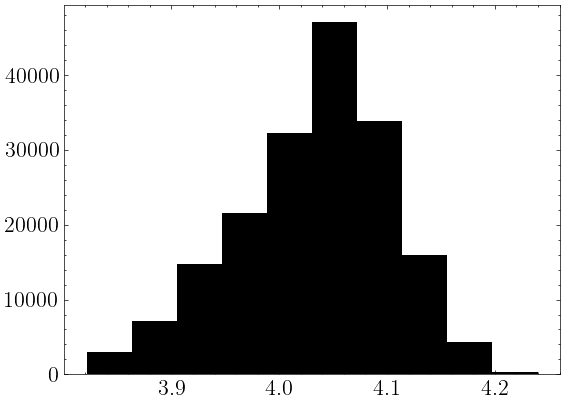

In [241]:
plt.hist(z_104_c1H_PIE_logT)

In [243]:
get_quantiles(z_104_c1H_PIE_logT)

4.04 -0.09 0.06


(array([2.2800e+02, 5.0000e+01, 3.9300e+02, 5.5870e+03, 2.9029e+04,
        5.7502e+04, 5.6470e+04, 2.5523e+04, 4.9240e+03, 2.9400e+02]),
 array([0.02301214, 0.12607932, 0.22914649, 0.33221367, 0.43528085,
        0.53834802, 0.6414152 , 0.74448238, 0.84754955, 0.95061673,
        1.05368391]),
 <BarContainer object of 10 artists>)

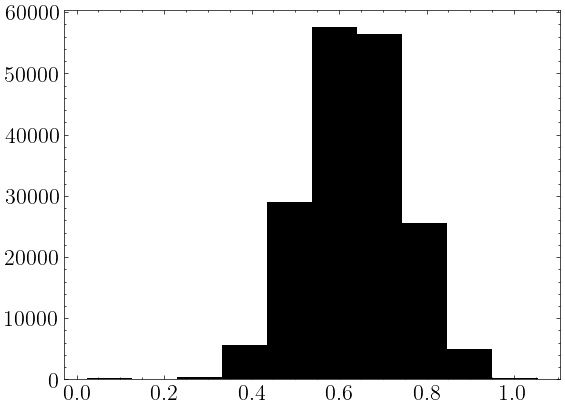

In [244]:
plt.hist(z_104_c1H_PIE_logt_rec)

In [245]:
get_quantiles(z_104_c1H_PIE_logt_rec)

0.64 -0.12 0.11


(array([   73.,   827.,  4090., 12282., 23760., 34812., 58768., 34457.,
         9875.,  1056.]),
 array([0.44577857, 0.48908405, 0.53238952, 0.575695  , 0.61900048,
        0.66230595, 0.70561143, 0.7489169 , 0.79222238, 0.83552786,
        0.87883333]),
 <BarContainer object of 10 artists>)

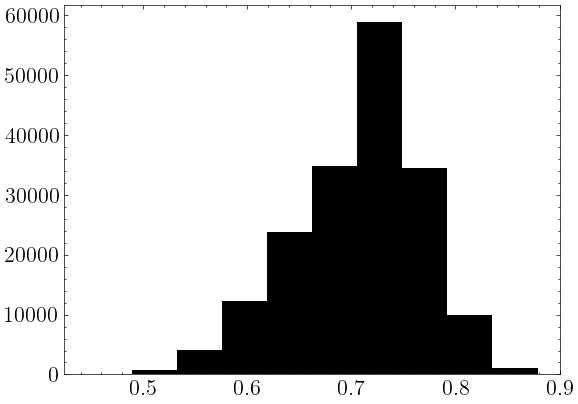

In [246]:
plt.hist(z_104_c1H_PIE_logt_cool-z_104_c1H_PIE_logt_rec)

In [247]:
get_quantiles(z_104_c1H_PIE_logt_cool-z_104_c1H_PIE_logt_rec)

0.72 -0.07 0.05


### c1L

In [248]:
z_104_c1L_PIE_logT, z_104_c1L_PIE_logt_OVI_rec, z_104_c1L_PIE_logt_OVII_rec, z_104_c1L_PIE_logt_cool = get_cooling_dist_hi(z_104_c1_PIE_samples['log_hdens_p2'], 
                                                                                             z_104_c1_PIE_samples['log_metals_p2'],
                                                                                             logq_OVI_rec_interp, logq_OVII_rec_interp, logt_cool_interp)

(array([  154.,   701.,  1424.,  5871., 12039., 19198., 24236., 36165.,
        56631., 23581.]),
 array([3.91438329, 3.99589017, 4.07739704, 4.15890391, 4.24041078,
        4.32191765, 4.40342452, 4.48493139, 4.56643826, 4.64794514,
        4.72945201]),
 <BarContainer object of 10 artists>)

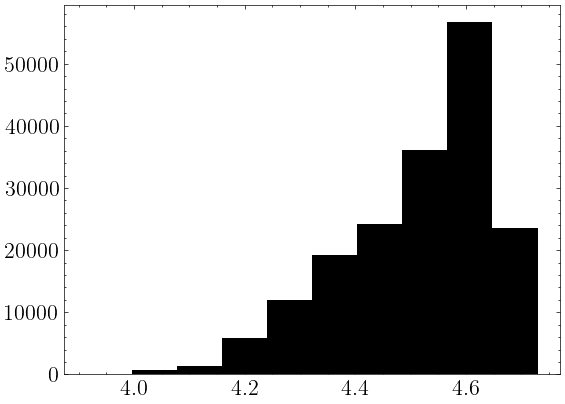

In [249]:
plt.hist(z_104_c1L_PIE_logT)

In [250]:
get_quantiles(z_104_c1L_PIE_logT)

4.55 -0.19 0.09


In [251]:
np.median(z_104_c1L_PIE_logT)

4.547633122036491

(array([  300.,  2047.,  9582., 20549., 28016., 40769., 45298., 27104.,
         5481.,   854.]),
 array([1.03943822, 1.21587525, 1.39231228, 1.56874931, 1.74518634,
        1.92162337, 2.0980604 , 2.27449743, 2.45093446, 2.62737149,
        2.80380852]),
 <BarContainer object of 10 artists>)

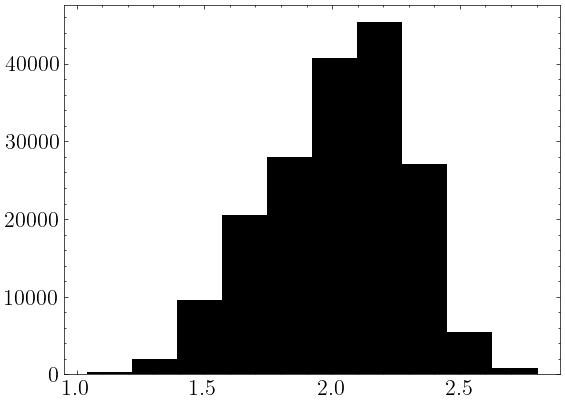

In [252]:
plt.hist(z_104_c1L_PIE_logt_OVI_rec)

In [253]:
get_quantiles(z_104_c1L_PIE_logt_OVI_rec)

2.05 -0.34 0.24


(array([  300.,  2057.,  9557., 20460., 27788., 40491., 45496., 27486.,
         5511.,   854.]),
 array([0.88133371, 1.05896071, 1.23658771, 1.41421472, 1.59184172,
        1.76946872, 1.94709572, 2.12472272, 2.30234973, 2.47997673,
        2.65760373]),
 <BarContainer object of 10 artists>)

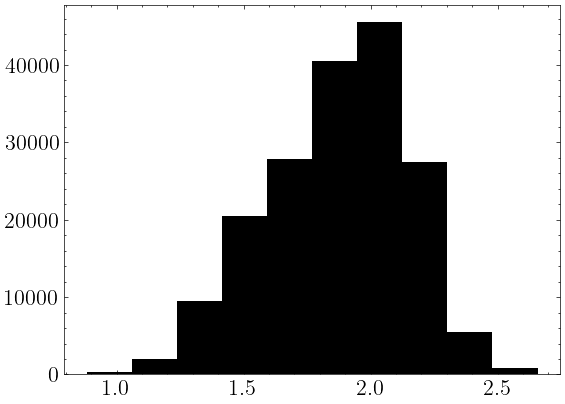

In [254]:
plt.hist(z_104_c1L_PIE_logt_OVII_rec)

In [255]:
get_quantiles(z_104_c1L_PIE_logt_OVII_rec)

1.9 -0.34 0.24


(array([  159.,  1897.,  3694.,  6366.,  8775., 12504., 17885., 27374.,
        49768., 51578.]),
 array([0.18893316, 0.32904016, 0.46914716, 0.60925417, 0.74936117,
        0.88946817, 1.02957517, 1.16968217, 1.30978917, 1.44989618,
        1.59000318]),
 <BarContainer object of 10 artists>)

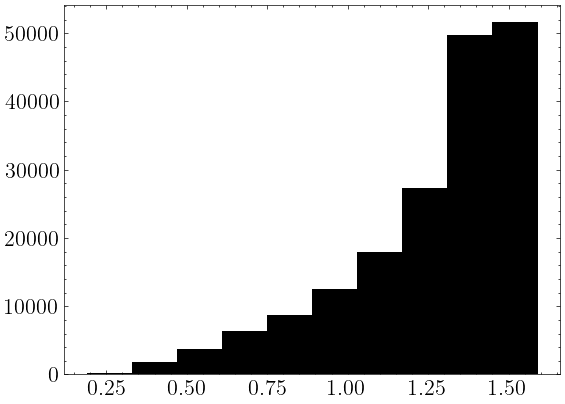

In [256]:
plt.hist(z_104_c1L_PIE_logt_cool-z_104_c1L_PIE_logt_OVI_rec)

In [257]:
get_quantiles(z_104_c1L_PIE_logt_cool-z_104_c1L_PIE_logt_OVI_rec)

1.35 -0.37 0.15


In [258]:
np.percentile(z_104_c1L_PIE_logt_cool-z_104_c1L_PIE_logt_OVI_rec, 100*cdf_1sig)-np.median(z_104_c1L_PIE_logt_cool-z_104_c1L_PIE_logt_OVI_rec)

0.1469239618344309

(array([  154.,  1804.,  3566.,  6433.,  8660., 12384., 17751., 27401.,
        49942., 51905.]),
 array([0.34090241, 0.48046147, 0.62002052, 0.75957958, 0.89913864,
        1.0386977 , 1.17825675, 1.31781581, 1.45737487, 1.59693392,
        1.73649298]),
 <BarContainer object of 10 artists>)

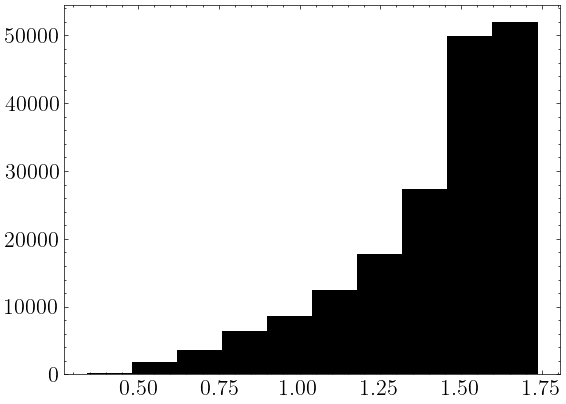

In [259]:
plt.hist(z_104_c1L_PIE_logt_cool-z_104_c1L_PIE_logt_OVII_rec)

In [260]:
get_quantiles(z_104_c1L_PIE_logt_cool-z_104_c1L_PIE_logt_OVII_rec)

1.5 -0.36 0.15


In [261]:
np.percentile(z_104_c1L_PIE_logt_cool-z_104_c1L_PIE_logt_OVII_rec, 100*cdf_1sig)-np.median(z_104_c1L_PIE_logt_cool-z_104_c1L_PIE_logt_OVII_rec)

0.1455804904535909

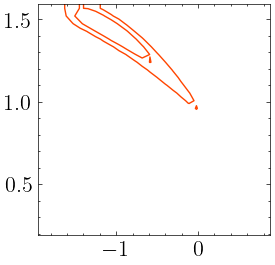

In [262]:
fig, ax = plt.subplots(1,figsize=(3,3))

corner.hist2d(np.array(z_104_c1_PIE_samples['log_metals_p2']), 
              np.array(z_104_c1L_PIE_logt_cool-z_104_c1L_PIE_logt_OVI_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[1-np.exp(-0.5),2*cdf_1sig-1], color='orangered')

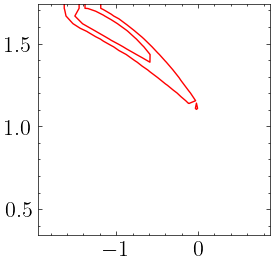

In [263]:
fig, ax = plt.subplots(1,figsize=(3,3))

corner.hist2d(np.array(z_104_c1_PIE_samples['log_metals_p2']), 
              np.array(z_104_c1L_PIE_logt_cool-z_104_c1L_PIE_logt_OVII_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[1-np.exp(-0.5),2*cdf_1sig-1], color='red')

## c2

In [264]:
z_104_c2_PIE_samples = pd.read_csv(loaddir+'z=1.04430803/cloudy_fits/one_phase_c2.csv')

In [265]:
z_104_c2_PIE_logT, z_104_c2_PIE_logt_rec, z_104_c2_PIE_logt_cool = get_cooling_dist(z_104_c2_PIE_samples['log_hdens'],
                                                                                    z_104_c2_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([2.8000e+01, 1.9100e+02, 1.0590e+03, 7.6570e+03, 4.2309e+04,
        1.8595e+04, 8.2900e+03, 1.4460e+03, 3.7800e+02, 4.7000e+01]),
 array([3.66368475, 3.71486221, 3.76603967, 3.81721713, 3.86839459,
        3.91957205, 3.97074951, 4.02192697, 4.07310442, 4.12428188,
        4.17545934]),
 <BarContainer object of 10 artists>)

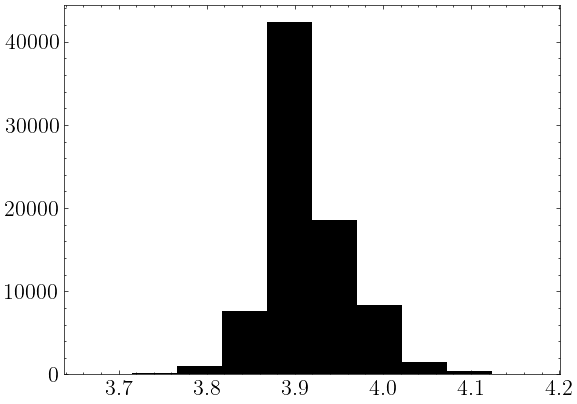

In [266]:
plt.hist(z_104_c2_PIE_logT)

In [267]:
get_quantiles(z_104_c2_PIE_logT)

3.9 -0.03 0.06


(array([   80.,  1361., 10934., 32619., 19308., 10075.,  3964.,  1395.,
          227.,    37.]),
 array([0.6168236 , 0.67687702, 0.73693044, 0.79698386, 0.85703728,
        0.91709069, 0.97714411, 1.03719753, 1.09725095, 1.15730437,
        1.21735779]),
 <BarContainer object of 10 artists>)

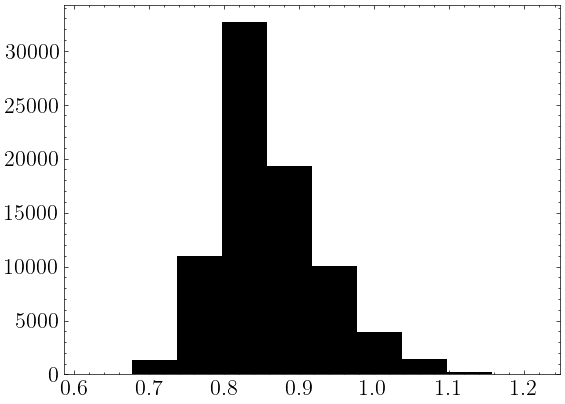

In [268]:
plt.hist(z_104_c2_PIE_logt_rec)

In [269]:
get_quantiles(z_104_c2_PIE_logt_rec)

0.85 -0.05 0.09


In [270]:
np.median(z_104_c2_PIE_logt_rec)

0.845526512353818

(array([1.3000e+01, 3.5800e+02, 3.5570e+03, 1.8972e+04, 2.5401e+04,
        1.6146e+04, 1.0566e+04, 3.9400e+03, 9.3300e+02, 1.1400e+02]),
 array([0.08488872, 0.15058292, 0.21627713, 0.28197133, 0.34766553,
        0.41335973, 0.47905393, 0.54474813, 0.61044233, 0.67613654,
        0.74183074]),
 <BarContainer object of 10 artists>)

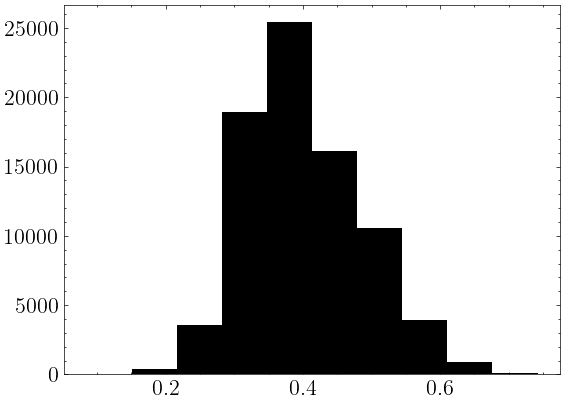

In [271]:
plt.hist(z_104_c2_PIE_logt_cool-z_104_c2_PIE_logt_rec)

In [272]:
get_quantiles(z_104_c2_PIE_logt_cool-z_104_c2_PIE_logt_rec)

0.39 -0.07 0.11


## c3

In [273]:
z_104_c3_PIE_samples = pd.read_csv(loaddir+'z=1.04430803/cloudy_fits/two_phase_c3.csv')

### c3H

In [274]:
z_104_c3H_PIE_logT, z_104_c3H_PIE_logt_rec, z_104_c3H_PIE_logt_cool = get_cooling_dist(z_104_c3_PIE_samples['log_hdens_p1'],
                                                                                             z_104_c3_PIE_samples['log_metals_p1'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([   92.,   431.,  2069., 12853., 59816., 84919., 18377.,   553.,
          531.,   359.]),
 array([3.95006237, 4.00871418, 4.06736598, 4.12601778, 4.18466959,
        4.24332139, 4.3019732 , 4.360625  , 4.4192768 , 4.47792861,
        4.53658041]),
 <BarContainer object of 10 artists>)

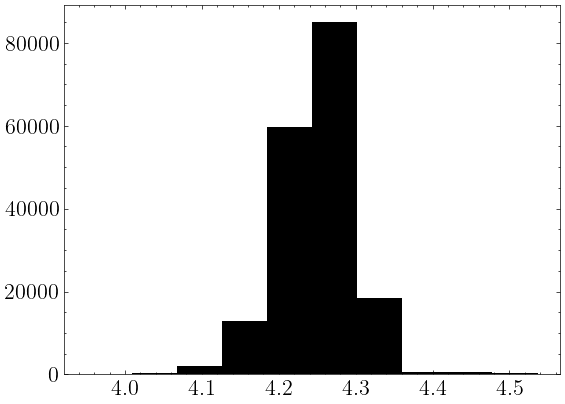

In [275]:
plt.hist(z_104_c3H_PIE_logT)

In [276]:
get_quantiles(z_104_c3H_PIE_logT)

4.25 -0.05 0.04


(array([  111.,   509.,  2809., 11466., 27799., 39874., 44763., 31681.,
        16447.,  4541.]),
 array([0.01343454, 0.17673869, 0.34004285, 0.503347  , 0.66665116,
        0.82995531, 0.99325946, 1.15656362, 1.31986777, 1.48317192,
        1.64647608]),
 <BarContainer object of 10 artists>)

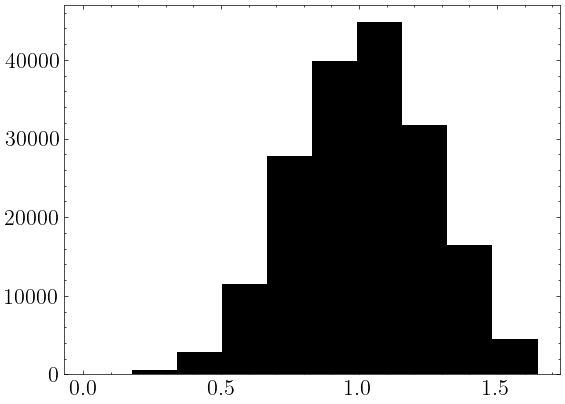

In [277]:
plt.hist(z_104_c3H_PIE_logt_rec)

In [278]:
get_quantiles(z_104_c3H_PIE_logt_rec)

1.02 -0.26 0.25


In [279]:
np.median(z_104_c3H_PIE_logt_rec)-np.percentile(z_104_c3H_PIE_logt_rec,100*(1-cdf_1sig))

0.2558939816761816

In [280]:
np.percentile(z_104_c3H_PIE_logt_rec, 100*cdf_1sig)-np.median(z_104_c3H_PIE_logt_rec)

0.253480090304361

(array([  162.,  2194., 25838., 85867., 53184., 10187.,  1517.,   256.,
          483.,   312.]),
 array([0.71777949, 0.76389378, 0.81000808, 0.85612237, 0.90223667,
        0.94835097, 0.99446526, 1.04057956, 1.08669385, 1.13280815,
        1.17892244]),
 <BarContainer object of 10 artists>)

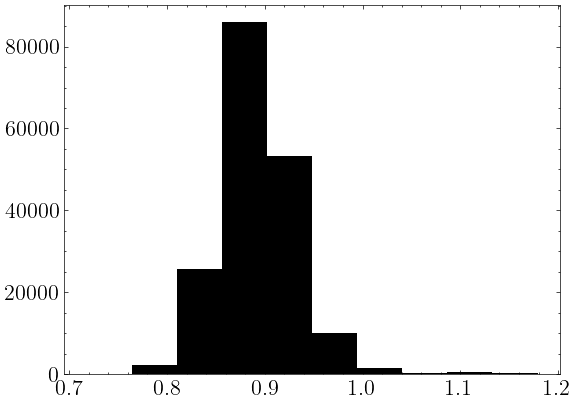

In [281]:
plt.hist(z_104_c3H_PIE_logt_cool-z_104_c3H_PIE_logt_rec)

In [282]:
get_quantiles(z_104_c3H_PIE_logt_cool-z_104_c3H_PIE_logt_rec)

0.89 -0.03 0.04


### c3L

In [283]:
z_104_c3L_PIE_logT, z_104_c3L_PIE_logt_OVI_rec, z_104_c3L_PIE_logt_OVII_rec, z_104_c3L_PIE_logt_cool = get_cooling_dist_hi(z_104_c3_PIE_samples['log_hdens_p2'],
                                                                                             z_104_c3_PIE_samples['log_metals_p2'],
                                                                                             logq_OVI_rec_interp, logq_OVII_rec_interp, logt_cool_interp)

(array([   72.,   385.,  2015.,  7537., 19733., 44030., 55648., 38189.,
        11697.,   694.]),
 array([3.93062748, 4.01028798, 4.08994847, 4.16960897, 4.24926947,
        4.32892997, 4.40859047, 4.48825097, 4.56791147, 4.64757197,
        4.72723246]),
 <BarContainer object of 10 artists>)

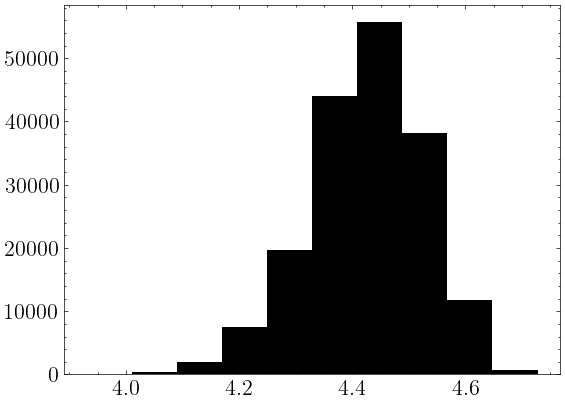

In [284]:
plt.hist(z_104_c3L_PIE_logT)

In [285]:
get_quantiles(z_104_c3L_PIE_logT)

4.43 -0.11 0.1


(array([ 1725., 20455., 59474., 49218., 30056., 13846.,  3745.,   935.,
          339.,   207.]),
 array([1.2375385 , 1.39344465, 1.5493508 , 1.70525695, 1.8611631 ,
        2.01706925, 2.1729754 , 2.32888155, 2.4847877 , 2.64069385,
        2.7966    ]),
 <BarContainer object of 10 artists>)

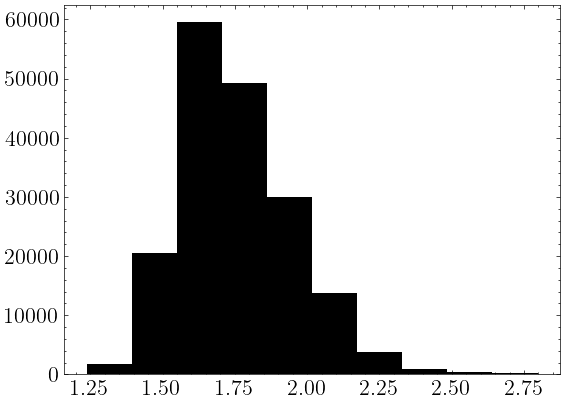

In [286]:
plt.hist(z_104_c3L_PIE_logt_OVI_rec)

In [287]:
get_quantiles(z_104_c3L_PIE_logt_OVI_rec)

1.73 -0.16 0.23


(array([ 1725., 20327., 59189., 49266., 30142., 14069.,  3785.,   942.,
          348.,   207.]),
 array([1.08147001, 1.23836312, 1.39525622, 1.55214932, 1.70904243,
        1.86593553, 2.02282864, 2.17972174, 2.33661484, 2.49350795,
        2.65040105]),
 <BarContainer object of 10 artists>)

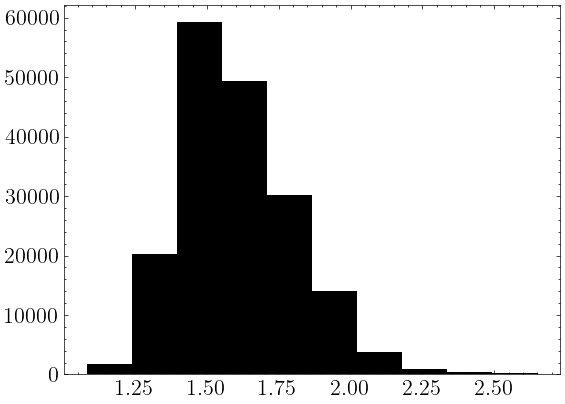

In [288]:
plt.hist(z_104_c3L_PIE_logt_OVII_rec)

In [289]:
get_quantiles(z_104_c3L_PIE_logt_OVII_rec)

1.58 -0.16 0.23


In [290]:
np.median(z_104_c3L_PIE_logt_OVII_rec)

1.5754380833034023

(array([  102.,   655.,  1563.,  2754.,  5137., 10592., 25332., 52564.,
        63876., 17425.]),
 array([0.0904054 , 0.23534339, 0.38028139, 0.52521938, 0.67015738,
        0.81509537, 0.96003337, 1.10497137, 1.24990936, 1.39484736,
        1.53978535]),
 <BarContainer object of 10 artists>)

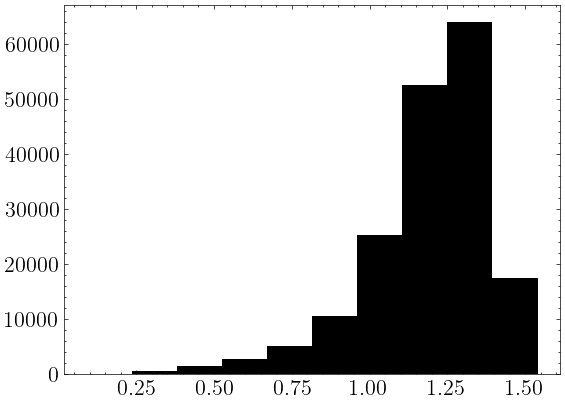

In [291]:
plt.hist(z_104_c3L_PIE_logt_cool-z_104_c3L_PIE_logt_OVI_rec)

In [292]:
get_quantiles(z_104_c3L_PIE_logt_cool-z_104_c3L_PIE_logt_OVI_rec)

1.23 -0.21 0.13


(array([  102.,   646.,  1550.,  2699.,  5103., 10425., 24819., 52402.,
        64621., 17633.]),
 array([0.24787268, 0.39180075, 0.53572883, 0.67965691, 0.82358499,
        0.96751306, 1.11144114, 1.25536922, 1.3992973 , 1.54322537,
        1.68715345]),
 <BarContainer object of 10 artists>)

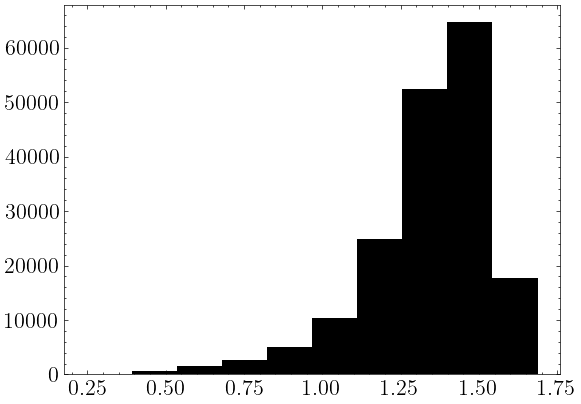

In [293]:
plt.hist(z_104_c3L_PIE_logt_cool-z_104_c3L_PIE_logt_OVII_rec)

In [294]:
get_quantiles(z_104_c3L_PIE_logt_cool-z_104_c3L_PIE_logt_OVII_rec)

1.38 -0.21 0.13


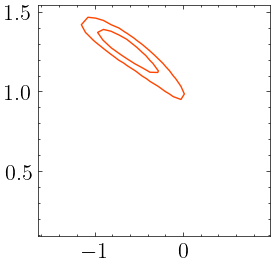

In [295]:
fig, ax = plt.subplots(1,figsize=(3,3))

corner.hist2d(np.array(z_104_c3_PIE_samples['log_metals_p2']), 
              np.array(z_104_c3L_PIE_logt_cool-z_104_c3L_PIE_logt_OVI_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[1-np.exp(-0.5),2*cdf_1sig-1], color='orangered')

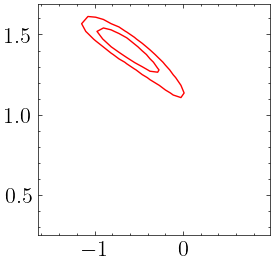

In [296]:
fig, ax = plt.subplots(1,figsize=(3,3))

corner.hist2d(np.array(z_104_c3_PIE_samples['log_metals_p2']), 
              np.array(z_104_c3L_PIE_logt_cool-z_104_c3L_PIE_logt_OVII_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[1-np.exp(-0.5),2*cdf_1sig-1], color='red')

## c4

In [297]:
z_104_c4_PIE_samples = pd.read_csv(loaddir+'z=1.04430803/cloudy_fits/one_phase_c4.csv')

In [298]:
z_104_c4_PIE_logT, z_104_c4_PIE_logt_rec, z_104_c4_PIE_logt_cool = get_cooling_dist(z_104_c4_PIE_samples['log_hdens'],
                                                                                    z_104_c4_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([   39.,   332.,  1956.,  8367., 20275., 25654., 16508.,  5850.,
          956.,    63.]),
 array([4.20862932, 4.22667773, 4.24472613, 4.26277454, 4.28082294,
        4.29887134, 4.31691975, 4.33496815, 4.35301656, 4.37106496,
        4.38911336]),
 <BarContainer object of 10 artists>)

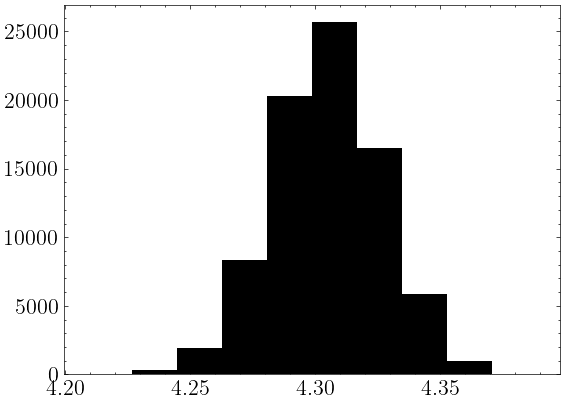

In [299]:
plt.hist(z_104_c4_PIE_logT)

In [300]:
get_quantiles(z_104_c4_PIE_logT)

4.31 -0.02 0.02


(array([   49.,   513.,  3756., 13042., 23349., 23241., 12031.,  3420.,
          553.,    46.]),
 array([0.88120592, 0.93180093, 0.98239595, 1.03299096, 1.08358598,
        1.134181  , 1.18477601, 1.23537103, 1.28596604, 1.33656106,
        1.38715607]),
 <BarContainer object of 10 artists>)

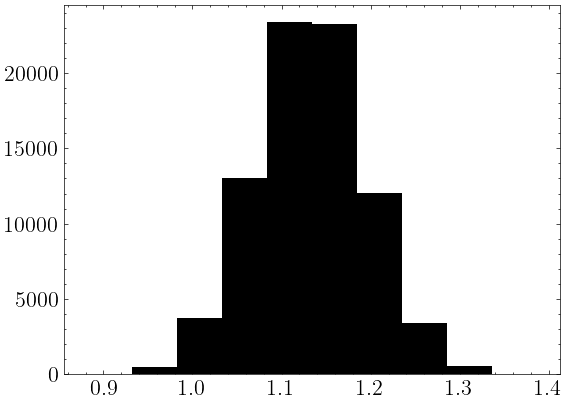

In [301]:
plt.hist(z_104_c4_PIE_logt_rec)

In [302]:
get_quantiles(z_104_c4_PIE_logt_rec)

1.13 -0.06 0.06


(array([   34.,   209.,  1512.,  6474., 19567., 26696., 18008.,  6255.,
         1203.,    42.]),
 array([0.84770187, 0.86486934, 0.88203681, 0.89920428, 0.91637175,
        0.93353923, 0.9507067 , 0.96787417, 0.98504164, 1.00220911,
        1.01937658]),
 <BarContainer object of 10 artists>)

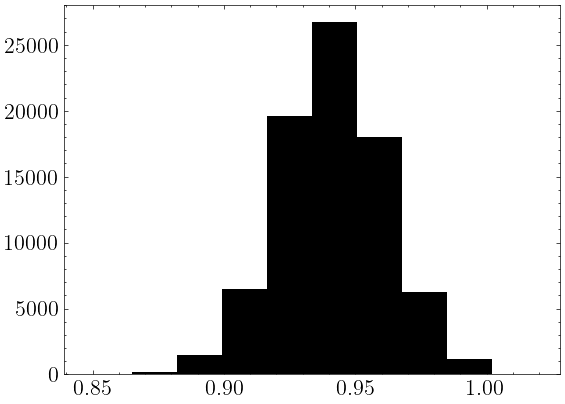

In [303]:
plt.hist(z_104_c4_PIE_logt_cool-z_104_c4_PIE_logt_rec)

In [304]:
get_quantiles(z_104_c4_PIE_logt_cool-z_104_c4_PIE_logt_rec)

0.94 -0.02 0.02


# z=1.09, PIE

## c1

In [117]:
z_109_c1_PIE_samples = pd.read_csv(loaddir+'z=1.09456549/cloudy_fits/two_phase.csv')

### c1H

In [118]:
z_109_c1H_PIE_logT, z_109_c1H_PIE_logt_rec, z_109_c1H_PIE_logt_cool = get_cooling_dist(z_109_c1_PIE_samples['log_hdens_p1'],
                                                                                       z_109_c1_PIE_samples['log_metals_p1'],
                                                                                       logq_rec_interp, logt_cool_interp)

(array([ 2674., 10287., 24137., 37789., 51568., 32699., 14766.,  4000.,
         1451.,   629.]),
 array([3.82740407, 3.87791098, 3.92841789, 3.97892479, 4.0294317 ,
        4.07993861, 4.13044552, 4.18095242, 4.23145933, 4.28196624,
        4.33247315]),
 <BarContainer object of 10 artists>)

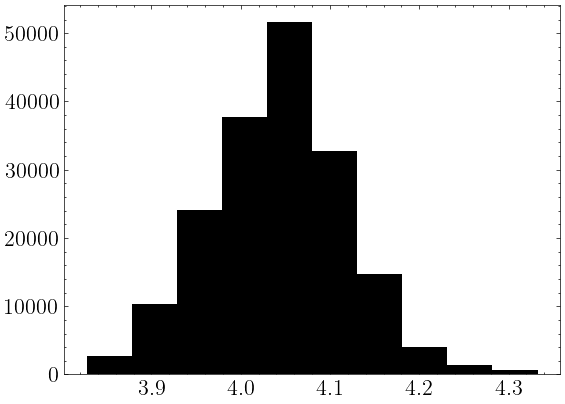

In [119]:
plt.hist(z_109_c1H_PIE_logT)

In [120]:
get_quantiles(z_109_c1H_PIE_logT), np.percentile(z_109_c1H_PIE_logT,100*cdf_3sig)

4.05 -0.08 0.07


(None, 4.29913998807681)

(array([  387.,  1776.,  9357., 29332., 51378., 51863., 28590.,  6282.,
          894.,   141.]),
 array([0.30213279, 0.37404489, 0.445957  , 0.51786911, 0.58978121,
        0.66169332, 0.73360542, 0.80551753, 0.87742963, 0.94934174,
        1.02125384]),
 <BarContainer object of 10 artists>)

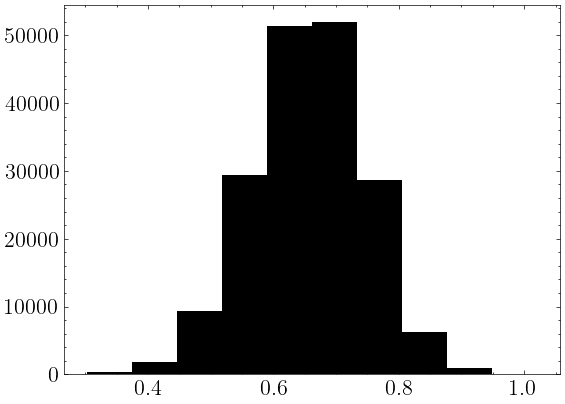

In [121]:
plt.hist(z_109_c1H_PIE_logt_rec)

In [122]:
get_quantiles(z_109_c1H_PIE_logt_rec)

0.66 -0.09 0.09


(array([ 1370.,  9345., 27003., 40561., 53833., 29204., 13794.,  3441.,
         1223.,   226.]),
 array([0.46694938, 0.52576928, 0.58458918, 0.64340908, 0.70222898,
        0.76104888, 0.81986879, 0.87868869, 0.93750859, 0.99632849,
        1.05514839]),
 <BarContainer object of 10 artists>)

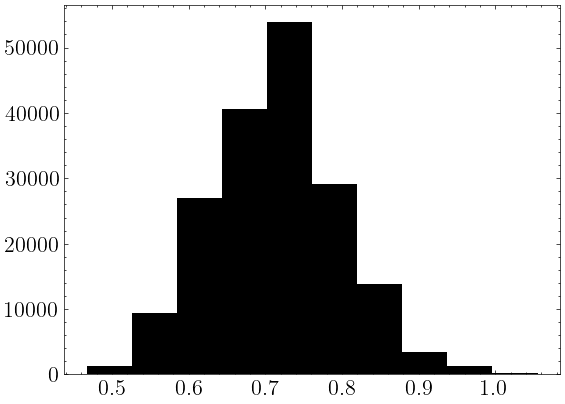

In [123]:
plt.hist(z_109_c1H_PIE_logt_cool-z_109_c1H_PIE_logt_rec)

In [124]:
get_quantiles(z_109_c1H_PIE_logt_cool-z_109_c1H_PIE_logt_rec)

0.71 -0.09 0.08


### c1L

In [125]:
z_109_c1L_PIE_logT, z_109_c1L_PIE_logt_OVI_rec, z_109_c1L_PIE_logt_OVII_rec, z_109_c1L_PIE_logt_cool = get_cooling_dist_hi(z_109_c1_PIE_samples['log_hdens_p2'],
                                                                                       z_109_c1_PIE_samples['log_metals_p2'],
                                                                                       logq_OVI_rec_interp, logq_OVII_rec_interp, logt_cool_interp)

(array([  695.,  4638., 17024., 26981., 23139., 31796., 34884., 27942.,
        11300.,  1601.]),
 array([3.74821835, 3.81430967, 3.880401  , 3.94649232, 4.01258365,
        4.07867497, 4.14476629, 4.21085762, 4.27694894, 4.34304027,
        4.40913159]),
 <BarContainer object of 10 artists>)

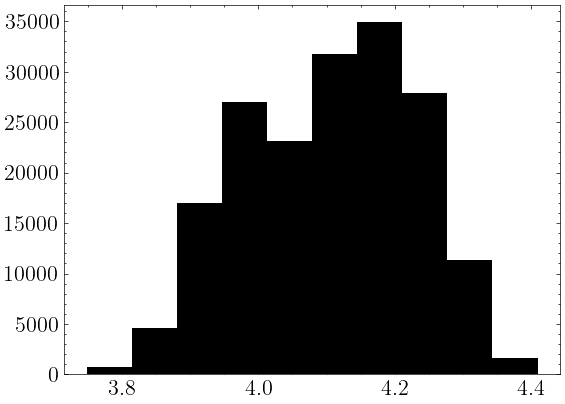

In [126]:
plt.hist(z_109_c1L_PIE_logT)

In [127]:
get_quantiles(z_109_c1L_PIE_logT), np.percentile(z_109_c1L_PIE_logT,100*cdf_3sig)

4.12 -0.15 0.12


(None, 4.383567685573519)

In [128]:
np.median(z_109_c1L_PIE_logT)-np.percentile(z_109_c1L_PIE_logT, 100*(1-cdf_1sig))

0.15174546075926143

(array([  156.,  2791., 12379., 29891., 46330., 48265., 28881.,  9207.,
         1842.,   258.]),
 array([0.76964928, 0.83255625, 0.89546322, 0.95837019, 1.02127716,
        1.08418413, 1.1470911 , 1.20999807, 1.27290503, 1.335812  ,
        1.39871897]),
 <BarContainer object of 10 artists>)

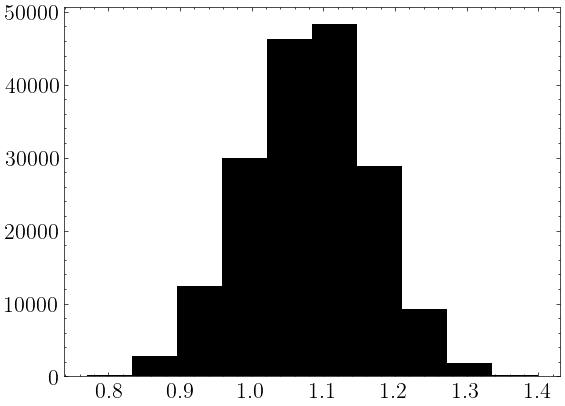

In [129]:
plt.hist(z_109_c1L_PIE_logt_OVI_rec)

In [130]:
get_quantiles(z_109_c1L_PIE_logt_OVI_rec)

1.08 -0.09 0.08


(array([  158.,  2738., 12381., 29723., 46381., 48103., 28974.,  9386.,
         1898.,   258.]),
 array([0.61056327, 0.67393929, 0.73731531, 0.80069132, 0.86406734,
        0.92744336, 0.99081938, 1.05419539, 1.11757141, 1.18094743,
        1.24432345]),
 <BarContainer object of 10 artists>)

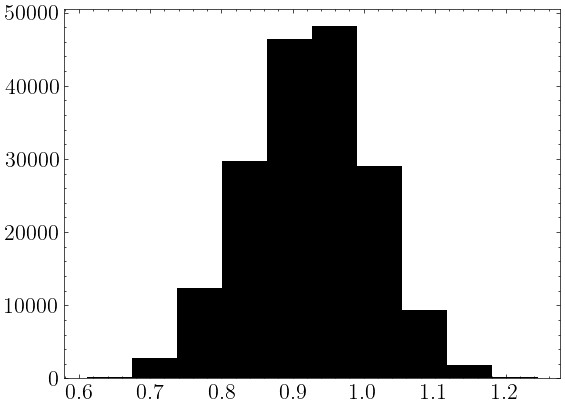

In [131]:
plt.hist(z_109_c1L_PIE_logt_OVII_rec)

In [132]:
get_quantiles(z_109_c1L_PIE_logt_OVII_rec)

0.93 -0.09 0.09


(array([ 2280.,  2385.,  4108., 13154., 18538., 22489., 37871., 40444.,
        32018.,  6713.]),
 array([0.00139663, 0.12896473, 0.25653284, 0.38410094, 0.51166904,
        0.63923714, 0.76680524, 0.89437334, 1.02194144, 1.14950954,
        1.27707765]),
 <BarContainer object of 10 artists>)

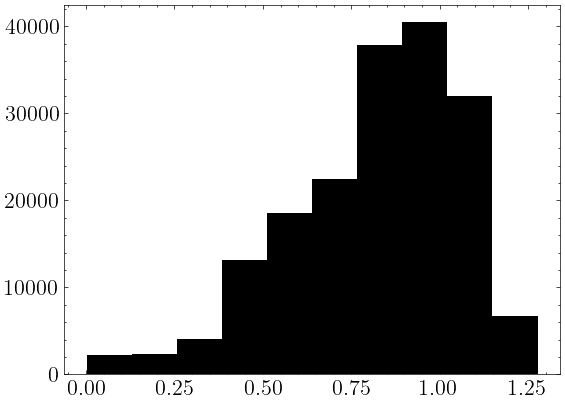

In [133]:
plt.hist(z_109_c1L_PIE_logt_cool-z_109_c1L_PIE_logt_OVI_rec)

In [134]:
get_quantiles(z_109_c1L_PIE_logt_cool-z_109_c1L_PIE_logt_OVI_rec)

0.86 -0.3 0.2


(array([ 2282.,  2411.,  4065., 12948., 18490., 22329., 37663., 40453.,
        32518.,  6841.]),
 array([0.16092905, 0.28775683, 0.41458462, 0.5414124 , 0.66824018,
        0.79506796, 0.92189574, 1.04872352, 1.17555131, 1.30237909,
        1.42920687]),
 <BarContainer object of 10 artists>)

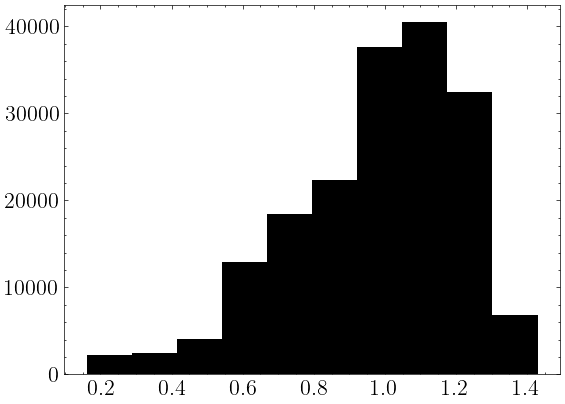

In [135]:
plt.hist(z_109_c1L_PIE_logt_cool-z_109_c1L_PIE_logt_OVII_rec)

In [136]:
get_quantiles(z_109_c1L_PIE_logt_cool-z_109_c1L_PIE_logt_OVII_rec)

1.02 -0.3 0.19


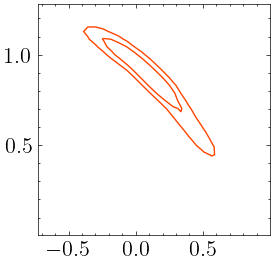

In [137]:
fig, ax = plt.subplots(1,figsize=(3,3))

corner.hist2d(np.array(z_109_c1_PIE_samples['log_metals_p2']), 
              np.array(z_109_c1L_PIE_logt_cool-z_109_c1L_PIE_logt_OVI_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[1-np.exp(-0.5),2*cdf_1sig-1], color='orangered')

ax.axhline(0, linestyle='--')

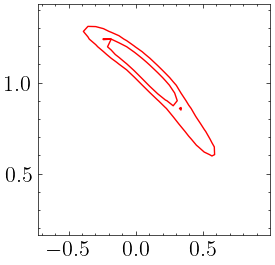

In [138]:
fig, ax = plt.subplots(1,figsize=(3,3))

corner.hist2d(np.array(z_109_c1_PIE_samples['log_metals_p2']), 
              np.array(z_109_c1L_PIE_logt_cool-z_109_c1L_PIE_logt_OVII_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[1-np.exp(-0.5),2*cdf_1sig-1], color='red')

ax.axhline(0, linestyle='--')

# z=1.16, PIE

## c1

In [139]:
z_116_c1_PIE_samples = pd.read_csv(loaddir+'z=1.16590953/cloudy_fits/one_phase_c1.csv')

In [140]:
z_116_c1_PIE_logT, z_116_c1_PIE_logt_rec, z_116_c1_PIE_logt_cool = get_cooling_dist(z_116_c1_PIE_samples['log_hdens'],
                                                                                    z_116_c1_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([   64.,   389.,  2865.,  9893., 19019., 22739., 15890.,  7230.,
         1685.,   226.]),
 array([4.41208048, 4.41788841, 4.42369634, 4.42950427, 4.4353122 ,
        4.44112013, 4.44692806, 4.45273599, 4.45854393, 4.46435186,
        4.47015979]),
 <BarContainer object of 10 artists>)

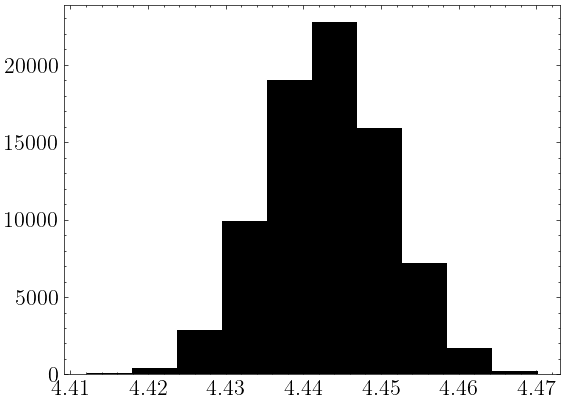

In [141]:
plt.hist(z_116_c1_PIE_logT)

In [142]:
get_quantiles(z_116_c1_PIE_logT)

4.44 -0.01 0.01


(array([   43.,   311.,  2617.,  9178., 18789., 23074., 16767.,  7356.,
         1654.,   211.]),
 array([0.91926468, 0.94756041, 0.97585615, 1.00415188, 1.03244762,
        1.06074336, 1.08903909, 1.11733483, 1.14563056, 1.1739263 ,
        1.20222203]),
 <BarContainer object of 10 artists>)

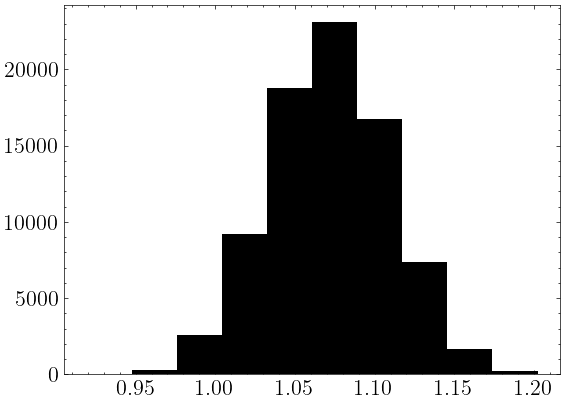

In [143]:
plt.hist(z_116_c1_PIE_logt_rec)

In [144]:
get_quantiles(z_116_c1_PIE_logt_rec)

1.07 -0.04 0.04


(array([   87.,   692.,  4976., 15034., 22988., 21118., 10893.,  3432.,
          669.,   111.]),
 array([1.09992276, 1.10327631, 1.10662987, 1.10998342, 1.11333697,
        1.11669052, 1.12004407, 1.12339762, 1.12675118, 1.13010473,
        1.13345828]),
 <BarContainer object of 10 artists>)

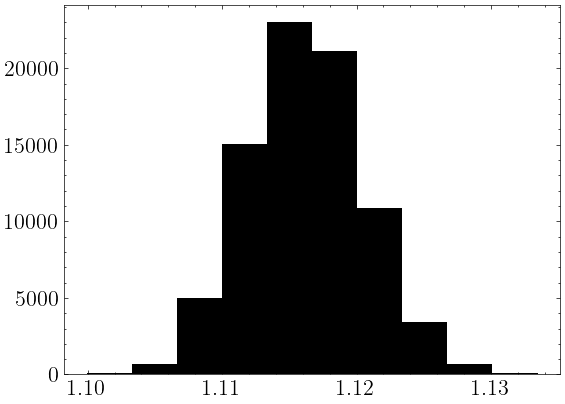

In [145]:
plt.hist(z_116_c1_PIE_logt_cool-z_116_c1_PIE_logt_rec)

In [146]:
get_quantiles(z_116_c1_PIE_logt_cool-z_116_c1_PIE_logt_rec)

1.12 -0.0 0.0


In [147]:
np.median(z_116_c1_PIE_logt_cool-z_116_c1_PIE_logt_rec)

1.1161803359466451

In [148]:
np.percentile(z_116_c1_PIE_logt_cool-z_116_c1_PIE_logt_rec,100*cdf_1sig)

1.1205951832132073

## c2

In [149]:
z_116_c2_PIE_samples = pd.read_csv(loaddir+'z=1.16590953/cloudy_fits/one_phase_c2.csv')

In [150]:
z_116_c2_PIE_logT, z_116_c2_PIE_logt_rec, z_116_c2_PIE_logt_cool = get_cooling_dist(z_116_c2_PIE_samples['log_hdens'],
                                                                                    z_116_c2_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([2.1000e+01, 2.1000e+02, 1.1360e+03, 4.6920e+03, 1.3365e+04,
        2.0705e+04, 2.2787e+04, 1.3337e+04, 3.2920e+03, 4.5500e+02]),
 array([4.42738825, 4.45408202, 4.4807758 , 4.50746957, 4.53416335,
        4.56085712, 4.5875509 , 4.61424467, 4.64093845, 4.66763222,
        4.694326  ]),
 <BarContainer object of 10 artists>)

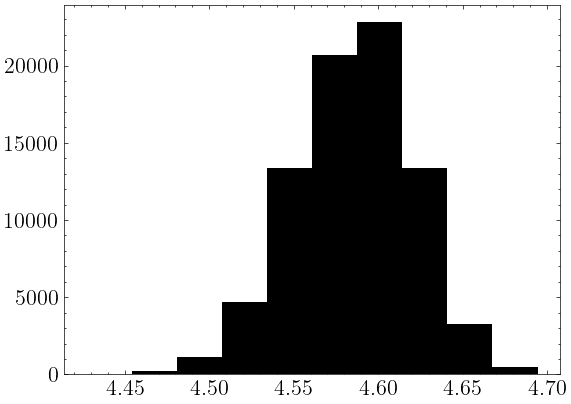

In [151]:
plt.hist(z_116_c2_PIE_logT)

In [152]:
get_quantiles(z_116_c2_PIE_logT)

4.59 -0.04 0.03


(array([   37.,   601.,  3873., 12746., 22182., 22229., 13090.,  4223.,
          928.,    91.]),
 array([1.40810866, 1.51538114, 1.62265362, 1.7299261 , 1.83719858,
        1.94447106, 2.05174354, 2.15901602, 2.2662885 , 2.37356098,
        2.48083346]),
 <BarContainer object of 10 artists>)

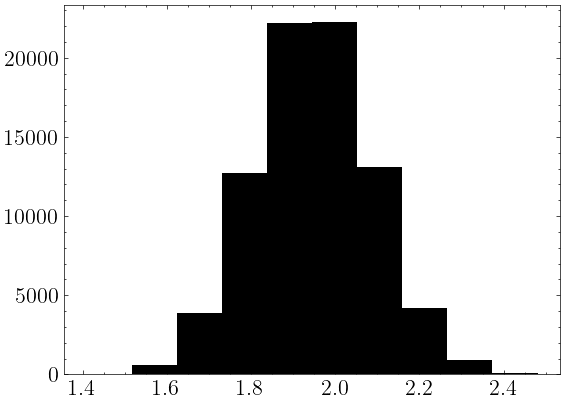

In [153]:
plt.hist(z_116_c2_PIE_logt_rec)

In [154]:
get_quantiles(z_116_c2_PIE_logt_rec)

1.95 -0.14 0.14


In [155]:
np.median(z_116_c2_PIE_logt_rec)

1.9470855460770151

(array([1.8000e+01, 1.6800e+02, 9.1400e+02, 3.5740e+03, 1.0882e+04,
        1.9208e+04, 2.2423e+04, 1.7506e+04, 4.6610e+03, 6.4600e+02]),
 array([1.05607609, 1.08112333, 1.10617056, 1.1312178 , 1.15626504,
        1.18131227, 1.20635951, 1.23140674, 1.25645398, 1.28150121,
        1.30654845]),
 <BarContainer object of 10 artists>)

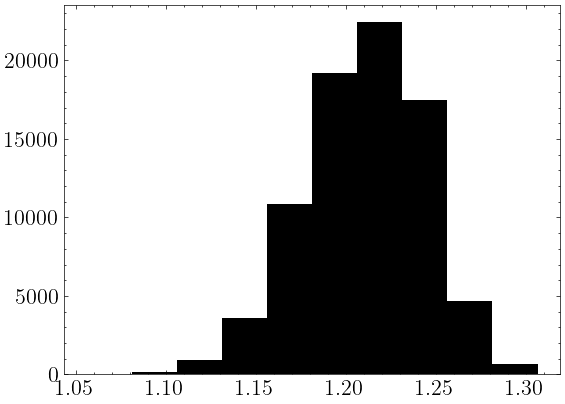

In [156]:
plt.hist(z_116_c2_PIE_logt_cool-z_116_c2_PIE_logt_rec)

In [157]:
get_quantiles(z_116_c2_PIE_logt_cool-z_116_c2_PIE_logt_rec)

1.21 -0.04 0.03


# z=1.22, PIE

## c1

In [158]:
z_122_c1_PIE_samples = pd.read_csv(loaddir+'z=1.22541394/cloudy_fits/one_phase.csv')

In [159]:
z_122_c1_PIE_logT, z_122_c1_PIE_logt_rec, z_122_c1_PIE_logt_cool = get_cooling_dist(z_122_c1_PIE_samples['log_hdens'],
                                                                                    z_122_c1_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([   35.,   177.,  1125.,  5779., 17000., 25626., 21081.,  8367.,
         1643.,   167.]),
 array([4.46108115, 4.4711626 , 4.48124406, 4.49132551, 4.50140696,
        4.51148841, 4.52156986, 4.53165132, 4.54173277, 4.55181422,
        4.56189567]),
 <BarContainer object of 10 artists>)

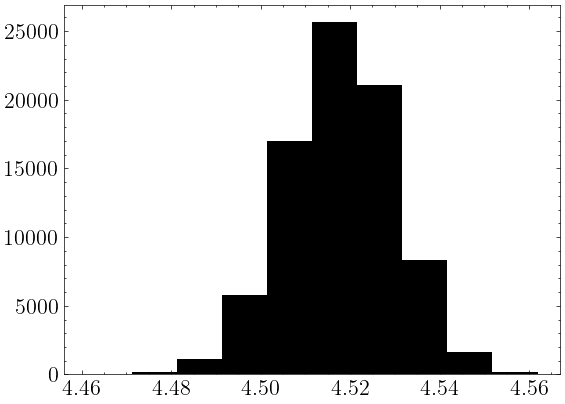

In [160]:
plt.hist(z_122_c1_PIE_logT)

In [161]:
get_quantiles(z_122_c1_PIE_logT)

4.52 -0.01 0.01


(array([   45.,   420.,  2792., 10971., 22998., 25262., 13982.,  3948.,
          523.,    59.]),
 array([2.0501855 , 2.09296551, 2.13574553, 2.17852555, 2.22130556,
        2.26408558, 2.3068656 , 2.34964561, 2.39242563, 2.43520564,
        2.47798566]),
 <BarContainer object of 10 artists>)

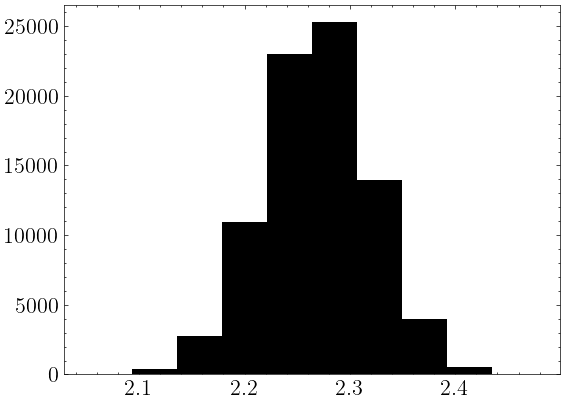

In [162]:
plt.hist(z_122_c1_PIE_logt_rec)

In [163]:
get_quantiles(z_122_c1_PIE_logt_rec)

2.27 -0.05 0.05


(array([   38.,   251.,  1430.,  5835., 15316., 25556., 21248.,  9236.,
         1916.,   174.]),
 array([0.9869291 , 0.99752943, 1.00812976, 1.0187301 , 1.02933043,
        1.03993076, 1.05053109, 1.06113143, 1.07173176, 1.08233209,
        1.09293243]),
 <BarContainer object of 10 artists>)

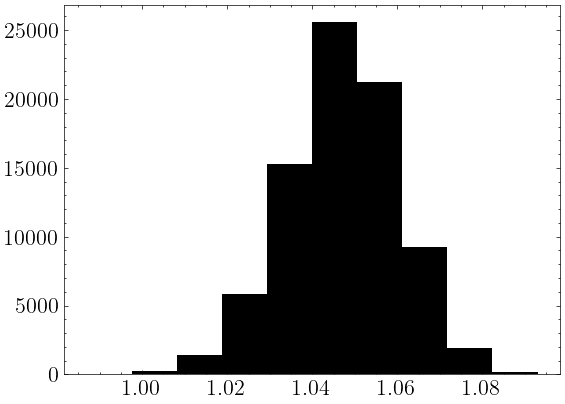

In [164]:
plt.hist(z_122_c1_PIE_logt_cool-z_122_c1_PIE_logt_rec)

In [165]:
get_quantiles(z_122_c1_PIE_logt_cool-z_122_c1_PIE_logt_rec)

1.05 -0.01 0.01


# z=1.26, PIE

## c1

In [33]:
z_126_c1_PIE_samples = pd.read_csv(loaddir+'z=1.25937492/cloudy_fits/one_phase_c1.csv')

In [34]:
z_126_c1_PIE_logT, z_126_c1_PIE_logt_rec, z_126_c1_PIE_logt_cool = get_cooling_dist(z_126_c1_PIE_samples['log_hdens'],
                                                                                    z_126_c1_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

In [35]:
np.median(z_126_c1_PIE_logt_cool)

1.0145819622881107

(array([4.1170e+03, 8.5070e+03, 9.1010e+03, 9.4200e+03, 8.4890e+03,
        8.9590e+03, 3.0862e+04, 3.6100e+02, 1.5400e+02, 3.0000e+01]),
 array([3.65133611, 3.70605641, 3.76077671, 3.81549701, 3.87021732,
        3.92493762, 3.97965792, 4.03437822, 4.08909853, 4.14381883,
        4.19853913]),
 <BarContainer object of 10 artists>)

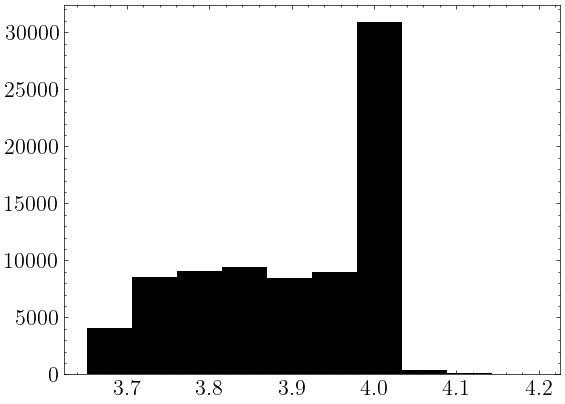

In [36]:
plt.hist(z_126_c1_PIE_logT)

In [37]:
alpha_oxy = np.loadtxt(rootdir+'cloudy_grids/alpha_oxy.dat')
alpha_carb = np.loadtxt(rootdir+'cloudy_grids/alpha_carb.dat')

In [38]:
O_list = ['OII', 'OIII', 'OIV', 'OV', 'OVI', 'OVII', 'OVIII', 'OIX']
C_list = ['CII', 'CIII', 'CIV', 'CV', 'CVI', 'CVII']

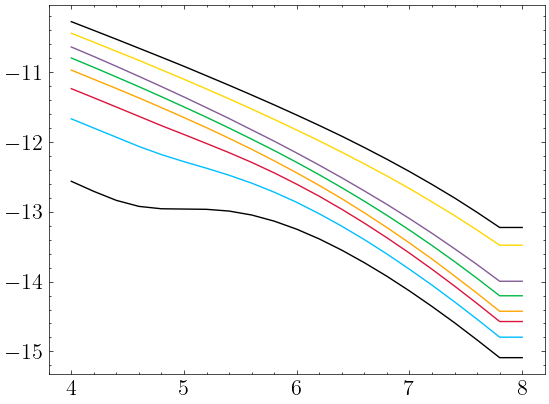

In [39]:
for i in range(len(O_list)):
    plt.plot(logT_rec_grid, np.log10(alpha_oxy[:,i]))

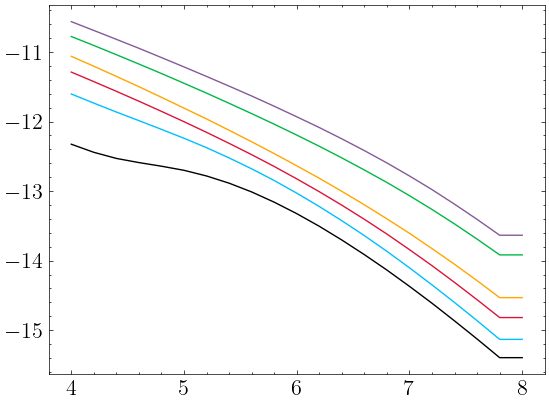

In [40]:
for i in range(len(C_list)):
    plt.plot(logT_rec_grid, np.log10(alpha_carb[:,i]))

In [41]:
alpha_oxy_dict = {}

for i in range(len(O_list)):
    alpha_oxy_dict[O_list[i]] = interp1d(logT_rec_grid, np.log10(alpha_oxy[:,i]), fill_value='extrapolate')
    
alpha_carb_dict = {}

for i in range(len(C_list)):
    alpha_carb_dict[C_list[i]] = interp1d(logT_rec_grid, np.log10(alpha_carb[:,i]), fill_value='extrapolate')

In [42]:
logT_grid_cool = np.log10(np.loadtxt(rootdir+'cloudy_grids/non_eqm_models/PI/PIE/fg20/z=1/log_hdens=-3.3/PIE_frac.cool', skiprows=1)[:,1])
log_Ctot_grid = np.log10(np.loadtxt(rootdir+'cloudy_grids/non_eqm_models/PI/PIE/fg20/z=1/log_hdens=-3.3/PIE_frac.cool', skiprows=1)[:,2])
log_cool_interp = interp1d(logT_grid_cool, log_Ctot_grid, fill_value='extrapolate')

Text(0, 0.5, '$\\log \\Lambda$')

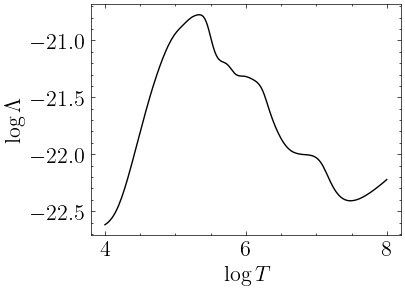

In [43]:
fig, ax = plt.subplots(1, figsize=(4,3))
ax.plot(logT_grid_cool, np.log10((6/7)*10**log_Ctot_grid/(10**-3.3)**2))
#ax.axhline(-28.46+2*3.3, linestyle=':')
#ax.axvline(4.45, linestyle=':')
ax.set_xlabel(r'$\log T$')
ax.set_ylabel(r'$\log \Lambda$')

In [44]:
((4.34*1.5*1.38*1e-16*10**3.95)/(2.25 * 10**-3.3 * 10**-22.63))/3.15576e+13

9.597841856087019

In [45]:
logT_interp([-3.3, 0.6]), logt_cool_interp([-3.3, 0.6])

(array([3.95785372]), array([0.99027815]))

In [46]:
10**0.99027815

9.77863306729228

In [72]:
logT = 4.45
log_Ctot = log_cool_interp([logT])[0]
Ctot = 10**log_Ctot
log_hdens = -3.3
logt_cool = np.log10(((4.34*1.5*(1.38*1e-16*10**logT))/((9/4)*(6/7)*Ctot/(10**log_hdens)))*t_Myr_sec)

In [73]:
10**logt_cool

5.96486081976204

In [74]:
((4.34*1.5*1.38*1e-16*10**4.45)/(2.25 * 10**-3.3 * 10**-21.9))/3.15576e+13

5.651628282063146

In [67]:
logt_rec_oxy = {}
dlogt_rec_lo_oxy = {}
dlogt_rec_hi_oxy = {}

logt_cool_rec_oxy = {}
dlogt_cool_rec_lo_oxy = {}
dlogt_cool_rec_hi_oxy = {}

for i in range(len(O_list)):
    
    logt_rec_samples = logt_rec(z_126_c1_PIE_samples['log_hdens'], logT, alpha_oxy_dict[O_list[i]])
    logt_rec_oxy[O_list[i]] = np.median(logt_rec_samples)
    dlogt_rec_lo_oxy[O_list[i]] = np.median(logt_rec_samples)-np.percentile(logt_rec_samples,100*(1-cdf_1sig))
    dlogt_rec_hi_oxy[O_list[i]] = np.percentile(logt_rec_samples,100*cdf_1sig)-np.median(logt_rec_samples)
    
    logt_cool_rec_samples = logt_cool-logt_rec_samples
    logt_cool_rec_oxy[O_list[i]] = np.median(logt_cool_rec_samples)
    dlogt_cool_rec_lo_oxy[O_list[i]] = np.median(logt_cool_rec_samples)-np.percentile(logt_cool_rec_samples,100*(1-cdf_1sig))
    dlogt_cool_rec_hi_oxy[O_list[i]] = np.percentile(logt_cool_rec_samples,100*cdf_1sig)-np.median(logt_cool_rec_samples)
    
    
logt_rec_carb = {}
dlogt_rec_lo_carb = {}
dlogt_rec_hi_carb = {}

logt_cool_rec_carb = {}
dlogt_cool_rec_lo_carb = {}
dlogt_cool_rec_hi_carb = {}

for i in range(len(C_list)):
    logt_rec_samples = logt_rec(z_126_c1_PIE_samples['log_hdens'], logT, alpha_carb_dict[C_list[i]])
    logt_rec_carb[C_list[i]] = np.median(logt_rec_samples)
    dlogt_rec_lo_carb[C_list[i]] = np.median(logt_rec_samples)-np.percentile(logt_rec_samples,100*(1-cdf_1sig))
    dlogt_rec_hi_carb[C_list[i]] = np.percentile(logt_rec_samples,100*cdf_1sig)-np.median(logt_rec_samples)
    
    logt_cool_rec_samples = logt_cool-logt_rec_samples
    logt_cool_rec_carb[C_list[i]] = np.median(logt_cool_rec_samples)
    dlogt_cool_rec_lo_carb[C_list[i]] = np.median(logt_cool_rec_samples)-np.percentile(logt_cool_rec_samples,100*(1-cdf_1sig))
    dlogt_cool_rec_hi_carb[C_list[i]] = np.percentile(logt_cool_rec_samples,100*cdf_1sig)-np.median(logt_cool_rec_samples)

In [68]:
logt_rec_carb

{'CII': 2.3229383811575537,
 'CIII': 1.6720384424304018,
 'CIV': 1.3787974781092323,
 'CV': 1.1655222143854558,
 'CVI': 0.8503978971313794,
 'CVII': 0.628135872144566}

In [69]:
for i in range(len(logt_rec_oxy)):
    k = list(logt_rec_oxy.keys())[i]
    print(k + ': ' + str(int(np.round(10**logt_rec_oxy[k]))) + ' Myr')

OII: 434 Myr
OIII: 56 Myr
OIV: 21 Myr
OV: 11 Myr
OVI: 8 Myr
OVII: 5 Myr
OVIII: 3 Myr
OIX: 2 Myr


In [70]:
for i in range(len(logt_rec_carb)):
    k = list(logt_rec_carb.keys())[i]
    print(k + ': ' + str(int(np.round(10**logt_rec_carb[k]))) + ' Myr')

CII: 210 Myr
CIII: 47 Myr
CIV: 24 Myr
CV: 15 Myr
CVI: 7 Myr
CVII: 4 Myr


Text(0, 0.5, '$\\log(t_\\mathrm{rec}/\\mathrm{Myr})$')

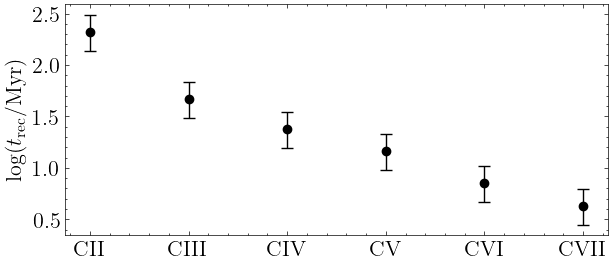

In [50]:
fig, ax = plt.subplots(1, figsize=(7,3))

for i in range(len(logt_rec_carb)):
    ax.errorbar(i, logt_rec_carb[C_list[i]], yerr=[[dlogt_rec_lo_carb[C_list[i]]],[dlogt_rec_hi_carb[C_list[i]]]], linestyle='None', marker='o', capsize=4, color='black')
    
ax.set_xticks([0,1,2,3,4,5], ['CII', 'CIII', 'CIV', 'CV', 'CVI', 'CVII'], minor=False)
ax.set_ylabel(r'$\log(t_\mathrm{rec}/\mathrm{Myr})$')

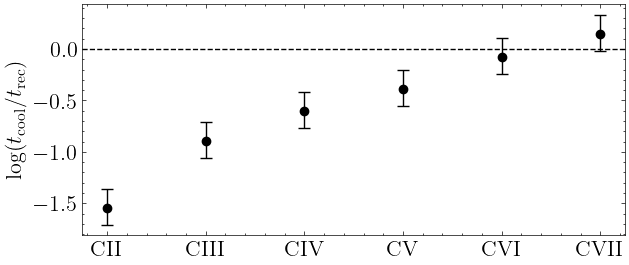

In [51]:
fig, ax = plt.subplots(1, figsize=(7,3))

for i in range(len(logt_cool_rec_carb)):
    ax.errorbar(i, logt_cool_rec_carb[C_list[i]], yerr=[[dlogt_cool_rec_lo_carb[C_list[i]]],[dlogt_cool_rec_hi_carb[C_list[i]]]], linestyle='None', marker='o', capsize=4, color='black')
    
ax.set_xticks([0,1,2,3,4,5], ['CII', 'CIII', 'CIV', 'CV', 'CVI', 'CVII'], minor=False)
ax.set_ylabel(r'$\log(t_\mathrm{cool}/t_\mathrm{rec})$')
ax.axhline(0, linestyle='--')

Text(0, 0.5, '$\\log(t_\\mathrm{rec}/\\mathrm{Myr})$')

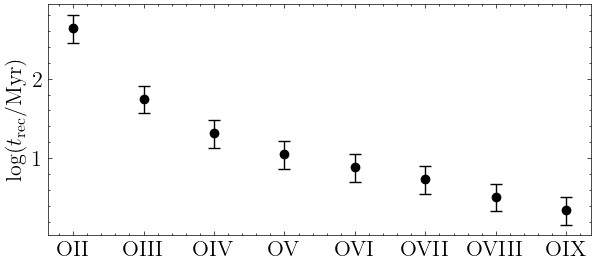

In [52]:
fig, ax = plt.subplots(1, figsize=(7,3))

for i in range(len(logt_rec_oxy)):
    ax.errorbar(i, logt_rec_oxy[O_list[i]], yerr=[[dlogt_rec_lo_oxy[O_list[i]]],[dlogt_rec_hi_oxy[O_list[i]]]], linestyle='None', marker='o', capsize=4, color='black')
    
ax.set_xticks([0,1,2,3,4,5,6,7], ['OII', 'OIII', 'OIV', 'OV', 'OVI', 'OVII', 'OVIII', 'OIX'])
ax.set_ylabel(r'$\log(t_\mathrm{rec}/\mathrm{Myr})$')

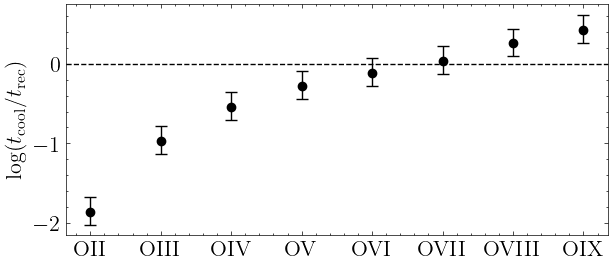

In [53]:
fig, ax = plt.subplots(1, figsize=(7,3))

for i in range(len(logt_cool_rec_oxy)):
    ax.errorbar(i, logt_cool_rec_oxy[O_list[i]], yerr=[[dlogt_cool_rec_lo_oxy[O_list[i]]],[dlogt_cool_rec_hi_oxy[O_list[i]]]], linestyle='None', marker='o', capsize=4, color='black')
    
ax.set_xticks([0,1,2,3,4,5,6,7], ['OII', 'OIII', 'OIV', 'OV', 'OVI', 'OVII', 'OVIII', 'OIX'])
ax.set_ylabel(r'$\log(t_\mathrm{cool}/t_\mathrm{rec})$')
ax.axhline(0, linestyle='--')

In [163]:
get_quantiles(z_126_c1_PIE_logT), np.percentile(z_126_c1_PIE_logT, 100*cdf_3sig)

3.93 -0.17 0.07


(None, 4.11382769397835)

(array([ 1014.,  5553., 11035., 31809., 20296.,  6335.,  2821.,   846.,
          251.,    40.]),
 array([0.50511433, 0.58942583, 0.67373732, 0.75804882, 0.84236032,
        0.92667182, 1.01098331, 1.09529481, 1.17960631, 1.26391781,
        1.3482293 ]),
 <BarContainer object of 10 artists>)

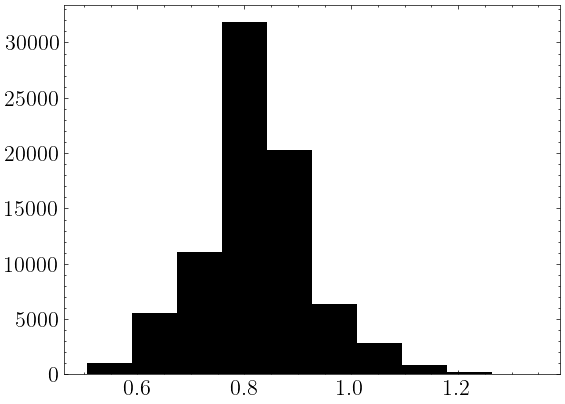

In [164]:
plt.hist(z_126_c1_PIE_logt_rec)

In [166]:
get_quantiles(z_126_c1_PIE_logt_rec)

0.83 -0.1 0.08


(array([ 1165.,  5122.,  8903., 20207., 27746.,  9862.,  4394.,  1912.,
          588.,   101.]),
 array([-0.22642264, -0.12950778, -0.03259292,  0.06432194,  0.16123679,
         0.25815165,  0.35506651,  0.45198137,  0.54889623,  0.64581109,
         0.74272594]),
 <BarContainer object of 10 artists>)

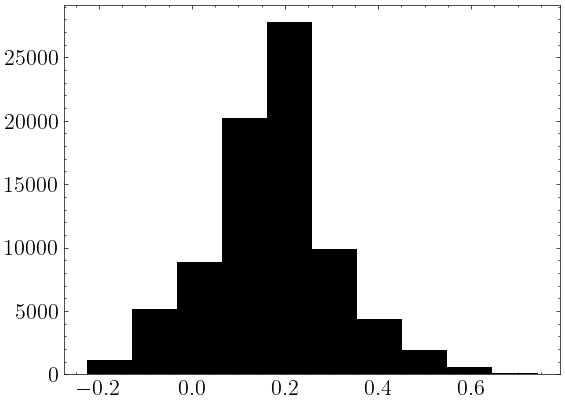

In [167]:
plt.hist(z_126_c1_PIE_logt_cool-z_126_c1_PIE_logt_rec)

In [168]:
get_quantiles(z_126_c1_PIE_logt_cool-z_126_c1_PIE_logt_rec)

0.17 -0.13 0.11


# z=1.27, PIE

## c1

In [169]:
z_127_c1_PIE_samples = pd.read_csv(loaddir+'z=1.27767328/cloudy_fits/one_phase_c1.csv')

In [170]:
z_127_c1_PIE_logT, z_127_c1_PIE_logt_rec, z_127_c1_PIE_logt_cool = get_cooling_dist(z_127_c1_PIE_samples['log_hdens'],
                                                                                       z_127_c1_PIE_samples['log_metals'],
                                                                                       logq_rec_interp, logt_cool_interp)

(array([   99.,  1186.,  8757., 27240., 29815., 10535.,  1874.,   411.,
           45.,    38.]),
 array([4.3341916 , 4.3559475 , 4.37770339, 4.39945929, 4.42121519,
        4.44297108, 4.46472698, 4.48648288, 4.50823877, 4.52999467,
        4.55175056]),
 <BarContainer object of 10 artists>)

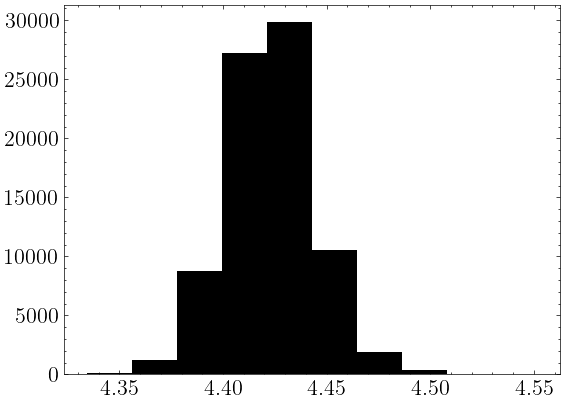

In [171]:
plt.hist(z_127_c1_PIE_logT)

In [172]:
get_quantiles(z_127_c1_PIE_logT)

4.42 -0.02 0.02


(array([   74.,  1724., 10538., 25382., 25510., 12267.,  3562.,   799.,
          104.,    40.]),
 array([1.8118705 , 1.90240028, 1.99293006, 2.08345984, 2.17398961,
        2.26451939, 2.35504917, 2.44557895, 2.53610872, 2.6266385 ,
        2.71716828]),
 <BarContainer object of 10 artists>)

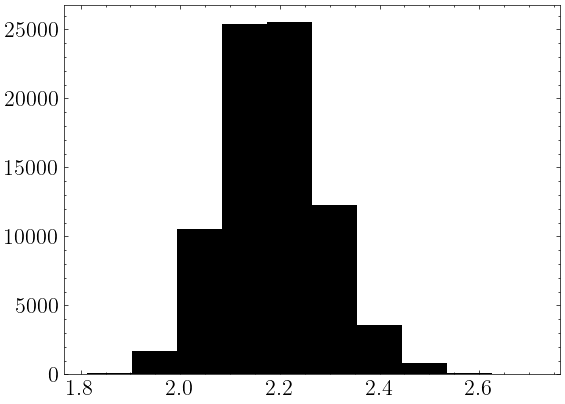

In [173]:
plt.hist(z_127_c1_PIE_logt_rec)

In [174]:
get_quantiles(z_127_c1_PIE_logt_rec)

2.18 -0.1 0.1


(array([3.0000e+00, 2.9000e+01, 2.2000e+01, 1.0900e+02, 3.9300e+02,
        2.3810e+03, 1.1188e+04, 3.4026e+04, 3.0009e+04, 1.8400e+03]),
 array([0.48866391, 0.53124347, 0.57382304, 0.61640261, 0.65898218,
        0.70156175, 0.74414132, 0.78672089, 0.82930046, 0.87188003,
        0.9144596 ]),
 <BarContainer object of 10 artists>)

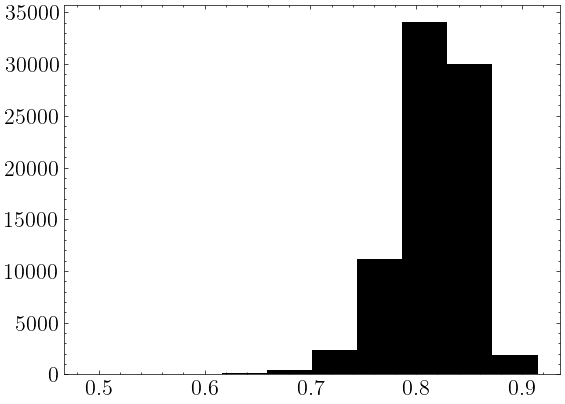

In [175]:
plt.hist(z_127_c1_PIE_logt_cool-z_127_c1_PIE_logt_rec)

In [176]:
get_quantiles(z_127_c1_PIE_logt_cool-z_127_c1_PIE_logt_rec)

0.82 -0.04 0.03


## c2

In [177]:
z_127_c2_PIE_samples = pd.read_csv(loaddir+'z=1.27767328/cloudy_fits/one_phase_c2.csv')

In [178]:
z_127_c2_PIE_logT, z_127_c2_PIE_logt_rec, z_127_c2_PIE_logt_cool = get_cooling_dist(z_127_c2_PIE_samples['log_hdens'],
                                                                                    z_127_c2_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([1.1000e+01, 5.1000e+01, 4.8200e+02, 2.6740e+03, 1.1571e+04,
        2.4422e+04, 2.5126e+04, 1.2856e+04, 2.6800e+03, 1.2700e+02]),
 array([4.30680889, 4.32322423, 4.33963957, 4.35605491, 4.37247026,
        4.3888856 , 4.40530094, 4.42171628, 4.43813162, 4.45454697,
        4.47096231]),
 <BarContainer object of 10 artists>)

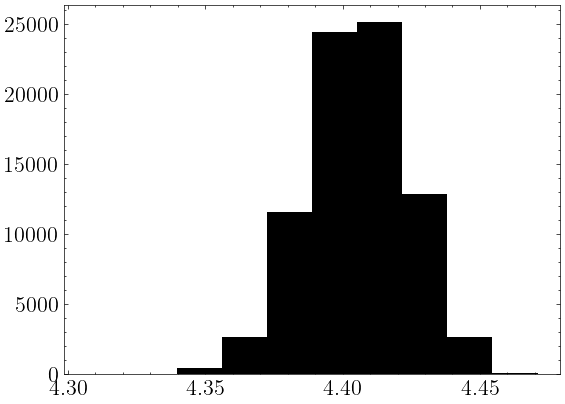

In [179]:
plt.hist(z_127_c2_PIE_logT)

In [180]:
get_quantiles(z_127_c2_PIE_logT)

4.41 -0.02 0.02


(array([   51.,   538.,  2993., 10873., 22667., 24219., 14010.,  4106.,
          508.,    35.]),
 array([1.67721757, 1.73465148, 1.7920854 , 1.84951931, 1.90695322,
        1.96438713, 2.02182104, 2.07925495, 2.13668887, 2.19412278,
        2.25155669]),
 <BarContainer object of 10 artists>)

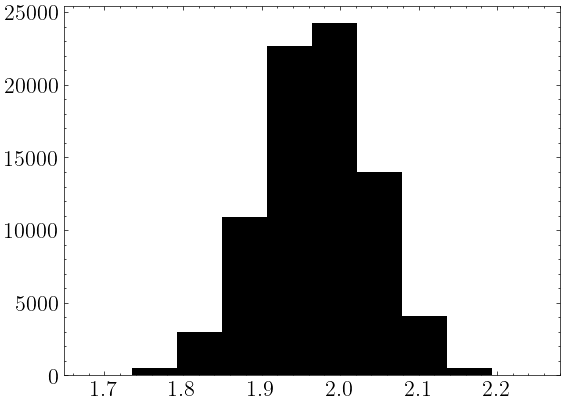

In [181]:
plt.hist(z_127_c2_PIE_logt_rec)

In [182]:
get_quantiles(z_127_c2_PIE_logt_rec)

1.97 -0.07 0.07


(array([7.0000e+00, 1.3200e+02, 1.1440e+03, 6.3350e+03, 1.7511e+04,
        2.5676e+04, 1.9581e+04, 8.2350e+03, 1.3180e+03, 6.1000e+01]),
 array([0.81311659, 0.83003843, 0.84696026, 0.8638821 , 0.88080394,
        0.89772577, 0.91464761, 0.93156945, 0.94849128, 0.96541312,
        0.98233496]),
 <BarContainer object of 10 artists>)

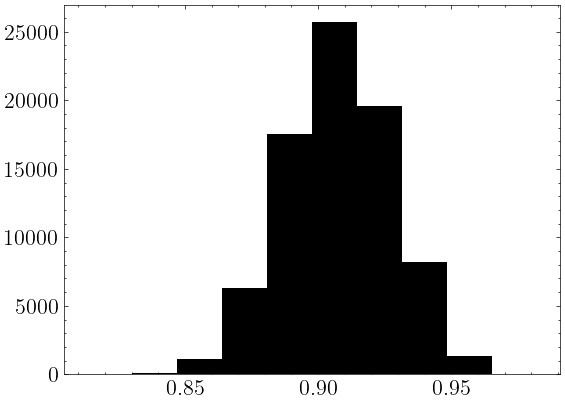

In [183]:
plt.hist(z_127_c2_PIE_logt_cool-z_127_c2_PIE_logt_rec)

In [184]:
get_quantiles(z_127_c2_PIE_logt_cool-z_127_c2_PIE_logt_rec)

0.91 -0.02 0.02


# Summary plot

In [125]:
def plot_str(ax, s_x, s_y, dx_lim, dy_lim, m, c, mfc, a, c_dx, c_dy):
    
    '''
    Function to plot string
    
    ax: axis
    s_x, s_y: string for x, y
    dx_lim, dy_lim: arrow width for upper limit in x, y
    m: marker type
    c: marker color
    mfc: marker face color (can be empty)
    a: transparency
    c_dx, c_dy: scaling for bar connecting spear to marker (for upper limits)
    '''
    
    x_uplim = s_x[0]=='<'
    y_uplim = s_y[0]=='<'
    
    x_lolim = s_x[0]=='>'
    y_lolim = s_y[0]=='>'
    
    # Handle x
    # Limits
    if x_uplim or x_lolim:
        x = float(s_x[1:])
        dx = dx_lim
    # Detection
    else:
        s_x_split = s_x.split(',')
        x = float(s_x_split[0])
        dx_lo = -float(s_x_split[1]) # Take care of the negative sign
        dx_hi = float(s_x_split[2])
        
    # Handle y
    if y_uplim or y_lolim:
        y = float(s_y[1:])
        dy = dy_lim
    # Detection
    else:
        s_y_split = s_y.split(',')
        y = float(s_y_split[0])
        dy_lo = -float(s_y_split[1]) # Take care of the negative sign
        dy_hi = float(s_y_split[2])
        
    # Plot
    # x uplim
    if x_uplim:
        
        # y uplim
        if y_uplim:
            # Make marker and spears
            (_, caps, _) = ax.errorbar(x, y, xerr=dx, yerr=dy, marker=m, xuplims=True, uplims=True,
                       linestyle='none', capsize=4, color=c, markerfacecolor=mfc, alpha=a, elinewidth=0)      
            caps[0].set_fillstyle('none')
            caps[2].set_fillstyle('none')
            # Make connections
            ax.errorbar(x, y, xerr=[[c_dx*dx],[0]], yerr=[[c_dy*dy],[0]], markersize=0,alpha=a,
                       linestyle='none', capsize=0, color=c) 
            
        # y lolim
        elif y_lolim:
            # Make marker and spears
            (_, caps, _) = ax.errorbar(x, y, xerr=dx, yerr=dy, marker=m, xuplims=True, lolims=True,
                       linestyle='none', capsize=4, color=c, markerfacecolor=mfc, alpha=a, elinewidth=0)      
            caps[0].set_fillstyle('none')
            caps[2].set_fillstyle('none')
            # Make connections
            ax.errorbar(x, y, xerr=[[c_dx*dx],[0]], yerr=[[0],[c_dy*dy]], markersize=0,alpha=a,
                       linestyle='none', capsize=0, color=c) 
            
        # y det
        else:
            # Make marker and spear
            (_, caps, _) = ax.errorbar(x, y, xerr=dx, yerr=[[dy_lo],[dy_hi]], marker=m, xuplims=True,
                       linestyle='none', capsize=4, color=c, markerfacecolor=mfc, alpha=a, elinewidth=0)                                       
            caps[0].set_fillstyle('none')
            # Make connection
            ax.errorbar(x, y, xerr=[[c_dx*dx],[0]], yerr=[[dy_lo],[dy_hi]], markersize=0,alpha=a,
                       linestyle='none', capsize=0, color=c)  
        
    # x lolim
    elif x_lolim:
        
        # y uplim
        if y_uplim:
            # Make marker and spears
            (_, caps, _) = ax.errorbar(x, y, xerr=dx, yerr=dy, marker=m, xlolims=True, uplims=True,
                       linestyle='none', capsize=4, color=c, markerfacecolor=mfc, alpha=a, elinewidth=0)      
            caps[0].set_fillstyle('none')
            caps[2].set_fillstyle('none')
            # Make connections
            ax.errorbar(x, y, xerr=[[0],[c_dx*dx]], yerr=[[c_dy*dy],[0]], markersize=0,alpha=a,
                       linestyle='none', capsize=0, color=c) 
            
        # y lolim
        elif y_lolim:
            # Make marker and spears
            (_, caps, _) = ax.errorbar(x, y, xerr=dx, yerr=dy, marker=m, xlolims=True, lolims=True,
                       linestyle='none', capsize=4, color=c, markerfacecolor=mfc, alpha=a, elinewidth=0)      
            caps[0].set_fillstyle('none')
            caps[2].set_fillstyle('none')
            # Make connections
            ax.errorbar(x, y, xerr=[[0],[c_dx*dx]], yerr=[[0],[c_dy*dy]], markersize=0,alpha=a,
                       linestyle='none', capsize=0, color=c) 
            
        # y det
        else:
            # Make marker and spear
            (_, caps, _) = ax.errorbar(x, y, xerr=dx, yerr=[[dy_lo],[dy_hi]], marker=m, xlolims=True,
                       linestyle='none', capsize=4, color=c, markerfacecolor=mfc, alpha=a, elinewidth=0)                                       
            caps[0].set_fillstyle('none')
            # Make connection
            ax.errorbar(x, y, xerr=[[0],[c_dx*dx]], yerr=[[dy_lo],[dy_hi]], markersize=0,alpha=a,
                       linestyle='none', capsize=0, color=c)  
        
    # x det
    else:
        
        # y uplim
        if y_uplim:
            # Make marker and spear
            (_, caps, _) = ax.errorbar(x, y, xerr=[[dx_lo],[dx_hi]], yerr=dy, marker=m, uplims=True,
                       linestyle='none', capsize=4, color=c, markerfacecolor=mfc, alpha=a, elinewidth=0)     
            caps[2].set_fillstyle('none')
            # Make connection
            ax.errorbar(x, y, xerr=[[dx_lo],[dx_hi]], yerr=[[c_dy*dy],[0]], markersize=0,alpha=a,
                       linestyle='none', capsize=0, color=c)    
            
        # y lolim
        elif y_lolim:
            # Make marker and spear
            (_, caps, _) = ax.errorbar(x, y, xerr=[[dx_lo],[dx_hi]], yerr=dy, marker=m, lolims=True,
                       linestyle='none', capsize=4, color=c, markerfacecolor=mfc, alpha=a, elinewidth=0)     
            caps[2].set_fillstyle('none')
            # Make connection
            ax.errorbar(x, y, xerr=[[dx_lo],[dx_hi]], yerr=[[0],[c_dy*dy]], markersize=0,alpha=a,
                       linestyle='none', capsize=0, color=c)    
            
        # y det
        else:    
            ax.errorbar(x, y, xerr=[[dx_lo],[dx_hi]], yerr=[[dy_lo],[dy_hi]], marker=m,
                       linestyle='none', capsize=4, color=c, markerfacecolor=mfc, alpha=a)    

In [126]:
log_metals_arr = ['-0.85, -0.06, +0.06',
                '-0.1, -0.1, +0.1',
                '0.3, -0.1, +0.1',
                '-0.4, -0.2, +0.1',
                '-0.6, -0.1, +0.1',
                '0.0, -0.2, +0.1',
                '-1.7, -0.1, +0.2',
                '-1.85, -0.05, +0.05',
                '-0.78, -0.04, +0.04',
                '0.6, -0.1, +0.2',
                '-0.26, -0.06, +0.06',
                '-0.44, -0.05, +0.05',]


log_tctr = ['1.00, -0.01, +0.01',
            '0.73, -0.08, +0.05',
            '0.4, -0.1, +0.1',
            '0.89, -0.05, +0.05',
            '0.94, -0.03, +0.03',
            '0.71, -0.09, +0.09',
            '1.12, -0.01, +0.01',
            '1.21, -0.04, +0.04',
            '1.05, -0.01, +0.01',
            '0.2, -0.1, +0.1',
            '0.82, -0.04, +0.03',
            '0.91, -0.02, +0.02',]

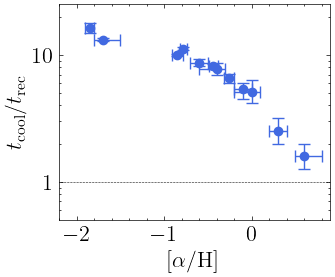

In [127]:
fig, ax = plt.subplots(1, figsize=(3.5,2.8), sharex=True, sharey=True)


for i in range(len(log_metals_arr)):
    plot_str(ax, log_metals_arr[i], log_tctr[i], .1, .08, 'o', 'royalblue', 'royalblue', 1, 1.8, 1.8)


# Phases without metallicity constraints

# z=0.67, c1L
#corner.hist2d(np.array(z_067_c1_PIE_samples['log_metals_p2']), 
#              np.array(z_067_c1L_PIE_logt_cool-z_067_c1L_PIE_logt_rec), 
#              bins=30,  plot_datapoints=False, smooth=True,
#              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.5, 'linestyles':'dotted'})

# z=1.04, c1L
#corner.hist2d(np.array(z_104_c1_PIE_samples['log_metals_p2']), 
#              np.array(z_104_c1L_PIE_logt_cool-z_104_c1L_PIE_logt_rec), 
#              bins=30,  plot_datapoints=False, smooth=True,
#              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.5, 'linestyles':'dotted'})

# z=1.04, c1L
#corner.hist2d(np.array(z_104_c3_PIE_samples['log_metals_p2']), 
#              np.array(z_104_c3L_PIE_logt_cool-z_104_c3L_PIE_logt_rec), 
#              bins=30,  plot_datapoints=False, smooth=True,
#              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.5, 'linestyles':'dotted'})


# z=1.09, c1L
#corner.hist2d(np.array(z_109_c1_PIE_samples['log_metals_p2']), 
#              np.array(z_109_c1L_PIE_logt_cool-z_109_c1L_PIE_logt_rec), 
#              bins=30,  plot_datapoints=False, smooth=True,
#              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.5, 'linestyles':'dotted'})

ax.axhline(0, linestyle=':', lw=.4)
ax.axhline(0, linestyle=':', lw=.4)


ax.set_xlabel(r'$\mathrm{[\alpha/H]}$')
ax.set_ylabel(r'$t_\mathrm{cool}/t_\mathrm{rec}$')

x = []

for i in [1e-2, 1e-1, 1e0, 1e1, 1e2]:
    for j in range(1,10):
        x.append(i*j)
        
ax.set_yticks(np.log10(x), minor=True)
ax.set_yticks([-1,0,1], labels=[r'$0.1$', r'$1$', r'$10$'])

ax.set_xlim(-2.2,.9)
ax.set_ylim(-0.3,1.4)

plt.savefig(rootdir+'Figures/metals_cool.pdf', dpi=300)
plt.savefig(rootdir+'Figures/metals_cool.png', dpi=300)

(-0.3, 1.7)

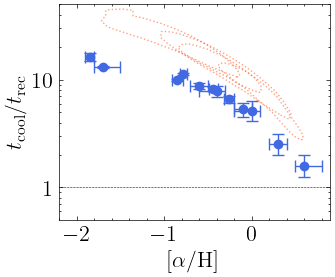

In [129]:
fig, ax = plt.subplots(1, figsize=(3.5,2.8), sharex=True, sharey=True)


for i in range(len(log_metals_arr)):
    plot_str(ax, log_metals_arr[i], log_tctr[i], .1, .08, 'o', 'royalblue', 'royalblue', 1, 1.8, 1.8)


# Phases without metallicity constraints

# z=0.67, c1L
corner.hist2d(np.array(z_067_c1_PIE_samples['log_metals_p2']), 
              np.array(z_067_c1L_PIE_logt_cool-z_067_c1L_PIE_logt_OVI_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.5, 'linestyles':'dotted'})

# z=1.04, c1L
corner.hist2d(np.array(z_104_c1_PIE_samples['log_metals_p2']), 
              np.array(z_104_c1L_PIE_logt_cool-z_104_c1L_PIE_logt_OVI_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.5, 'linestyles':'dotted'})

# z=1.04, c1L
corner.hist2d(np.array(z_104_c3_PIE_samples['log_metals_p2']), 
              np.array(z_104_c3L_PIE_logt_cool-z_104_c3L_PIE_logt_OVI_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.5, 'linestyles':'dotted'})


# z=1.09, c1L
corner.hist2d(np.array(z_109_c1_PIE_samples['log_metals_p2']), 
              np.array(z_109_c1L_PIE_logt_cool-z_109_c1L_PIE_logt_OVI_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.5, 'linestyles':'dotted'})

ax.axhline(0, linestyle=':', lw=.4)
ax.axhline(0, linestyle=':', lw=.4)


ax.set_xlabel(r'$\mathrm{[\alpha/H]}$')
ax.set_ylabel(r'$t_\mathrm{cool}/t_\mathrm{rec}$')

x = []

for i in [1e-2, 1e-1, 1e0, 1e1, 1e2]:
    for j in range(1,10):
        x.append(i*j)
        
ax.set_yticks(np.log10(x), minor=True)
ax.set_yticks([-1,0,1], labels=[r'$0.1$', r'$1$', r'$10$'])

ax.set_xlim(-2.2,.9)
ax.set_ylim(-0.3,1.7)

#plt.savefig(rootdir+'Figures/metals_cool.pdf', dpi=300)
#plt.savefig(rootdir+'Figures/metals_cool.png', dpi=300)

(-0.3, 1.7)

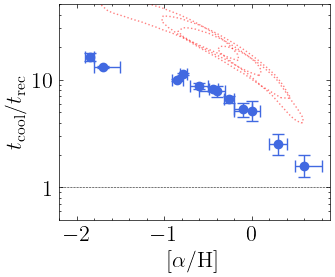

In [131]:
fig, ax = plt.subplots(1, figsize=(3.5,2.8), sharex=True, sharey=True)


for i in range(len(log_metals_arr)):
    plot_str(ax, log_metals_arr[i], log_tctr[i], .1, .08, 'o', 'royalblue', 'royalblue', 1, 1.8, 1.8)


# Phases without metallicity constraints

# z=0.67, c1L
corner.hist2d(np.array(z_067_c1_PIE_samples['log_metals_p2']), 
              np.array(z_067_c1L_PIE_logt_cool-z_067_c1L_PIE_logt_OVII_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='red', contour_kwargs={'alpha':.5, 'linestyles':'dotted'})

# z=1.04, c1L
corner.hist2d(np.array(z_104_c1_PIE_samples['log_metals_p2']), 
              np.array(z_104_c1L_PIE_logt_cool-z_104_c1L_PIE_logt_OVII_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='red', contour_kwargs={'alpha':.5, 'linestyles':'dotted'})

# z=1.04, c1L
corner.hist2d(np.array(z_104_c3_PIE_samples['log_metals_p2']), 
              np.array(z_104_c3L_PIE_logt_cool-z_104_c3L_PIE_logt_OVII_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='red', contour_kwargs={'alpha':.5, 'linestyles':'dotted'})


# z=1.09, c1L
corner.hist2d(np.array(z_109_c1_PIE_samples['log_metals_p2']), 
              np.array(z_109_c1L_PIE_logt_cool-z_109_c1L_PIE_logt_OVII_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='red', contour_kwargs={'alpha':.5, 'linestyles':'dotted'})

ax.axhline(0, linestyle=':', lw=.4)
ax.axhline(0, linestyle=':', lw=.4)


ax.set_xlabel(r'$\mathrm{[\alpha/H]}$')
ax.set_ylabel(r'$t_\mathrm{cool}/t_\mathrm{rec}$')

x = []

for i in [1e-2, 1e-1, 1e0, 1e1, 1e2]:
    for j in range(1,10):
        x.append(i*j)
        
ax.set_yticks(np.log10(x), minor=True)
ax.set_yticks([-1,0,1], labels=[r'$0.1$', r'$1$', r'$10$'])

ax.set_xlim(-2.2,.9)
ax.set_ylim(-0.3,1.7)

#plt.savefig(rootdir+'Figures/metals_cool.pdf', dpi=300)
#plt.savefig(rootdir+'Figures/metals_cool.png', dpi=300)

In [229]:
1-np.exp(-.5)

0.3934693402873666

(-0.5, 1.15)

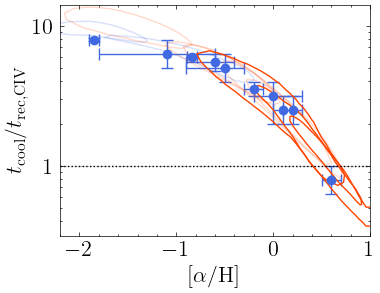

In [262]:
fig, ax = plt.subplots(1, figsize=(4,3))


for i in range(len(log_metals_arr)):
    if log_metals_arr[i][0]!='<':
        #m = float(log_metals_arr[i].split(',')[0])
        #if m == 0.6:
        #    a=1
        #else:
        #    a=.4
        plot_str(ax, log_metals_arr[i], log_tctr[i], .1, .08, 'o', 'royalblue', 'royalblue', 1, 1.8, 1.8)


# Phases without metallicity constraints

# z=0.67, c3L
corner.hist2d(np.array(z_067_c1_PIE_samples['log_metals_p2']), 
              np.array(z_067_c1L_PIE_logt_cool-z_067_c1L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.2})

# z=1.04, c3L
corner.hist2d(np.array(z_104_c3_PIE_samples['log_metals_p2']), 
              np.array(z_104_c3L_PIE_logt_cool-z_104_c3L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered')

# z=1.04, c4L
corner.hist2d(np.array(z_104_c4_PIE_samples['log_metals_p2']), 
              np.array(z_104_c4L_PIE_logt_cool-z_104_c4L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.2})


# z=1.09, c1L
corner.hist2d(np.array(z_109_c1_PIE_samples['log_metals_p2']), 
              np.array(z_109_c1L_PIE_logt_cool-z_109_c1L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered')

# z=1.16, c2H
corner.hist2d(np.array(z_116_c2_PIE_samples['log_metals_p1']), 
              np.array(z_116_c2H_PIE_logt_cool-z_116_c2H_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='royalblue', contour_kwargs={'alpha':.2})

# z=1.16, c2L
corner.hist2d(np.array(z_116_c2_PIE_samples['log_metals_p2']), 
              np.array(z_116_c2L_PIE_logt_cool-z_116_c2L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.2})


# z=1.22, c1L
corner.hist2d(np.array(z_122_c1_PIE_samples['log_metals_p2']), 
              np.array(z_122_c1L_PIE_logt_cool-z_122_c1L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.2})

# z=1.27, c1L
corner.hist2d(np.array(z_127_c1_PIE_samples['log_metals_p2']), 
              np.array(z_127_c1L_PIE_logt_cool-z_127_c1L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered')


# z=1.27, c2H
corner.hist2d(np.array(z_127_c2_PIE_samples['log_metals_p1']), 
              np.array(z_127_c2H_PIE_logt_cool-z_127_c2H_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='royalblue', contour_kwargs={'alpha':.2})

# z=1.27, c2L
corner.hist2d(np.array(z_127_c2_PIE_samples['log_metals_p2']), 
              np.array(z_127_c2L_PIE_logt_cool-z_127_c2L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.2})

ax.axhline(0, linestyle=':', lw=.4)


ax.set_xlabel(r'$\mathrm{[\alpha/H]}$')
ax.set_ylabel(r'$t_\mathrm{cool}/t_\mathrm{rec,CIV}$')

x = []

for i in [1e-2, 1e-1, 1e0, 1e1, 1e2]:
    for j in range(1,10):
        x.append(i*j)
        
ax.set_yticks(np.log10(x), minor=True)
ax.set_yticks([-1,0,1], labels=[r'$0.1$', r'$1$', r'$10$'])

ax.axhline(0, linestyle=':')
ax.set_xlim(-2.2,1.)
ax.set_ylim(-0.5,1.15)
#plt.savefig(rootdir+'Figures/metals_cool.pdf', dpi=300)
#plt.savefig(rootdir+'Figures/metals_cool.png', dpi=300)

# Functions for TDP cooling

In [210]:
# TDP model grid points
log_metals_arr_TDP = [-2.6,-2.4,-2.2,-2.0,-1.8,-1.6,-1.4,-1.2,-1.0 ,-0.8,-0.6,-0.4,-0.2,0.0,0.2,0.4,0.6,0.8,1.0]
log_hdens_arr_TDP = [-4.8,-4.6,-4.4,-4.0,-3.8,-3.6,-3.4,-3.2,-3.0,-2.8,-2.6,-2.4,-2.2,-2.0,-1.8,-1.6]
logT_arr_TDP = np.arange(4.00, 6.01, 0.01)

Interpolate temperatures and cooling times

In [211]:
pkl_file = open(rootdir+'cloudy_grids/TDP_cool.pkl', 'rb')
log_cool_TDP_samples = pickle.load(pkl_file)
pkl_file.close()

In [212]:
log_cool_TDP_interp = RegularGridInterpolator((log_metals_arr_TDP, log_hdens_arr_TDP, logT_arr_TDP), log_cool_TDP_samples)

Functions to get TDP cooling times

In [213]:
def compute_tcool_TDP(log_metals, log_hdens, logT, log_cool_TDP_interp):
    
    Ctot = 10**log_cool_TDP_interp((log_metals, log_hdens, logT))
    
    # Equation from Gnat and Sternberg 2007
    t_cool = 4.34*1.5*(1.38*1e-16*10**logT)/(Ctot/10**log_hdens)
    
    return t_cool*t_Myr_sec

In [214]:
def get_cooling_dist_TDP(log_metals_samples, log_hdens_samples, logT_samples, logq_rec_interp, log_cool_TDP_interp):
    
    # Distribution of recombination times
    logt_rec_samples = logt_rec(log_hdens_samples, logT_samples, logq_rec_interp)
    
    # Distribution of cooling times
    logt_cool_samples = np.log10(compute_tcool_TDP(log_metals_samples, log_hdens_samples, logT_samples, log_cool_TDP_interp))
    
    return np.array(logt_rec_samples), np.array(logt_cool_samples)

# z=1.09

## c1

In [215]:
z_109_c1_TDP_samples = pd.read_csv(loaddir+'z=1.09456549/cloudy_fits/TDP.csv')

### c1H

In [216]:
z_109_c1H_TDP_logt_rec, z_109_c1H_TDP_logt_cool = get_cooling_dist_TDP(z_109_c1_TDP_samples['log_metals_p1'], 
                                                                   z_109_c1_TDP_samples['log_hdens_p1'],
                                                                   z_109_c1_TDP_samples['logT_p1'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([   22.,   245.,  1228.,  4345., 11531., 19078., 21430., 16383.,
         5351.,   387.]),
 array([0.67582763, 0.78217986, 0.88853209, 0.99488432, 1.10123655,
        1.20758878, 1.31394101, 1.42029324, 1.52664547, 1.6329977 ,
        1.73934994]),
 <BarContainer object of 10 artists>)

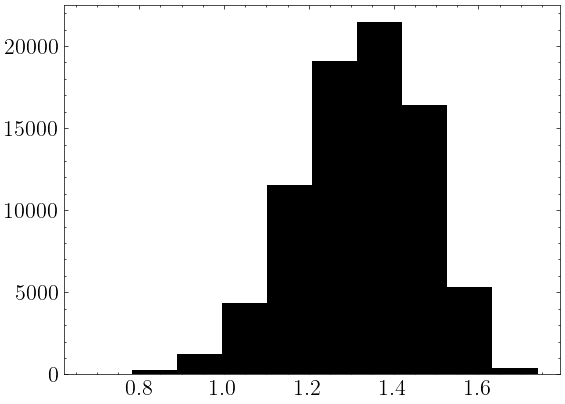

In [217]:
plt.hist(z_109_c1H_TDP_logt_rec)

In [218]:
get_quantiles(z_109_c1H_TDP_logt_rec)

1.33 -0.16 0.14


(array([3.4200e+02, 2.8600e+03, 1.0194e+04, 2.3137e+04, 3.3686e+04,
        9.3720e+03, 1.6900e+02, 1.7700e+02, 1.1000e+01, 5.2000e+01]),
 array([0.14323524, 0.30898562, 0.474736  , 0.64048638, 0.80623676,
        0.97198714, 1.13773753, 1.30348791, 1.46923829, 1.63498867,
        1.80073905]),
 <BarContainer object of 10 artists>)

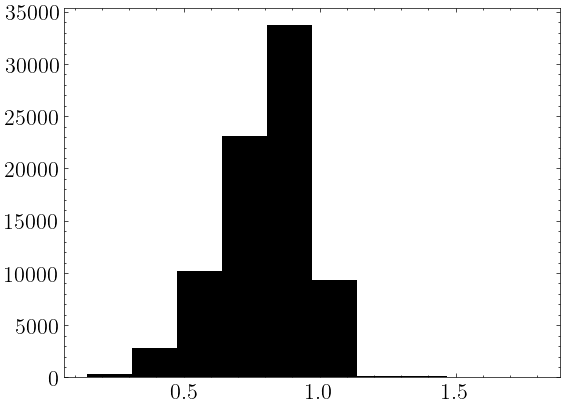

In [219]:
plt.hist(z_109_c1H_TDP_logt_cool-z_109_c1H_TDP_logt_rec)

In [220]:
get_quantiles(z_109_c1H_TDP_logt_cool-z_109_c1H_PIE_logt_rec)

1.28 -0.22 0.21


### c1L

In [221]:
z_109_c1L_TDP_logt_rec, z_109_c1L_TDP_logt_cool = get_cooling_dist_TDP(z_109_c1_TDP_samples['log_metals_p2'], 
                                                                   z_109_c1_TDP_samples['log_hdens_p2'],
                                                                   z_109_c1_TDP_samples['logT_p2'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([  132.,   717.,  2630.,  7701., 13688., 22084., 24514.,  7490.,
          936.,   108.]),
 array([1.55526992, 1.62813368, 1.70099745, 1.77386122, 1.84672499,
        1.91958876, 1.99245252, 2.06531629, 2.13818006, 2.21104383,
        2.2839076 ]),
 <BarContainer object of 10 artists>)

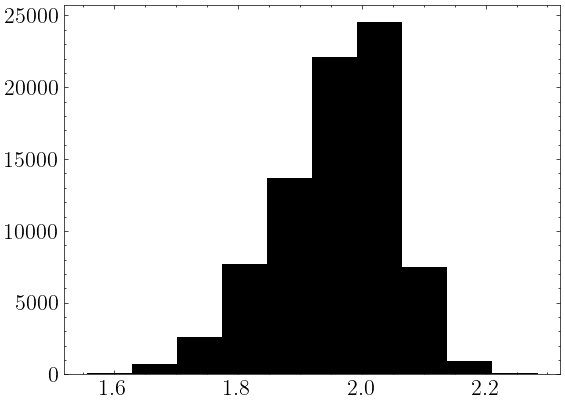

In [222]:
plt.hist(z_109_c1L_TDP_logt_rec)

In [223]:
get_quantiles(z_109_c1L_TDP_logt_rec)

1.97 -0.11 0.08


(array([  166.,  1530.,  5242., 10334., 15888., 20624., 13962.,  7823.,
         3724.,   707.]),
 array([-0.7268247 , -0.6028456 , -0.47886651, -0.35488741, -0.23090831,
        -0.10692921,  0.01704989,  0.14102899,  0.26500809,  0.38898719,
         0.51296629]),
 <BarContainer object of 10 artists>)

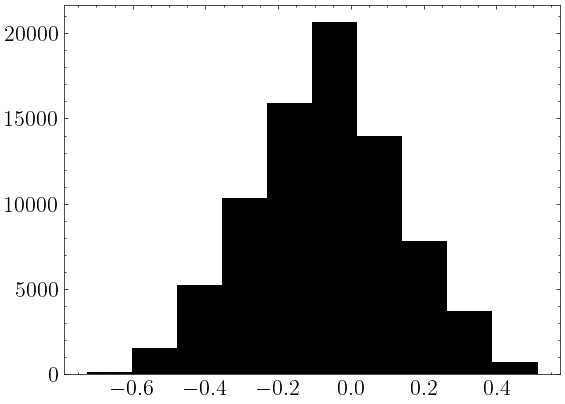

In [224]:
plt.hist(z_109_c1L_TDP_logt_cool-z_109_c1L_TDP_logt_rec)

In [225]:
get_quantiles(z_109_c1L_TDP_logt_cool-z_109_c1L_PIE_logt_rec)

0.32 -0.31 0.28


## c1

In [226]:
z_109_c1_PIE_TDP_samples = pd.read_csv(loaddir+'z=1.09456549/cloudy_fits/PIE+TDP.csv')

### c1H

In [227]:
z_109_c1H_PIE_logT, z_109_c1H_PIE_logt_rec, z_109_c1H_PIE_logt_cool = get_cooling_dist(z_109_c1_PIE_TDP_samples['log_hdens_p1'],
                                                                                       z_109_c1_PIE_TDP_samples['log_metals_p1'],
                                                                                       logq_rec_interp, logt_cool_interp)

(array([  765.,  2656.,  4560.,  8815., 14018., 18153., 17621., 10353.,
         2776.,   283.]),
 array([3.82426374, 3.88366883, 3.94307392, 4.00247902, 4.06188411,
        4.1212892 , 4.1806943 , 4.24009939, 4.29950448, 4.35890957,
        4.41831467]),
 <BarContainer object of 10 artists>)

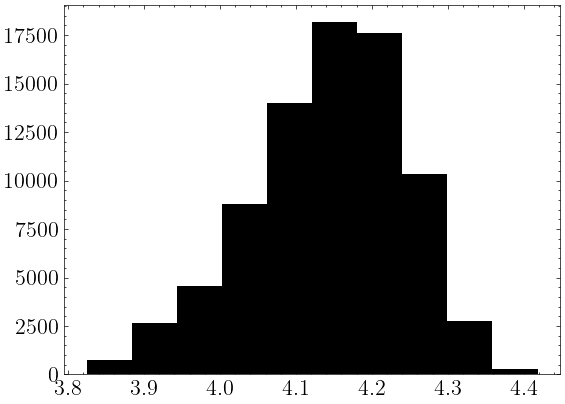

In [228]:
plt.hist(z_109_c1H_PIE_logT)

In [229]:
get_quantiles(z_109_c1H_PIE_logT)

4.15 -0.11 0.09


(array([6.4600e+02, 4.0460e+03, 1.1772e+04, 2.1731e+04, 2.4851e+04,
        1.1961e+04, 3.5950e+03, 1.1320e+03, 2.5300e+02, 1.3000e+01]),
 array([0.54408677, 0.63395802, 0.72382927, 0.81370052, 0.90357177,
        0.99344301, 1.08331426, 1.17318551, 1.26305676, 1.35292801,
        1.44279926]),
 <BarContainer object of 10 artists>)

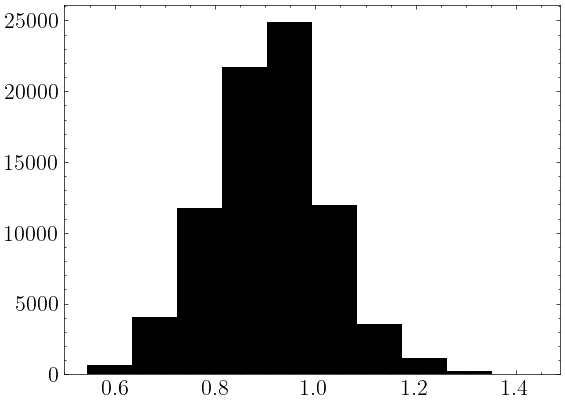

In [230]:
plt.hist(z_109_c1H_PIE_logt_rec)

In [231]:
get_quantiles(z_109_c1H_PIE_logt_rec)

0.91 -0.12 0.11


(array([  395.,  2032.,  3869.,  6475., 12404., 14528., 19397., 14985.,
         5395.,   520.]),
 array([0.23638819, 0.30011744, 0.36384669, 0.42757595, 0.4913052 ,
        0.55503445, 0.6187637 , 0.68249296, 0.74622221, 0.80995146,
        0.87368071]),
 <BarContainer object of 10 artists>)

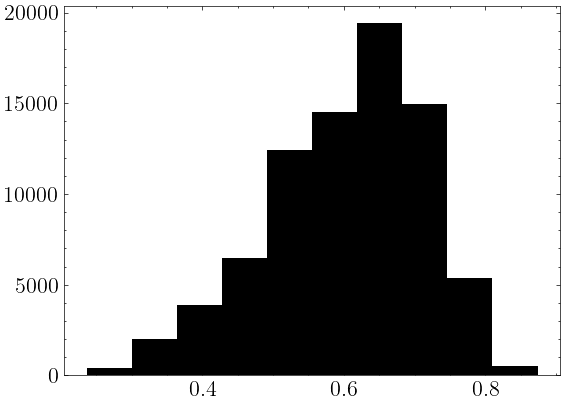

In [232]:
plt.hist(z_109_c1H_PIE_logt_cool-z_109_c1H_PIE_logt_rec)

In [233]:
get_quantiles(z_109_c1H_PIE_logt_cool-z_109_c1H_PIE_logt_rec)

0.62 -0.13 0.1


### c1L

In [234]:
z_109_c1L_TDP_logt_rec, z_109_c1L_TDP_logt_cool = get_cooling_dist_TDP(z_109_c1_PIE_TDP_samples['log_metals_p2'], 
                                                                   z_109_c1_PIE_TDP_samples['log_hdens_p2'],
                                                                   z_109_c1_PIE_TDP_samples['logT_p2'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([   44.,   548.,  3130.,  8966., 15738., 29753., 18095.,  3216.,
          471.,    39.]),
 array([1.44247396, 1.55629185, 1.67010974, 1.78392763, 1.89774552,
        2.01156341, 2.1253813 , 2.23919919, 2.35301708, 2.46683497,
        2.58065286]),
 <BarContainer object of 10 artists>)

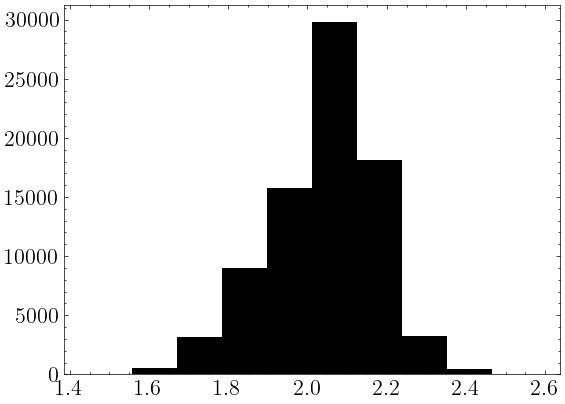

In [235]:
plt.hist(z_109_c1L_TDP_logt_rec)

In [236]:
get_quantiles(z_109_c1L_TDP_logt_rec)

2.06 -0.17 0.1


(array([  254.,  2106.,  7370., 13625., 17160., 19184., 13813.,  5299.,
         1083.,   106.]),
 array([-0.74529093, -0.599043  , -0.45279506, -0.30654713, -0.16029919,
        -0.01405126,  0.13219668,  0.27844461,  0.42469255,  0.57094048,
         0.71718842]),
 <BarContainer object of 10 artists>)

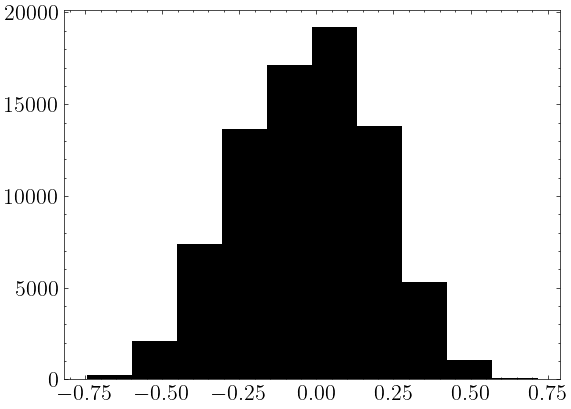

In [237]:
plt.hist(z_109_c1L_TDP_logt_cool-z_109_c1L_TDP_logt_rec)

In [238]:
get_quantiles(z_109_c1L_TDP_logt_cool-z_109_c1L_PIE_logt_rec)

0.46 -0.4 0.31


# z=1.26

## c1

In [239]:
z_126_c1_TDP_samples = pd.read_csv(loaddir+'z=1.25937492/cloudy_fits/TDP.csv')

In [240]:
z_126_c1_TDP_logt_rec, z_126_c1_TDP_logt_cool = get_cooling_dist_TDP(z_126_c1_TDP_samples['log_metals'], 
                                                                   z_126_c1_TDP_samples['log_hdens'],
                                                                   z_126_c1_TDP_samples['logT'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([1.7200e+03, 9.6940e+03, 1.7464e+04, 2.1047e+04, 1.6051e+04,
        9.4230e+03, 3.6780e+03, 7.8400e+02, 1.3300e+02, 6.0000e+00]),
 array([0.8296024 , 0.93958587, 1.04956934, 1.15955281, 1.26953628,
        1.37951975, 1.48950322, 1.59948669, 1.70947016, 1.81945363,
        1.9294371 ]),
 <BarContainer object of 10 artists>)

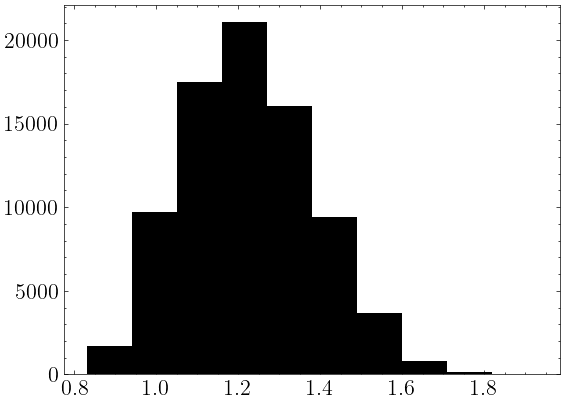

In [241]:
plt.hist(z_126_c1_TDP_logt_rec)

In [242]:
get_quantiles(z_126_c1_TDP_logt_rec)

1.22 -0.16 0.17


(array([6.7610e+03, 3.9808e+04, 2.7797e+04, 5.3240e+03, 3.0900e+02,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([-0.3809506 , -0.14841467,  0.08412126,  0.31665719,  0.54919312,
         0.78172905,  1.01426499,  1.24680092,  1.47933685,  1.71187278,
         1.94440871]),
 <BarContainer object of 10 artists>)

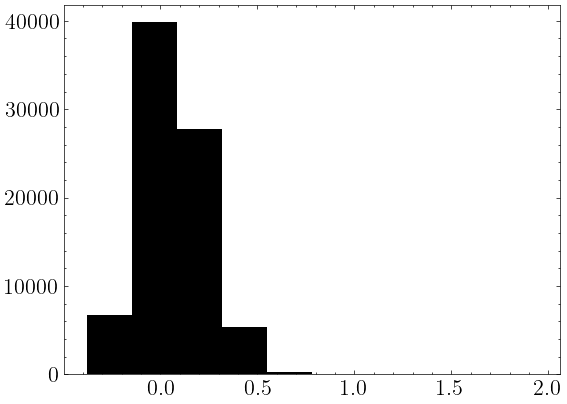

In [243]:
plt.hist(z_126_c1_TDP_logt_cool-z_126_c1_TDP_logt_rec)

In [244]:
get_quantiles(z_126_c1_TDP_logt_cool-z_126_c1_TDP_logt_rec)

0.05 -0.15 0.18


# z=1.27

## c1

In [245]:
z_127_c1_TDP_samples = pd.read_csv(loaddir+'z=1.27767328/cloudy_fits/TDP.csv')

### c1H

In [246]:
z_127_c1H_TDP_logt_rec, z_127_c1H_TDP_logt_cool = get_cooling_dist_TDP(z_127_c1_TDP_samples['log_metals_p1'], 
                                                                   z_127_c1_TDP_samples['log_hdens_p1'],
                                                                   z_127_c1_TDP_samples['logT_p1'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([  193.,   846.,  1233.,  1377.,  2289.,  6157., 24790., 32318.,
        10322.,   475.]),
 array([-5.62346104e-01, -2.80217881e-01,  1.91034177e-03,  2.84038564e-01,
         5.66166787e-01,  8.48295010e-01,  1.13042323e+00,  1.41255146e+00,
         1.69467968e+00,  1.97680790e+00,  2.25893612e+00]),
 <BarContainer object of 10 artists>)

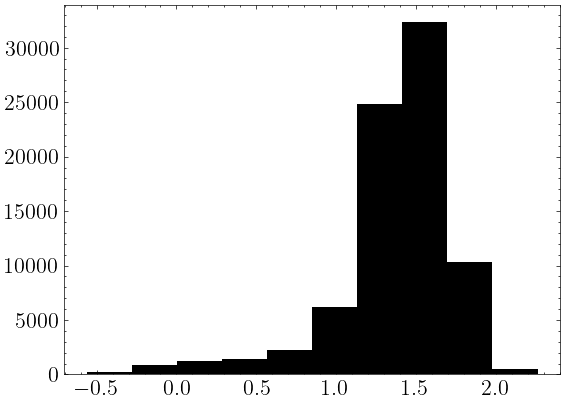

In [247]:
plt.hist(z_127_c1H_TDP_logt_rec)

In [248]:
get_quantiles(z_127_c1H_TDP_logt_rec)

1.44 -0.29 0.24


(array([3.7500e+02, 1.5151e+04, 4.2242e+04, 2.0287e+04, 1.5360e+03,
        1.3000e+02, 1.2400e+02, 1.3300e+02, 1.8000e+01, 4.0000e+00]),
 array([-0.23677611,  0.04836912,  0.33351434,  0.61865957,  0.90380479,
         1.18895002,  1.47409524,  1.75924047,  2.04438569,  2.32953092,
         2.61467615]),
 <BarContainer object of 10 artists>)

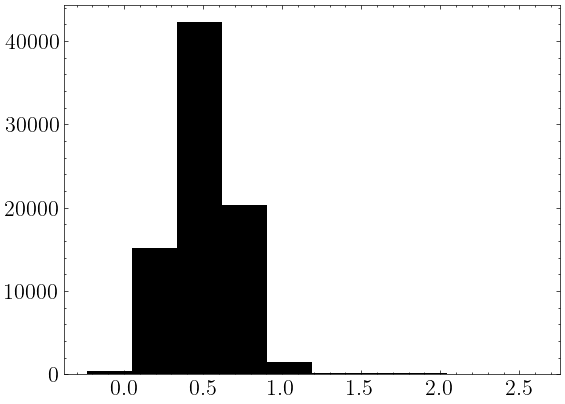

In [249]:
plt.hist(z_127_c1H_TDP_logt_cool-z_127_c1H_TDP_logt_rec)

In [250]:
get_quantiles(z_127_c1H_TDP_logt_cool-z_127_c1H_TDP_logt_rec)

0.46 -0.15 0.26


### c1L

In [251]:
z_127_c1L_TDP_logt_rec, z_127_c1L_TDP_logt_cool = get_cooling_dist_TDP(z_127_c1_TDP_samples['log_metals_p2'], 
                                                                   z_127_c1_TDP_samples['log_hdens_p2'],
                                                                   z_127_c1_TDP_samples['logT_p2'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([   89.,   134.,   244.,   695.,  3831., 14916., 34935., 21000.,
         3892.,   264.]),
 array([1.88817845, 1.99154961, 2.09492078, 2.19829195, 2.30166311,
        2.40503428, 2.50840544, 2.61177661, 2.71514777, 2.81851894,
        2.9218901 ]),
 <BarContainer object of 10 artists>)

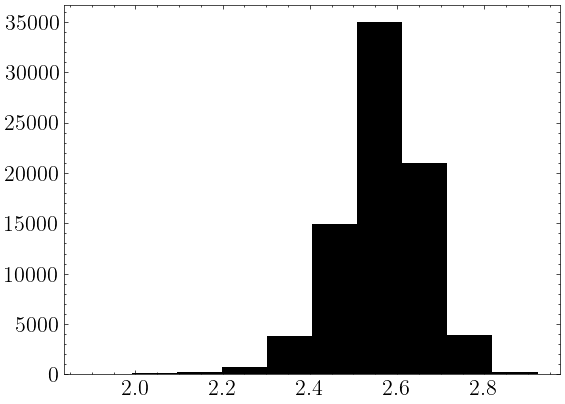

In [252]:
plt.hist(z_127_c1L_TDP_logt_rec)

In [253]:
get_quantiles(z_127_c1L_TDP_logt_rec)

2.57 -0.09 0.09


(array([ 2106., 13541., 23917., 21335., 11805.,  4760.,  1723.,   479.,
          208.,   126.]),
 array([-0.67225878, -0.54647461, -0.42069044, -0.29490627, -0.1691221 ,
        -0.04333793,  0.08244624,  0.20823042,  0.33401459,  0.45979876,
         0.58558293]),
 <BarContainer object of 10 artists>)

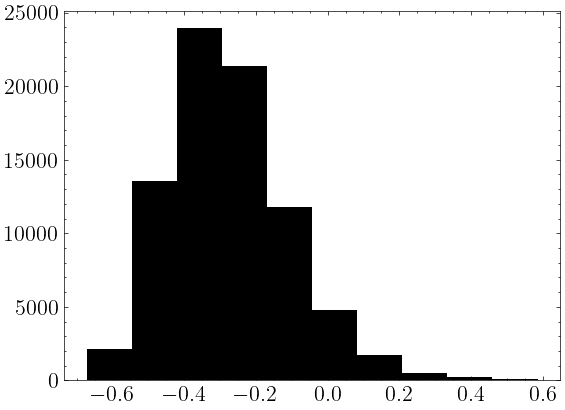

In [254]:
plt.hist(z_127_c1L_TDP_logt_cool-z_127_c1L_TDP_logt_rec)

In [255]:
get_quantiles(z_127_c1L_TDP_logt_cool-z_127_c1L_PIE_logt_rec)

0.08 -0.22 0.26


## c1

In [256]:
z_127_c1_PIE_TDP_samples = pd.read_csv(loaddir+'z=1.27767328/cloudy_fits/PIE+TDP.csv')

### c1H

In [257]:
z_127_c1H_PIE_logT, z_127_c1H_PIE_logt_rec, z_127_c1H_PIE_logt_cool = get_cooling_dist(z_127_c1_PIE_TDP_samples['log_hdens_p1'],
                                                                                       z_127_c1_PIE_TDP_samples['log_metals_p1'],
                                                                                       logq_rec_interp, logt_cool_interp)

(array([  949.,  5671.,  6068.,  8380., 13274., 25002., 14960.,  4034.,
         1458.,   204.]),
 array([3.69296248, 3.7808534 , 3.86874431, 3.95663522, 4.04452613,
        4.13241705, 4.22030796, 4.30819887, 4.39608978, 4.4839807 ,
        4.57187161]),
 <BarContainer object of 10 artists>)

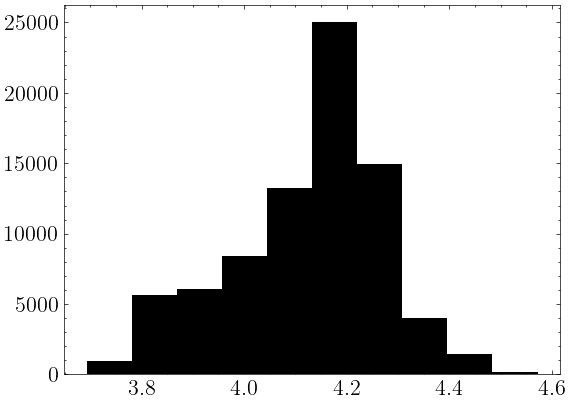

In [258]:
plt.hist(z_127_c1H_PIE_logT)

In [259]:
get_quantiles(z_127_c1H_PIE_logT)

4.16 -0.2 0.1


(array([  999.,  2235.,  4744.,  8638., 12277., 15852., 17465., 13830.,
         3559.,   401.]),
 array([-0.73971132, -0.46084361, -0.18197591,  0.0968918 ,  0.3757595 ,
         0.65462721,  0.93349491,  1.21236262,  1.49123033,  1.77009803,
         2.04896574]),
 <BarContainer object of 10 artists>)

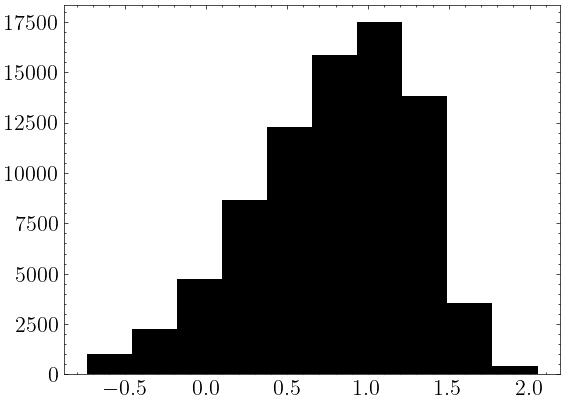

In [260]:
plt.hist(z_127_c1H_PIE_logt_rec)

In [261]:
get_quantiles(z_127_c1H_PIE_logt_rec)

0.86 -0.6 0.44


(array([  151.,   176.,   399.,   409.,  1311.,  3953., 20601., 37852.,
        13140.,  2008.]),
 array([-0.43270951, -0.28983693, -0.14696435, -0.00409177,  0.13878081,
         0.28165339,  0.42452597,  0.56739855,  0.71027113,  0.85314371,
         0.9960163 ]),
 <BarContainer object of 10 artists>)

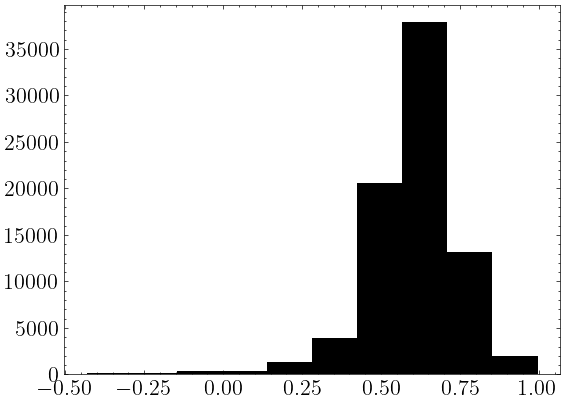

In [262]:
plt.hist(z_127_c1H_PIE_logt_cool-z_127_c1H_PIE_logt_rec)

In [263]:
get_quantiles(z_127_c1H_PIE_logt_cool-z_127_c1H_PIE_logt_rec)

0.62 -0.12 0.11


### c1L

In [264]:
z_127_c1L_TDP_logt_rec, z_127_c1L_TDP_logt_cool = get_cooling_dist_TDP(z_127_c1_PIE_TDP_samples['log_metals_p2'], 
                                                                   z_127_c1_PIE_TDP_samples['log_hdens_p2'],
                                                                   z_127_c1_PIE_TDP_samples['logT_p2'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([   91.,  2779.,  2993., 12185., 43088., 15892.,  1792.,   748.,
          141.,   291.]),
 array([1.96340323, 2.08740716, 2.21141108, 2.33541501, 2.45941894,
        2.58342286, 2.70742679, 2.83143071, 2.95543464, 3.07943857,
        3.20344249]),
 <BarContainer object of 10 artists>)

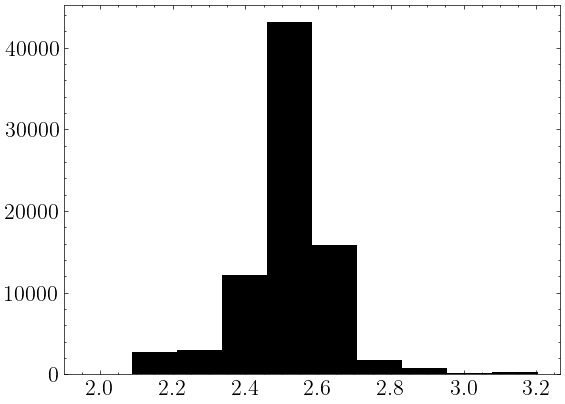

In [265]:
plt.hist(z_127_c1L_TDP_logt_rec)

In [266]:
get_quantiles(z_127_c1L_TDP_logt_rec)

2.53 -0.1 0.08


(array([ 5379., 20682., 18445., 14550., 10260.,  7122.,  2266.,   794.,
          418.,    84.]),
 array([-0.6700832 , -0.54083756, -0.41159191, -0.28234627, -0.15310063,
        -0.02385498,  0.10539066,  0.2346363 ,  0.36388195,  0.49312759,
         0.62237323]),
 <BarContainer object of 10 artists>)

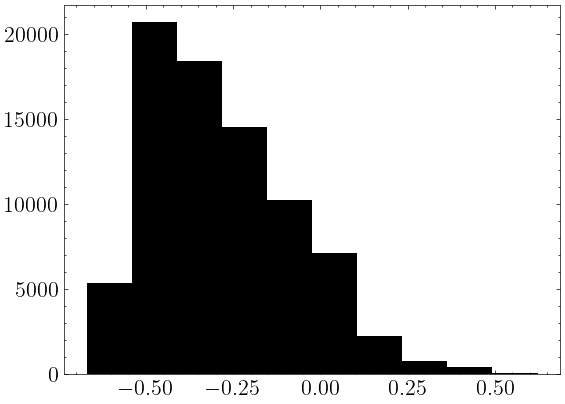

In [267]:
plt.hist(z_127_c1L_TDP_logt_cool-z_127_c1L_TDP_logt_rec)

In [268]:
get_quantiles(z_127_c1L_TDP_logt_cool-z_127_c1L_PIE_logt_rec)

0.01 -0.25 0.3


# DRAFT

# z=0.67

## c1

In [224]:
#z_067_c1_TDP_samples = pd.read_csv(loaddir+'z=0.67545705/cloudy_fits/TDP.csv')

### c1L

In [222]:
z_067_c1L_TDP_logt_rec, z_067_c1L_TDP_logt_cool = get_cooling_dist_TDP(z_067_c1_TDP_samples['log_metals_p1'], 
                                                                   z_067_c1_TDP_samples['log_hdens_p1'],
                                                                   z_067_c1_TDP_samples['logT_p1'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

NameError: name 'z_067_c1_TDP_samples' is not defined

(array([  233.,   596.,  2033.,  4992.,  8626., 11950., 19349., 23706.,
         8064.,   451.]),
 array([-0.40073044, -0.18844339,  0.02384366,  0.23613071,  0.44841776,
         0.66070481,  0.87299186,  1.08527891,  1.29756596,  1.509853  ,
         1.72214005]),
 <BarContainer object of 10 artists>)

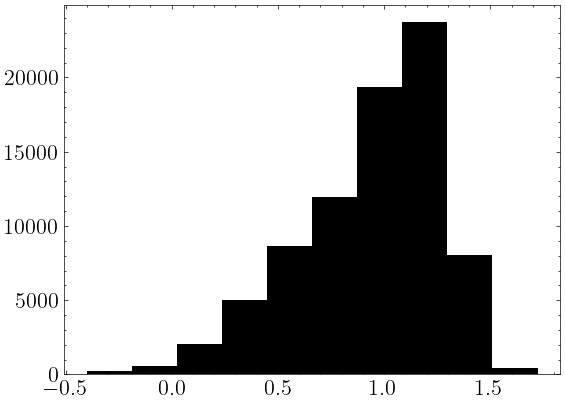

In [159]:
plt.hist(z_067_c1L_TDP_logt_rec)

In [160]:
get_quantiles(z_067_c1L_TDP_logt_rec)

1.01 -0.44 0.23


(array([9.6640e+03, 5.1838e+04, 1.7951e+04, 3.6900e+02, 7.8000e+01,
        3.3000e+01, 2.8000e+01, 3.8000e+01, 0.0000e+00, 1.0000e+00]),
 array([0.25529485, 0.52553135, 0.79576786, 1.06600436, 1.33624087,
        1.60647738, 1.87671388, 2.14695039, 2.41718689, 2.6874234 ,
        2.95765991]),
 <BarContainer object of 10 artists>)

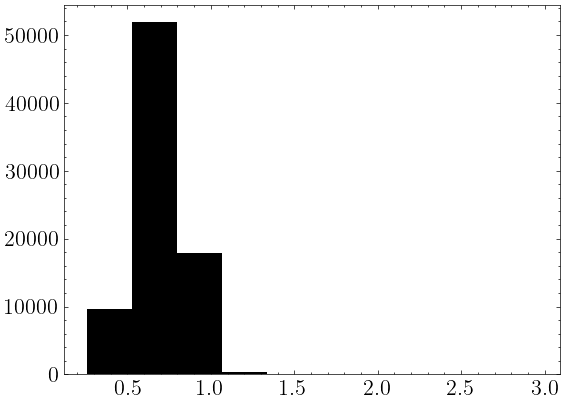

In [161]:
plt.hist(z_067_c1L_TDP_logt_cool-z_067_c1L_TDP_logt_rec)

In [162]:
get_quantiles(z_067_c1L_TDP_logt_cool-z_067_c1L_PIE_logt_rec)

0.9 -0.57 0.46


### c1H

In [163]:
z_067_c1H_TDP_logt_rec, z_067_c1H_TDP_logt_cool = get_cooling_dist_TDP(z_067_c1_TDP_samples['log_metals_p2'], 
                                                                   z_067_c1_TDP_samples['log_hdens_p2'],
                                                                   z_067_c1_TDP_samples['logT_p2'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([1.7100e+02, 7.7000e+02, 1.5050e+03, 3.8960e+03, 9.6570e+03,
        1.7084e+04, 2.8406e+04, 1.7417e+04, 1.0810e+03, 1.3000e+01]),
 array([1.75976289, 1.86707555, 1.97438821, 2.08170087, 2.18901353,
        2.29632619, 2.40363886, 2.51095152, 2.61826418, 2.72557684,
        2.8328895 ]),
 <BarContainer object of 10 artists>)

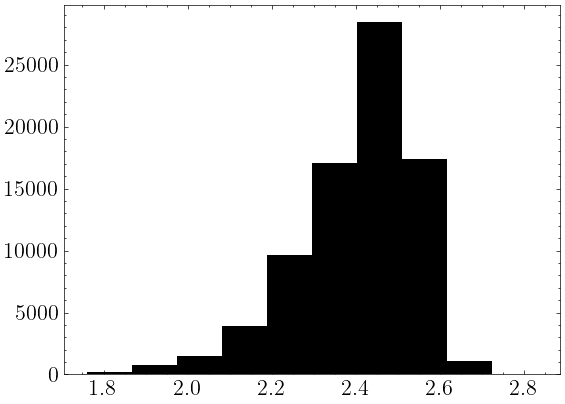

In [164]:
plt.hist(z_067_c1H_TDP_logt_rec)

In [165]:
get_quantiles(z_067_c1H_TDP_logt_rec)

2.43 -0.16 0.1


(array([  479.,  1612.,  2644.,  3592.,  6503., 11710., 23289., 23859.,
         5708.,   604.]),
 array([-0.79916646, -0.66226482, -0.52536319, -0.38846156, -0.25155993,
        -0.1146583 ,  0.02224334,  0.15914497,  0.2960466 ,  0.43294823,
         0.56984987]),
 <BarContainer object of 10 artists>)

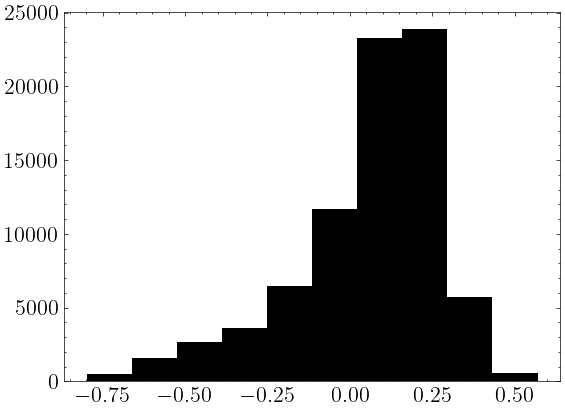

In [166]:
plt.hist(z_067_c1H_TDP_logt_cool-z_067_c1H_TDP_logt_rec)

In [167]:
get_quantiles(z_067_c1H_TDP_logt_cool-z_067_c1H_PIE_logt_rec)

0.57 -0.34 0.2


## c2

In [133]:
z_116_c2_PIE_samples = pd.read_csv(loaddir+'z=1.16590953/cloudy_fits/two_phase_c2.csv')

### c2H

In [134]:
z_116_c2H_PIE_logT, z_116_c2H_PIE_logt_rec, z_116_c2H_PIE_logt_cool = get_cooling_dist(z_116_c2_PIE_samples['log_hdens_p1'],
                                                                                             z_116_c2_PIE_samples['log_metals_p1'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([  116.,   859.,  3707., 12613., 28881., 46961., 46457., 29548.,
         9897.,  1361.]),
 array([4.34792438, 4.38022588, 4.41252739, 4.4448289 , 4.47713041,
        4.50943191, 4.54173342, 4.57403493, 4.60633643, 4.63863794,
        4.67093945]),
 <BarContainer object of 10 artists>)

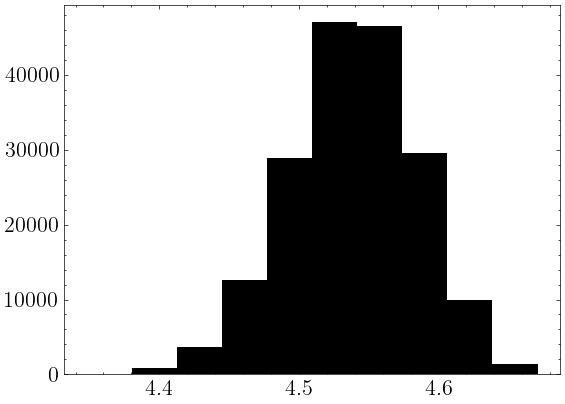

In [135]:
plt.hist(z_116_c2H_PIE_logT)

In [136]:
get_quantiles(z_116_c2H_PIE_logT)

4.54 -0.05 0.04


(array([1.9000e+01, 3.1300e+02, 3.1330e+03, 1.4286e+04, 3.6951e+04,
        4.6342e+04, 4.6062e+04, 2.6597e+04, 6.3340e+03, 3.6300e+02]),
 array([0.8846553 , 1.04878019, 1.21290508, 1.37702997, 1.54115487,
        1.70527976, 1.86940465, 2.03352954, 2.19765443, 2.36177933,
        2.52590422]),
 <BarContainer object of 10 artists>)

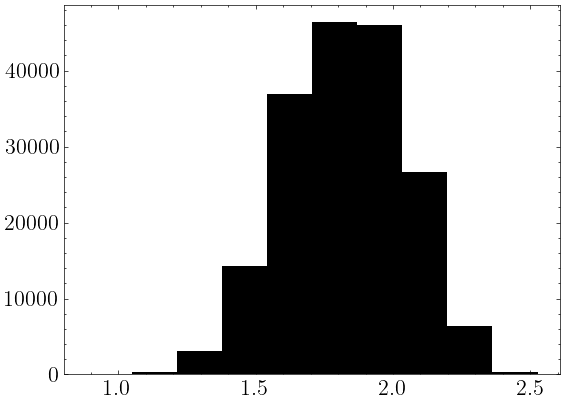

In [137]:
plt.hist(z_116_c2H_PIE_logt_rec)

In [138]:
get_quantiles(z_116_c2H_PIE_logt_rec)

1.84 -0.24 0.22


(array([   64.,   742.,  3610., 11712., 29380., 51031., 46466., 27724.,
         8505.,  1166.]),
 array([0.79187603, 0.82198526, 0.8520945 , 0.88220374, 0.91231298,
        0.94242221, 0.97253145, 1.00264069, 1.03274993, 1.06285917,
        1.0929684 ]),
 <BarContainer object of 10 artists>)

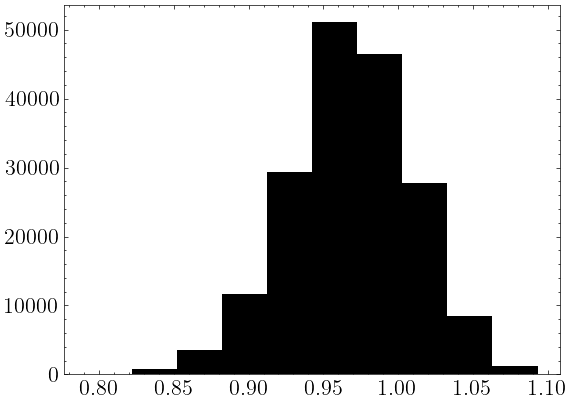

In [139]:
plt.hist(z_116_c2H_PIE_logt_cool-z_116_c2H_PIE_logt_rec)

In [140]:
get_quantiles(z_116_c2H_PIE_logt_cool-z_116_c2H_PIE_logt_rec)

0.97 -0.04 0.04


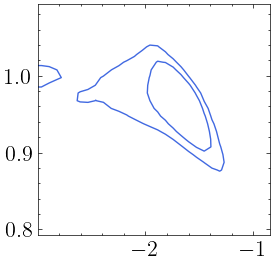

In [141]:
fig, ax = plt.subplots(1,figsize=(3,3))

corner.hist2d(np.array(z_116_c2_PIE_samples['log_metals_p1']), 
              np.array(z_116_c2H_PIE_logt_cool-z_116_c2H_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[1-np.exp(-0.5),2*cdf_1sig-1], color='royalblue')

### c2L

In [142]:
z_116_c2L_PIE_logT, z_116_c2L_PIE_logt_rec, z_116_c2L_PIE_logt_cool = get_cooling_dist(z_116_c2_PIE_samples['log_hdens_p2'],
                                                                                             z_116_c2_PIE_samples['log_metals_p2'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([1.8000e+01, 3.6000e+01, 2.8900e+02, 1.6130e+03, 6.6180e+03,
        1.8457e+04, 4.2516e+04, 5.6780e+04, 4.3287e+04, 1.0786e+04]),
 array([4.18244653, 4.24078859, 4.29913064, 4.3574727 , 4.41581475,
        4.47415681, 4.53249886, 4.59084092, 4.64918297, 4.70752503,
        4.76586708]),
 <BarContainer object of 10 artists>)

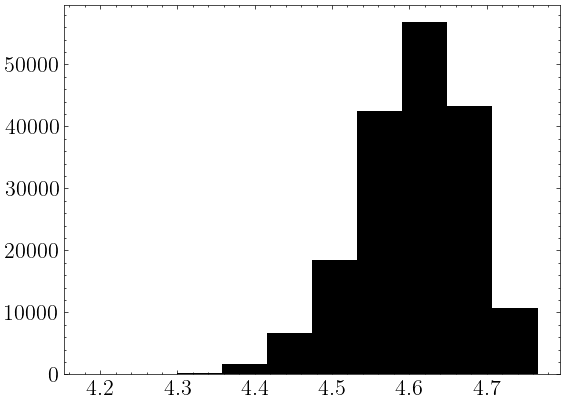

In [143]:
plt.hist(z_116_c2L_PIE_logT)

In [144]:
get_quantiles(z_116_c2L_PIE_logT)

4.61 -0.08 0.06


(array([  529.,  7908., 33340., 48068., 37381., 22541., 13304.,  8898.,
         5306.,  3125.]),
 array([1.72482788, 1.88423651, 2.04364515, 2.20305378, 2.36246242,
        2.52187106, 2.68127969, 2.84068833, 3.00009696, 3.1595056 ,
        3.31891423]),
 <BarContainer object of 10 artists>)

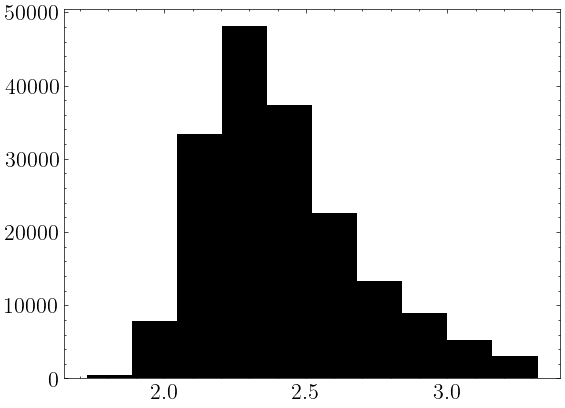

In [145]:
plt.hist(z_116_c2L_PIE_logt_rec)

In [146]:
get_quantiles(z_116_c2L_PIE_logt_rec)

2.36 -0.21 0.34


(array([2.0000e+01, 1.5000e+01, 6.9000e+01, 1.5500e+02, 4.8600e+02,
        1.5000e+03, 5.6360e+03, 2.4744e+04, 8.9007e+04, 5.8768e+04]),
 array([-0.05405044,  0.06788097,  0.18981237,  0.31174378,  0.43367518,
         0.55560659,  0.677538  ,  0.7994694 ,  0.92140081,  1.04333222,
         1.16526362]),
 <BarContainer object of 10 artists>)

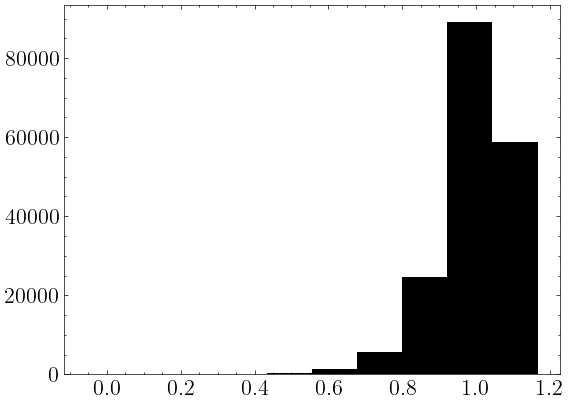

In [147]:
plt.hist(z_116_c2L_PIE_logt_cool-z_116_c2L_PIE_logt_rec)

In [148]:
get_quantiles(z_116_c2L_PIE_logt_cool-z_116_c2L_PIE_logt_rec)

1.01 -0.1 0.06


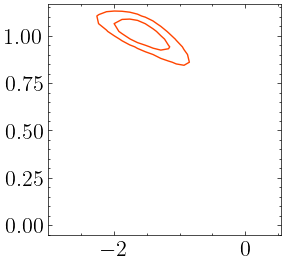

In [149]:
fig, ax = plt.subplots(1,figsize=(3,3))

corner.hist2d(np.array(z_116_c2_PIE_samples['log_metals_p2']), 
              np.array(z_116_c2L_PIE_logt_cool-z_116_c2L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[1-np.exp(-0.5),2*cdf_1sig-1], color='orangered')

## c1

In [158]:
z_122_c1_PIE_samples = pd.read_csv(loaddir+'z=1.22541394/cloudy_fits/two_phase.csv')

### c1H

In [159]:
z_122_c1H_PIE_logT, z_122_c1H_PIE_logt_rec, z_122_c1H_PIE_logt_cool = get_cooling_dist(z_122_c1_PIE_samples['log_hdens_p1'],
                                                                                             z_122_c1_PIE_samples['log_metals_p1'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([   63.,   887.,  1737.,  4071.,  5083.,  9786., 18007., 23247.,
        15289.,  1830.]),
 array([3.62525771, 3.72606588, 3.82687405, 3.92768221, 4.02849038,
        4.12929855, 4.23010672, 4.33091489, 4.43172306, 4.53253122,
        4.63333939]),
 <BarContainer object of 10 artists>)

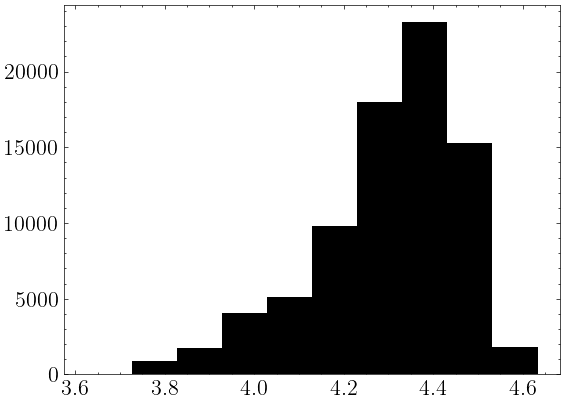

In [160]:
plt.hist(z_122_c1H_PIE_logT)

In [161]:
get_quantiles(z_122_c1H_PIE_logT)

4.33 -0.19 0.12


In [162]:
np.median(z_122_c1H_PIE_logT)-np.percentile(z_122_c1H_PIE_logT, 100*(1-cdf_1sig))

0.19179784413551904

(array([  851.,   547.,   338.,   489.,  1155.,  3713., 17790., 31169.,
        18565.,  5383.]),
 array([-3.32726363, -2.74696122, -2.16665881, -1.5863564 , -1.00605399,
        -0.42575158,  0.15455083,  0.73485324,  1.31515565,  1.89545807,
         2.47576048]),
 <BarContainer object of 10 artists>)

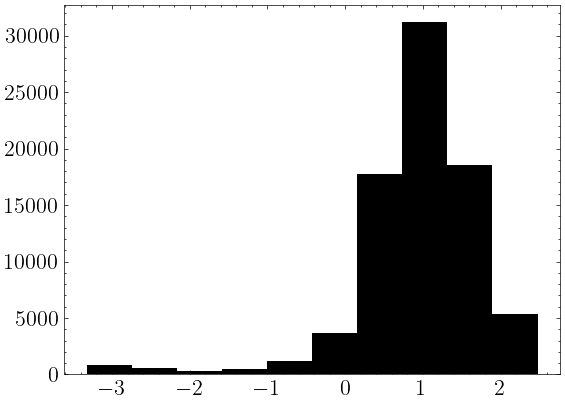

In [163]:
plt.hist(z_122_c1H_PIE_logt_rec)

In [164]:
get_quantiles(z_122_c1H_PIE_logt_rec)

1.0 -0.56 0.61


(array([  211.,   318.,   499.,   695.,  3616., 24937., 48623.,   449.,
          254.,   398.]),
 array([-0.49156047, -0.27679171, -0.06202294,  0.15274583,  0.3675146 ,
         0.58228337,  0.79705213,  1.0118209 ,  1.22658967,  1.44135844,
         1.65612721]),
 <BarContainer object of 10 artists>)

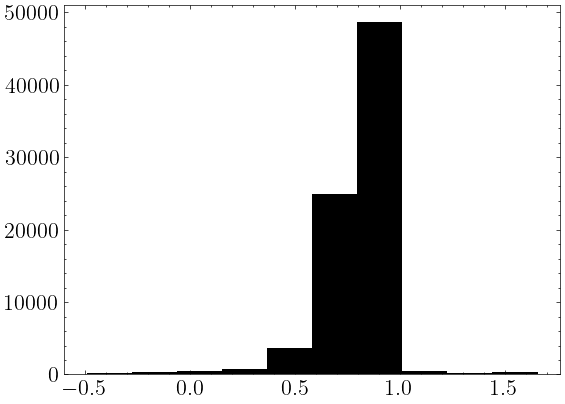

In [165]:
plt.hist(z_122_c1H_PIE_logt_cool-z_122_c1H_PIE_logt_rec)

In [166]:
get_quantiles(z_122_c1H_PIE_logt_cool-z_122_c1H_PIE_logt_rec)

0.83 -0.14 0.07


### c1L

In [167]:
z_122_c1L_PIE_logT, z_122_c1L_PIE_logt_rec, z_122_c1L_PIE_logt_cool = get_cooling_dist(z_122_c1_PIE_samples['log_hdens_p2'],
                                                                                             z_122_c1_PIE_samples['log_metals_p2'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([2.9000e+01, 1.9320e+03, 2.1888e+04, 2.9621e+04, 1.6603e+04,
        6.5890e+03, 1.7770e+03, 9.0000e+02, 4.4400e+02, 2.1700e+02]),
 array([4.15095313, 4.20999298, 4.26903284, 4.32807269, 4.38711254,
        4.4461524 , 4.50519225, 4.56423211, 4.62327196, 4.68231182,
        4.74135167]),
 <BarContainer object of 10 artists>)

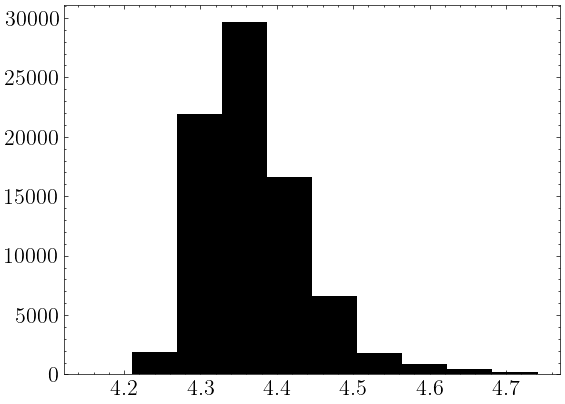

In [168]:
plt.hist(z_122_c1L_PIE_logT)

In [169]:
get_quantiles(z_122_c1L_PIE_logT)

4.36 -0.05 0.08


(array([ 1604., 32084., 30422.,  9022.,  3798.,  1508.,   623.,   508.,
          228.,   203.]),
 array([2.08065345, 2.2032331 , 2.32581276, 2.44839241, 2.57097206,
        2.69355172, 2.81613137, 2.93871102, 3.06129067, 3.18387033,
        3.30644998]),
 <BarContainer object of 10 artists>)

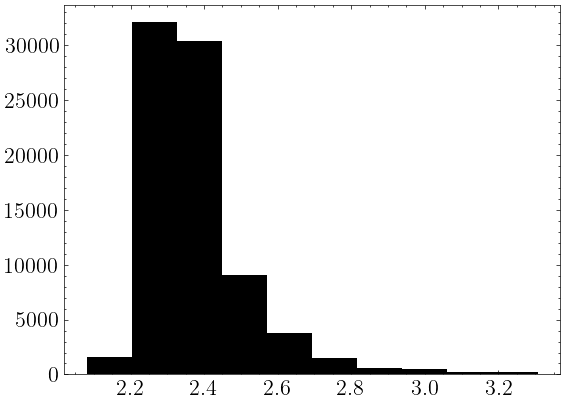

In [170]:
plt.hist(z_122_c1L_PIE_logt_rec)

In [171]:
get_quantiles(z_122_c1L_PIE_logt_rec)

2.34 -0.08 0.13


In [172]:
np.percentile(z_122_c1L_PIE_logt_rec, 100*cdf_1sig)-np.median(z_122_c1L_PIE_logt_rec)

0.13353987693565283

(array([ 2257.,  4590.,  5995.,  8951., 12471., 16230., 15257., 10278.,
         3483.,   488.]),
 array([-0.37697724, -0.24216531, -0.10735338,  0.02745855,  0.16227048,
         0.2970824 ,  0.43189433,  0.56670626,  0.70151819,  0.83633012,
         0.97114205]),
 <BarContainer object of 10 artists>)

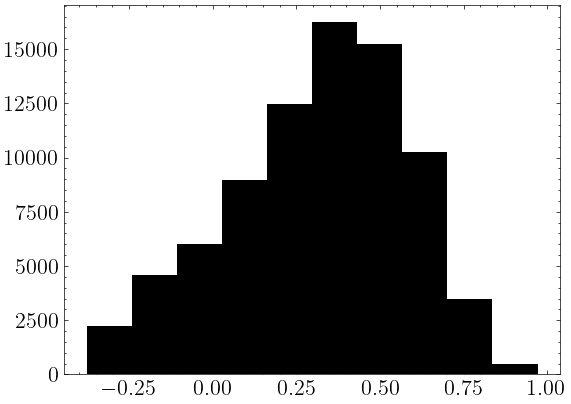

In [173]:
plt.hist(z_122_c1L_PIE_logt_cool-z_122_c1L_PIE_logt_rec)

In [174]:
get_quantiles(z_122_c1L_PIE_logt_cool-z_122_c1L_PIE_logt_rec)

0.35 -0.32 0.24


In [175]:
np.median(z_122_c1L_PIE_logt_cool-z_122_c1L_PIE_logt_rec)

0.345261482661102

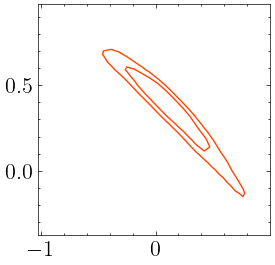

In [176]:
fig, ax = plt.subplots(1,figsize=(3,3))

corner.hist2d(np.array(z_122_c1_PIE_samples['log_metals_p2']), 
              np.array(z_122_c1L_PIE_logt_cool-z_122_c1L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[1-np.exp(-0.5),2*cdf_1sig-1], color='orangered')

## c2

In [209]:
z_127_c2_PIE_samples = pd.read_csv(loaddir+'z=1.27767328/cloudy_fits/two_phase_c2.csv')

### c2H

In [210]:
z_127_c2H_PIE_logT, z_127_c2H_PIE_logt_rec, z_127_c2H_PIE_logt_cool = get_cooling_dist(z_127_c2_PIE_samples['log_hdens_p1'],
                                                                                             z_127_c2_PIE_samples['log_metals_p1'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([  432.,  5669., 19855., 29471., 31410., 27810., 29377., 27307.,
         8156.,   513.]),
 array([4.1678118 , 4.21209034, 4.25636888, 4.30064742, 4.34492596,
        4.38920449, 4.43348303, 4.47776157, 4.52204011, 4.56631865,
        4.61059719]),
 <BarContainer object of 10 artists>)

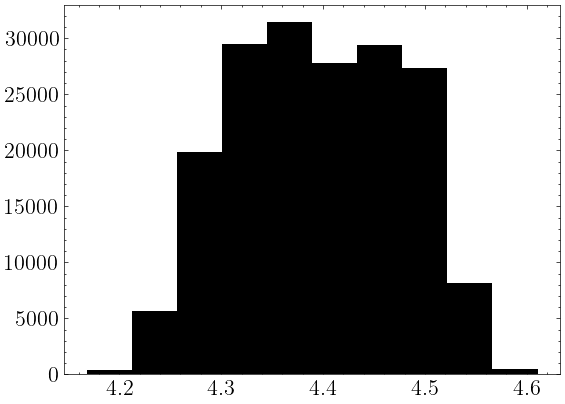

In [211]:
plt.hist(z_127_c2H_PIE_logT)

In [212]:
get_quantiles(z_127_c2H_PIE_logT)

4.39 -0.09 0.09


(array([10669., 47530., 44695., 33457., 20137., 12288.,  7373.,  3173.,
          617.,    61.]),
 array([1.30082458, 1.40312561, 1.50542663, 1.60772766, 1.71002869,
        1.81232972, 1.91463075, 2.01693177, 2.1192328 , 2.22153383,
        2.32383486]),
 <BarContainer object of 10 artists>)

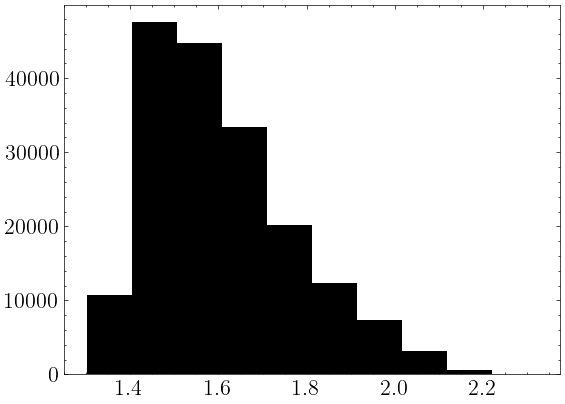

In [213]:
plt.hist(z_127_c2H_PIE_logt_rec)

In [214]:
get_quantiles(z_127_c2H_PIE_logt_rec)

1.57 -0.13 0.21


(array([  631.,  6577., 20623., 28083., 24826., 21482., 22754., 29797.,
        23591.,  1636.]),
 array([0.51458465, 0.56707301, 0.61956137, 0.67204973, 0.72453809,
        0.77702645, 0.82951481, 0.88200317, 0.93449153, 0.98697989,
        1.03946825]),
 <BarContainer object of 10 artists>)

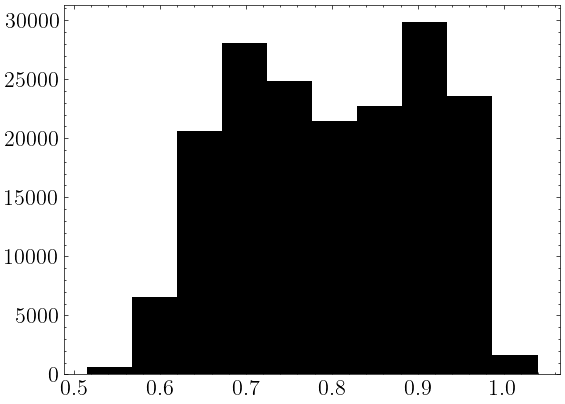

In [215]:
plt.hist(z_127_c2H_PIE_logt_cool-z_127_c2H_PIE_logt_rec)

In [216]:
get_quantiles(z_127_c2H_PIE_logt_cool-z_127_c2H_PIE_logt_rec)

0.8 -0.13 0.13


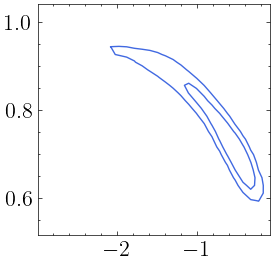

In [217]:
fig, ax = plt.subplots(1,figsize=(3,3))

corner.hist2d(np.array(z_127_c2_PIE_samples['log_metals_p1']), 
              np.array(z_127_c2H_PIE_logt_cool-z_127_c2H_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[1-np.exp(-0.5),2*cdf_1sig-1], color='royalblue')

### c2L

In [218]:
z_127_c2L_PIE_logT, z_127_c2L_PIE_logt_rec, z_127_c2L_PIE_logt_cool = get_cooling_dist(z_127_c2_PIE_samples['log_hdens_p2'],
                                                                                             z_127_c2_PIE_samples['log_metals_p2'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([  375.,  2063., 12832., 47679., 59944., 33845., 14898.,  5277.,
         2619.,   468.]),
 array([3.92408371, 4.00458434, 4.08508498, 4.16558561, 4.24608625,
        4.32658688, 4.40708752, 4.48758815, 4.56808879, 4.64858943,
        4.72909006]),
 <BarContainer object of 10 artists>)

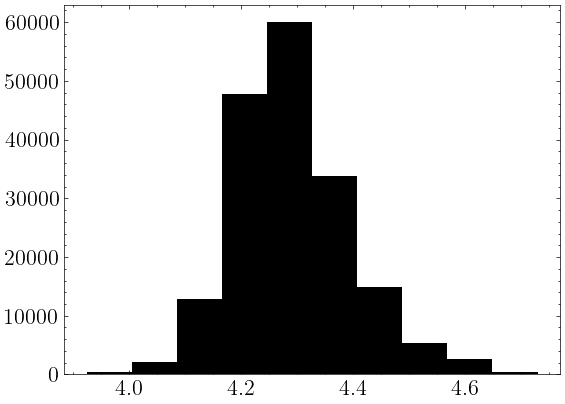

In [219]:
plt.hist(z_127_c2L_PIE_logT)

In [220]:
get_quantiles(z_127_c2L_PIE_logT)

4.28 -0.08 0.11


(array([ 4062., 57247., 61847., 29222., 14411.,  7851.,  3837.,   950.,
          427.,   146.]),
 array([1.77147157, 1.91857225, 2.06567293, 2.21277361, 2.35987429,
        2.50697497, 2.65407565, 2.80117633, 2.94827701, 3.09537769,
        3.24247837]),
 <BarContainer object of 10 artists>)

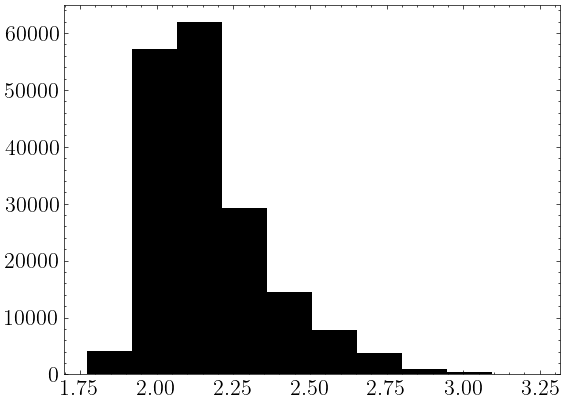

In [221]:
plt.hist(z_127_c2L_PIE_logt_rec)

In [222]:
get_quantiles(z_127_c2L_PIE_logt_rec)

2.12 -0.11 0.23


(array([ 1529.,  5480., 16665., 33636., 43970., 41711., 23618.,  9153.,
         3231.,  1007.]),
 array([-0.40327891, -0.25313298, -0.10298704,  0.04715889,  0.19730482,
         0.34745075,  0.49759668,  0.64774262,  0.79788855,  0.94803448,
         1.09818041]),
 <BarContainer object of 10 artists>)

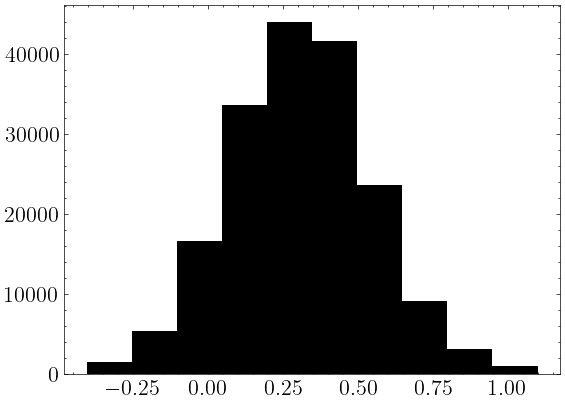

In [223]:
plt.hist(z_127_c2L_PIE_logt_cool-z_127_c2L_PIE_logt_rec)

In [224]:
get_quantiles(z_127_c2L_PIE_logt_cool-z_127_c2L_PIE_logt_rec)

0.31 -0.24 0.22


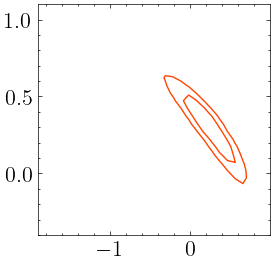

In [225]:
fig, ax = plt.subplots(1,figsize=(3,3))

corner.hist2d(np.array(z_127_c2_PIE_samples['log_metals_p2']), 
              np.array(z_127_c2L_PIE_logt_cool-z_127_c2L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[1-np.exp(-0.5),2*cdf_1sig-1], color='orangered')